In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as stats
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import warnings
import os
warnings.filterwarnings('ignore')

train_path_features = r'C:\Users\divye\Data_science_projects\H1N1_seasonal_vaccines\data\training_set_features.csv'
train_path_labels  = r'C:\Users\divye\Data_science_projects\H1N1_seasonal_vaccines\data\training_set_labels.csv'

test_path_features = r'C:\Users\divye\Data_science_projects\H1N1_seasonal_vaccines\data\test_set_features.csv'


train_df_features = pd.read_csv(train_path_features)
train_df_labels = pd.read_csv(train_path_labels)

merged_df = pd.merge(train_df_features, train_df_labels, on='respondent_id', how='inner')

print(merged_df.shape)
print(merged_df.head())

(26707, 38)
   respondent_id  h1n1_concern  h1n1_knowledge  behavioral_antiviral_meds  \
0              0           1.0             0.0                        0.0   
1              1           3.0             2.0                        0.0   
2              2           1.0             1.0                        0.0   
3              3           1.0             1.0                        0.0   
4              4           2.0             1.0                        0.0   

   behavioral_avoidance  behavioral_face_mask  behavioral_wash_hands  \
0                   0.0                   0.0                    0.0   
1                   1.0                   0.0                    1.0   
2                   1.0                   0.0                    0.0   
3                   1.0                   0.0                    1.0   
4                   1.0                   0.0                    1.0   

   behavioral_large_gatherings  behavioral_outside_home  \
0                          0.0   

In [98]:
merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26707 entries, 0 to 26706
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                26707 non-null  int64  
 1   h1n1_concern                 26615 non-null  float64
 2   h1n1_knowledge               26591 non-null  float64
 3   behavioral_antiviral_meds    26636 non-null  float64
 4   behavioral_avoidance         26499 non-null  float64
 5   behavioral_face_mask         26688 non-null  float64
 6   behavioral_wash_hands        26665 non-null  float64
 7   behavioral_large_gatherings  26620 non-null  float64
 8   behavioral_outside_home      26625 non-null  float64
 9   behavioral_touch_face        26579 non-null  float64
 10  doctor_recc_h1n1             24547 non-null  float64
 11  doctor_recc_seasonal         24547 non-null  float64
 12  chronic_med_condition        25736 non-null  float64
 13  child_under_6_months       

In [99]:
merged_df.isna().sum()

respondent_id                      0
h1n1_concern                      92
h1n1_knowledge                   116
behavioral_antiviral_meds         71
behavioral_avoidance             208
behavioral_face_mask              19
behavioral_wash_hands             42
behavioral_large_gatherings       87
behavioral_outside_home           82
behavioral_touch_face            128
doctor_recc_h1n1                2160
doctor_recc_seasonal            2160
chronic_med_condition            971
child_under_6_months             820
health_worker                    804
health_insurance               12274
opinion_h1n1_vacc_effective      391
opinion_h1n1_risk                388
opinion_h1n1_sick_from_vacc      395
opinion_seas_vacc_effective      462
opinion_seas_risk                514
opinion_seas_sick_from_vacc      537
age_group                          0
education                       1407
race                               0
sex                                0
income_poverty                  4423
m

# EDA

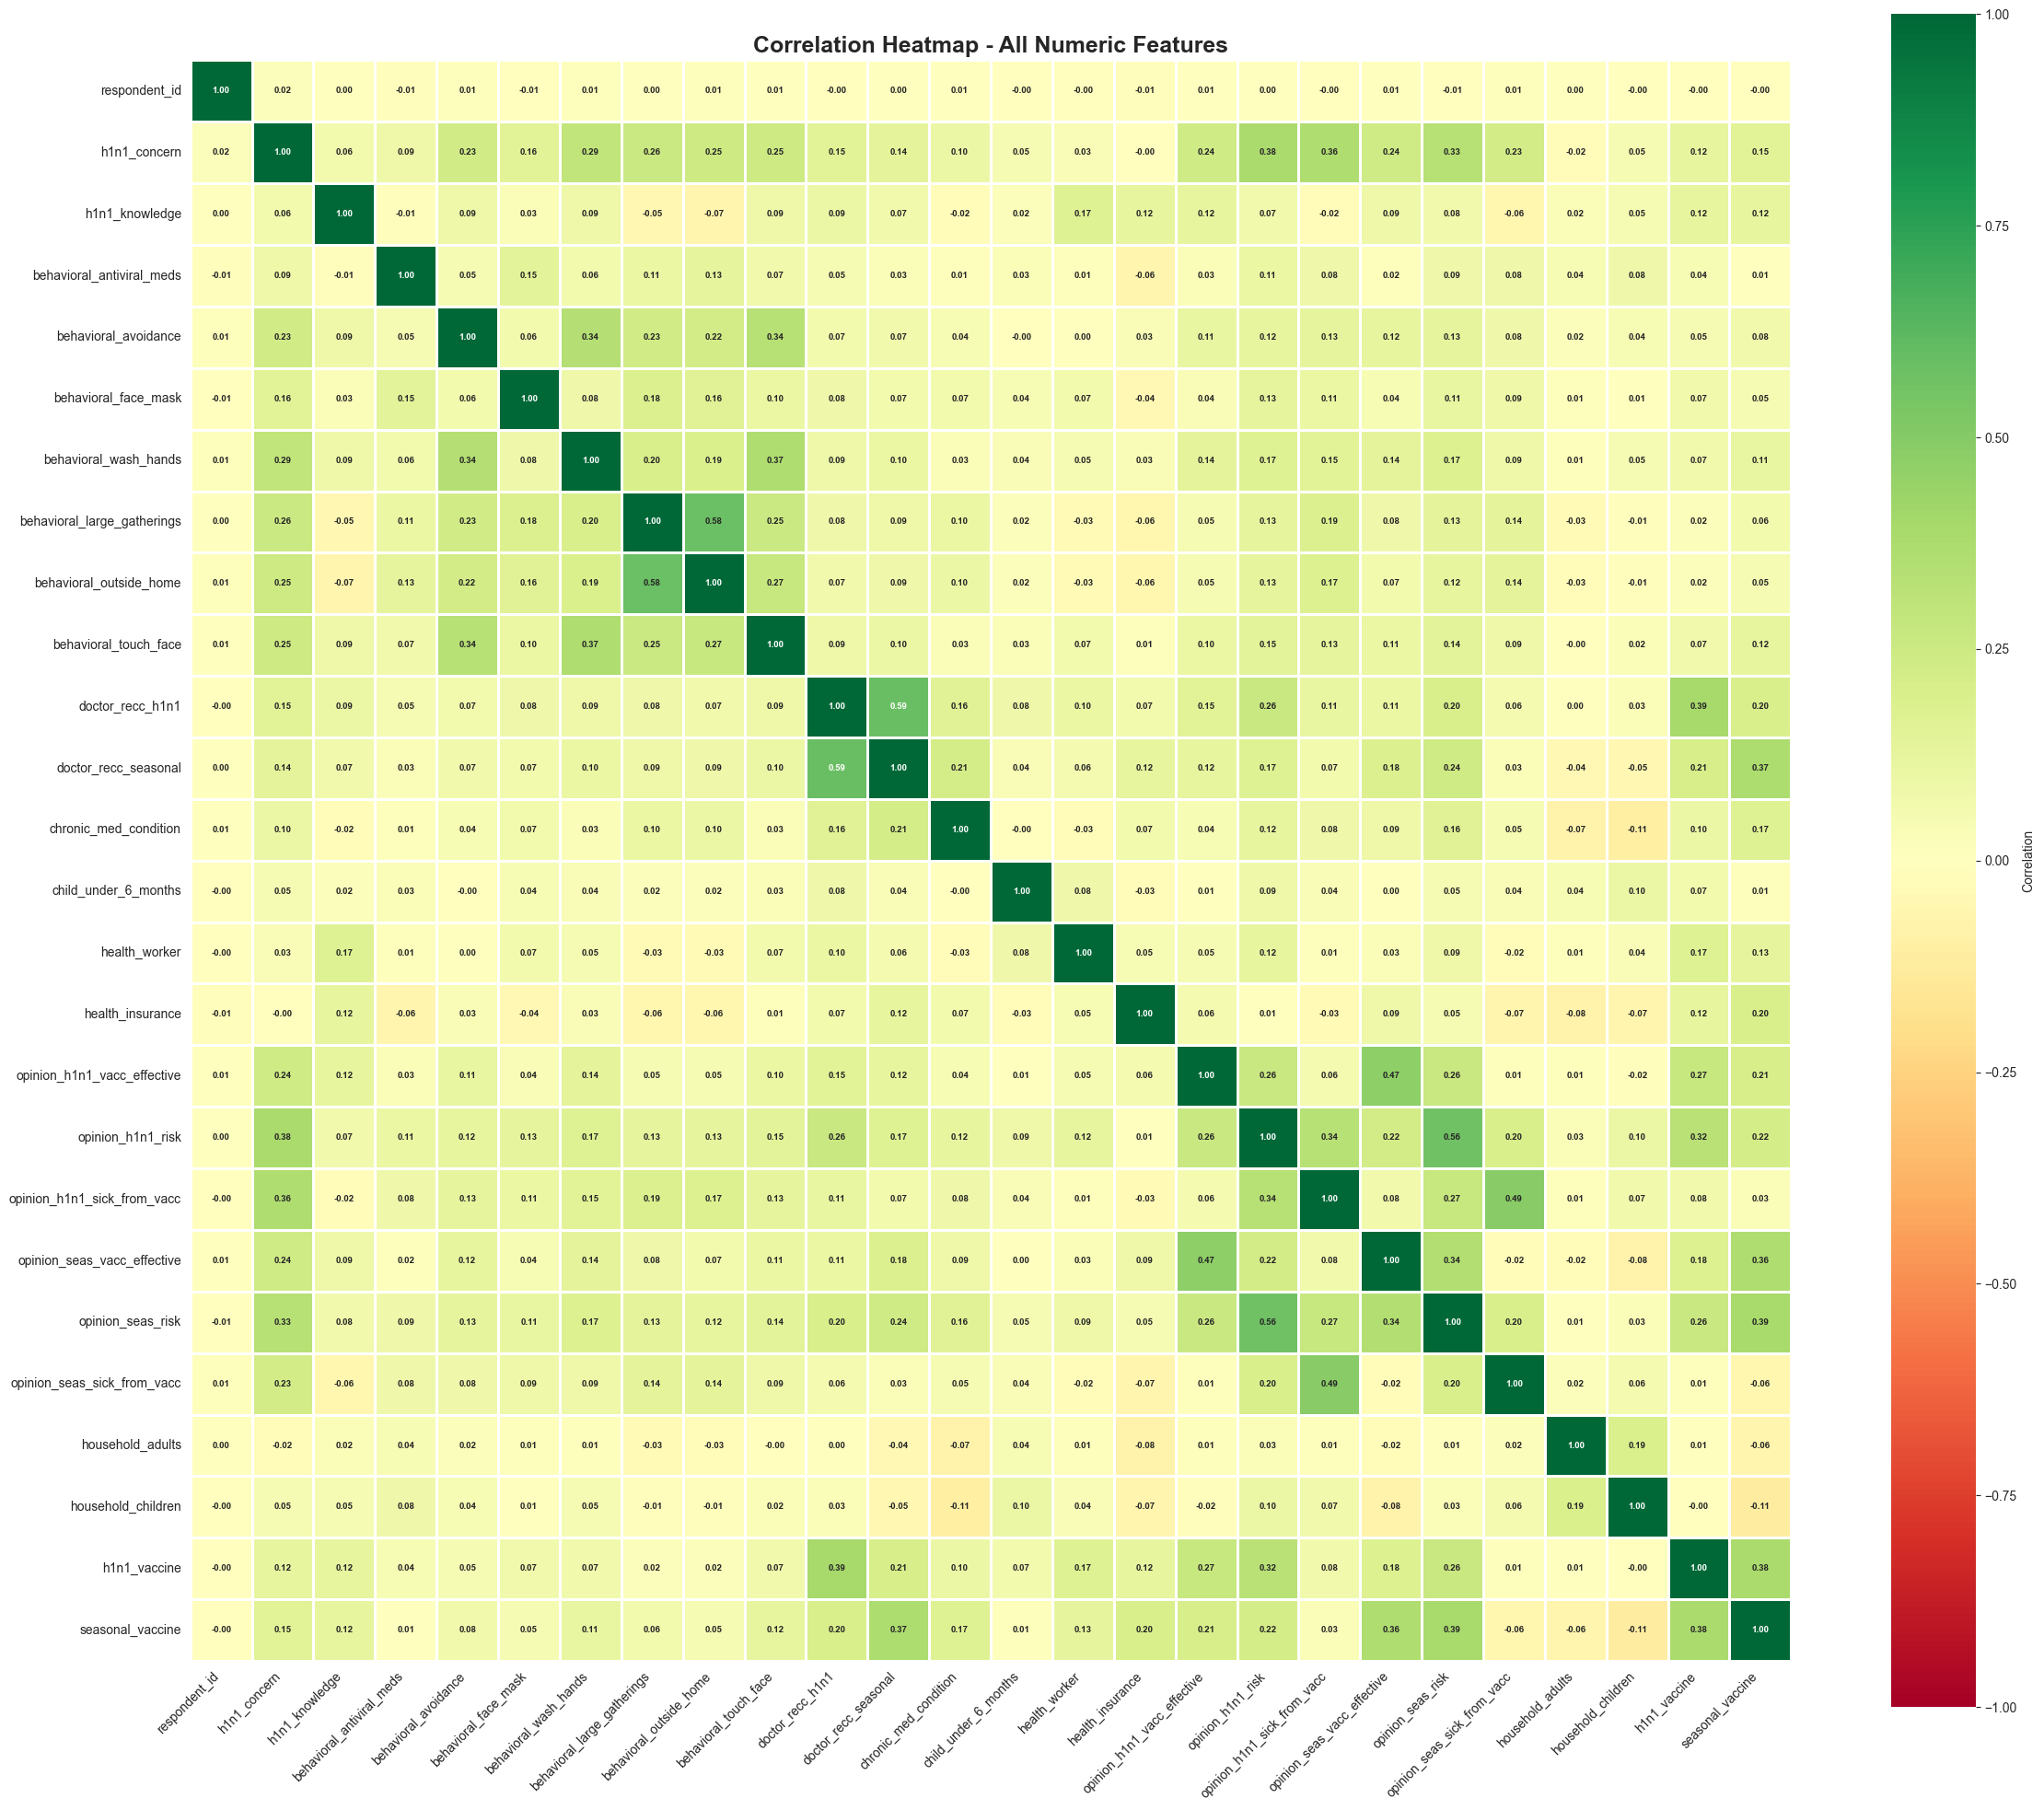

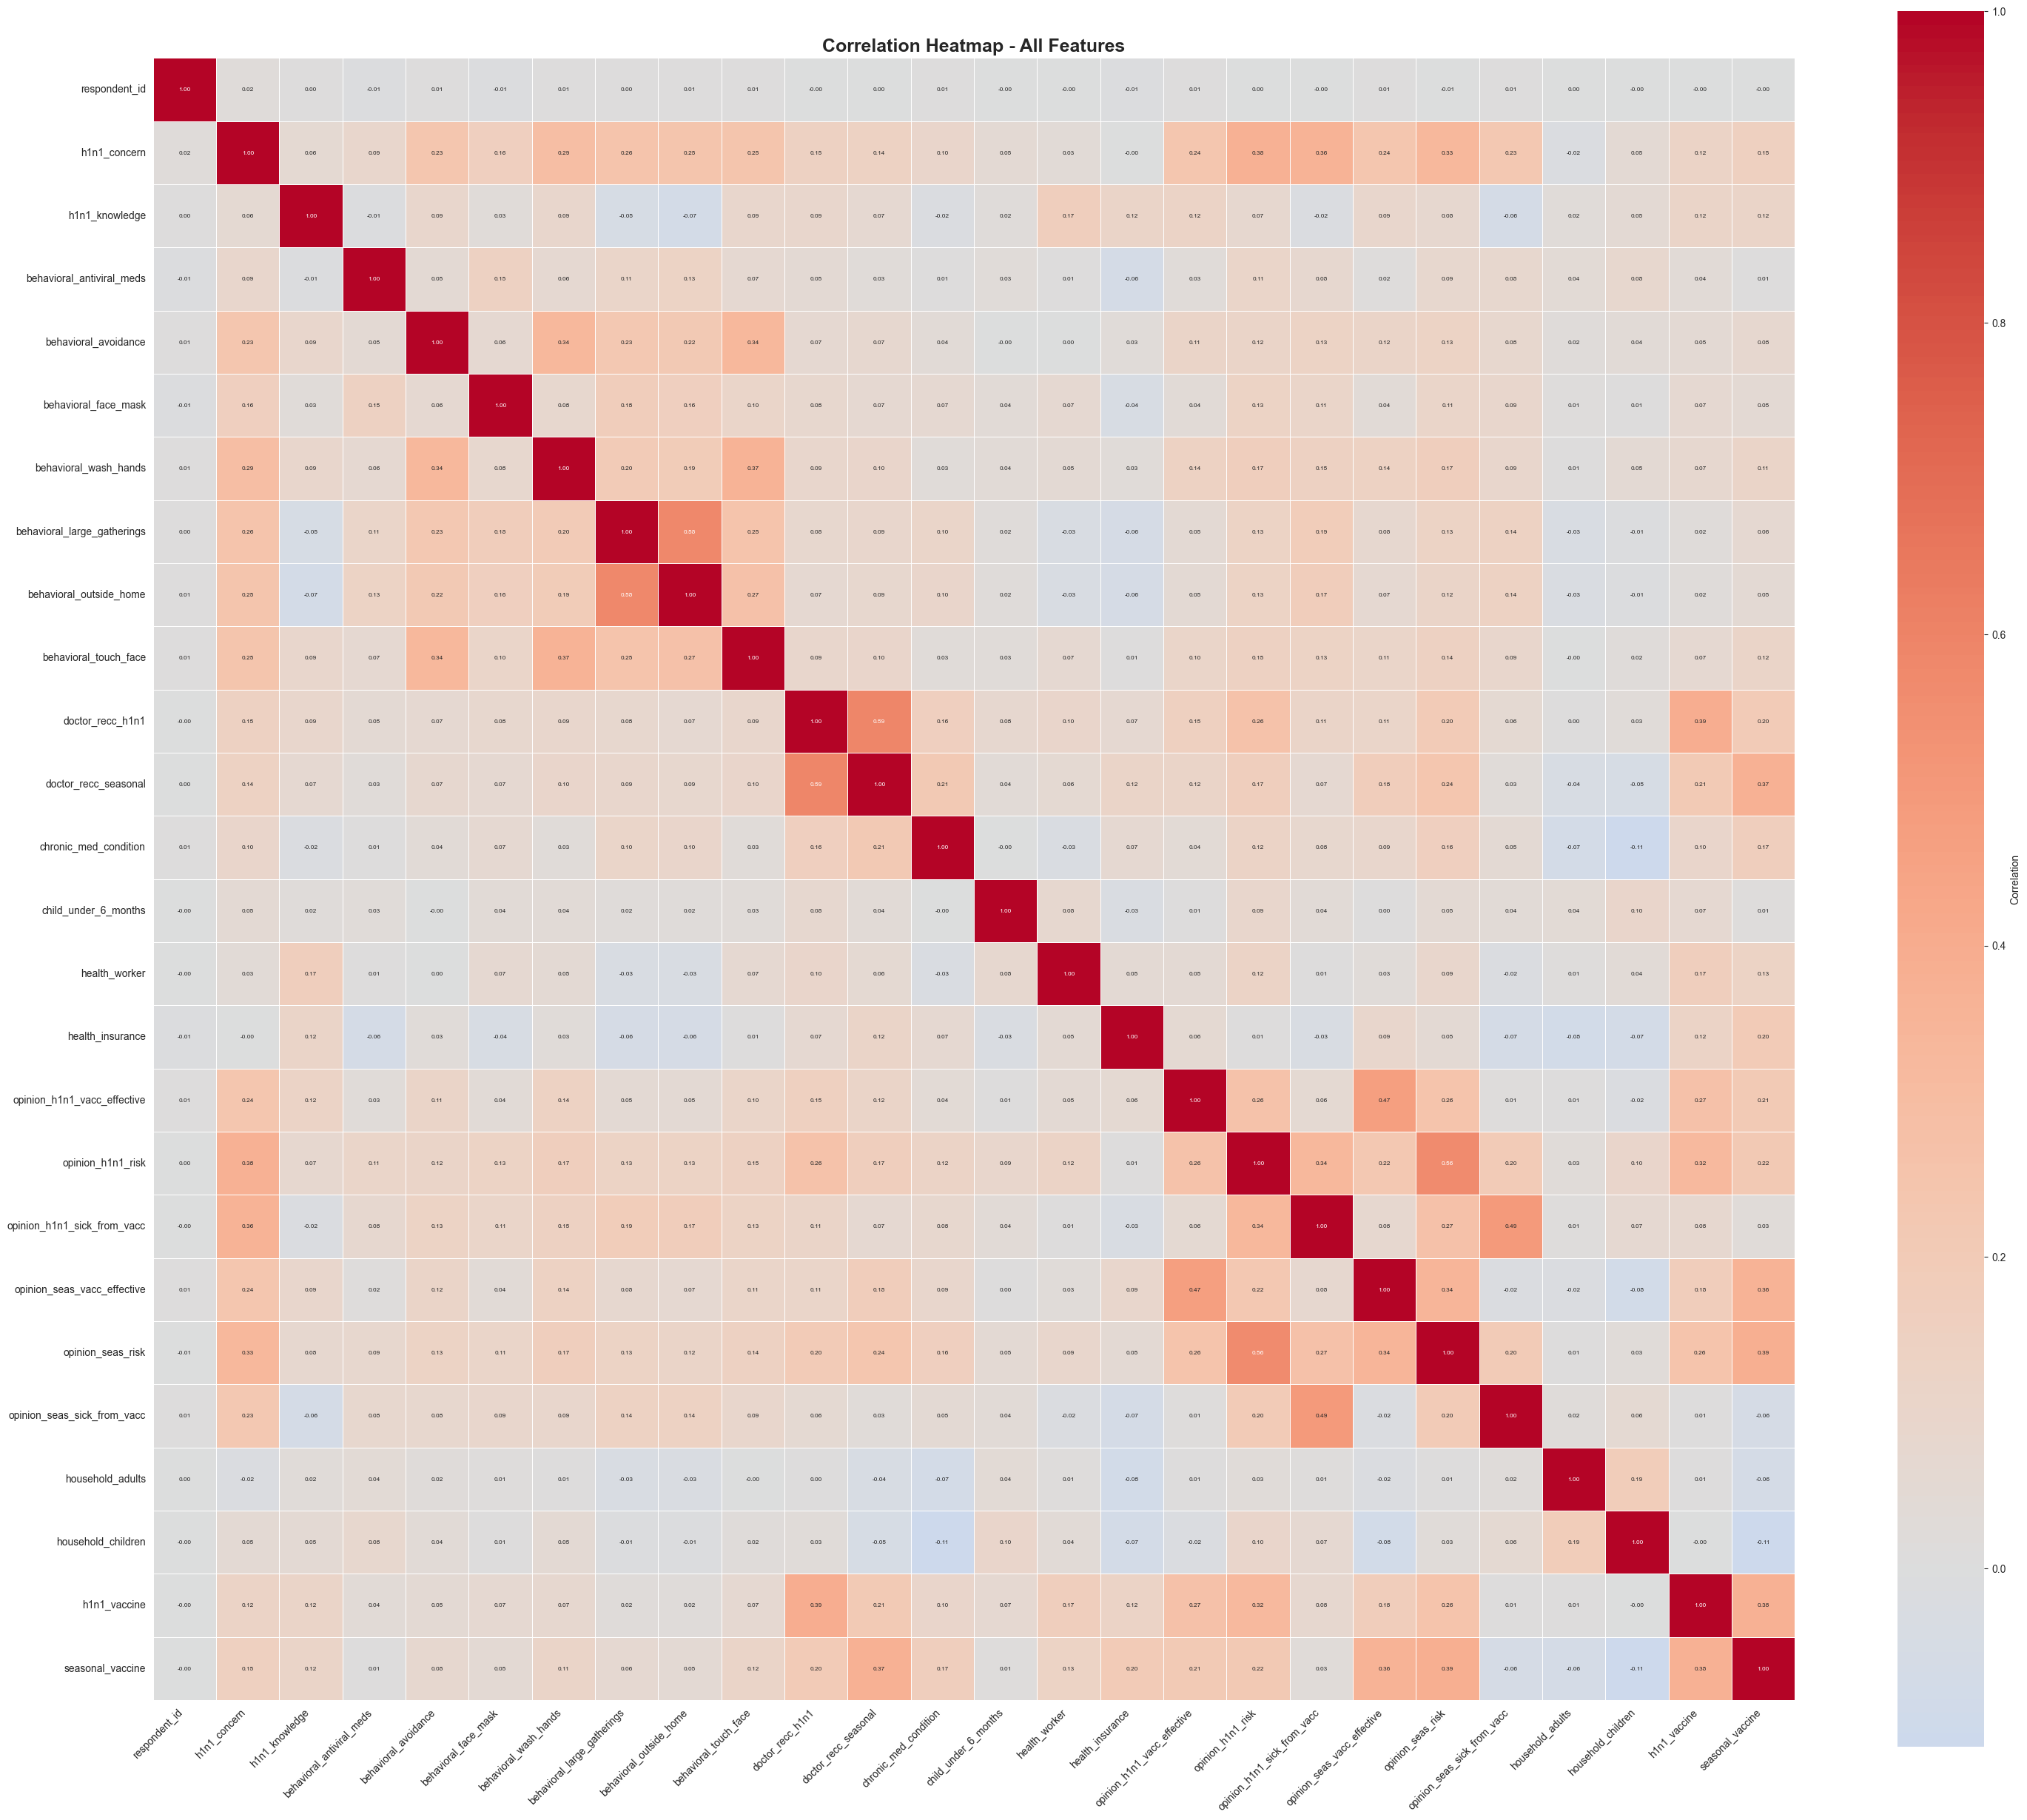

Correlation Matrix Shape: (26, 26)

Correlation Matrix:
                             respondent_id  h1n1_concern  h1n1_knowledge  \
respondent_id                     1.000000      0.017839        0.003425   
h1n1_concern                      0.017839      1.000000        0.062522   
h1n1_knowledge                    0.003425      0.062522        1.000000   
behavioral_antiviral_meds        -0.008475      0.090301       -0.010836   
behavioral_avoidance              0.009638      0.233713        0.088839   
behavioral_face_mask             -0.006644      0.156032        0.030050   
behavioral_wash_hands             0.011105      0.293565        0.089785   
behavioral_large_gatherings       0.004539      0.255031       -0.048898   
behavioral_outside_home           0.009011      0.246424       -0.068219   
behavioral_touch_face             0.007575      0.248016        0.086162   
doctor_recc_h1n1                 -0.002072      0.150206        0.093829   
doctor_recc_seasonal            

In [100]:


# Get all numeric columns
numeric_df = merged_df.select_dtypes(include=['number'])

# Create correlation matrix for all features
corr_matrix = numeric_df.corr()

# Method 1: Larger Figure with Better Readability
plt.figure(figsize=(24, 20))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', 
            center=0, cbar_kws={'label': 'Correlation'}, 
            linewidths=1, square=True, 
            annot_kws={'size': 7, 'weight': 'bold'}, vmin=-1, vmax=1)
plt.title('Correlation Heatmap - All Numeric Features', fontsize=18, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

# Method 2: Save as Image (If too large to display)
plt.figure(figsize=(30, 25))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, cbar_kws={'label': 'Correlation'}, 
            linewidths=0.5, square=True, annot_kws={'size': 6})
plt.title('Correlation Heatmap - All Features', fontsize=18, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


# Method 5: Print correlation statistics
print("Correlation Matrix Shape:", corr_matrix.shape)
print("\nCorrelation Matrix:")
print(corr_matrix)

Key Observations:
1. Strong Positive Correlations (Red - 0.6+):

doctor_recc_h1n1 ↔ doctor_recc_seasonal (0.63) - Very strong, makes sense as vaccination recommendations often go together
opinion_h1n1_risk ↔ opinion_seas_risk (0.56) - People's risk perception is consistent across both vaccines
opinion_h1n1_sick_from_vacc ↔ opinion_seas_sick_from_vacc (0.49) - Similar concerns about side effects
opinion_h1n1_vacc_effective ↔ seasonal_vaccine (0.36-0.39) - Effectiveness opinions correlate
h1n1_concern ↔ behavioral_avoidance (0.34) - Higher concern leads to avoidance behavior
opinion_seas_risk ↔ seasonal_vaccine (0.39) - Risk perception drives vaccine uptake

2. Moderate Correlations (Orange - 0.2-0.6):

Behavioral measures (wash_hands, avoid gatherings, wear mask) show 0.2-0.34 correlation with each other
Opinion variables tend to correlate moderately with behavioral actions
h1n1_concern shows consistent 0.23-0.33 correlations with various behavioral measures

3. Weak/No Correlations (Light/Blue - 0-0.2):

respondent_id has almost no correlation with anything (0.00s) - good, no data leakage
Demographics (household_adults, household_children) show minimal correlation with opinions/behaviors
Health worker status and health_insurance have weak correlations overall
child_under_6_months shows minimal impact on vaccination decisions

1. IDENTIFYING STRING COLUMNS

Total String Columns: 12

String Columns:
  - age_group
  - education
  - race
  - sex
  - income_poverty
  - marital_status
  - rent_or_own
  - employment_status
  - hhs_geo_region
  - census_msa
  - employment_industry
  - employment_occupation

2. VALUE COUNTS FOR STRING COLUMNS

age_group:
------------------------------------------------------------
age_group
65+ Years        6843
55 - 64 Years    5563
45 - 54 Years    5238
18 - 34 Years    5215
35 - 44 Years    3848
Name: count, dtype: int64
Unique Values: 5
Missing Values: 0

education:
------------------------------------------------------------
education
College Graduate    10097
Some College         7043
12 Years             5797
< 12 Years           2363
NaN                  1407
Name: count, dtype: int64
Unique Values: 4
Missing Values: 1407

race:
------------------------------------------------------------
race
White                21222
Black                 2118
Hispanic              1755
O

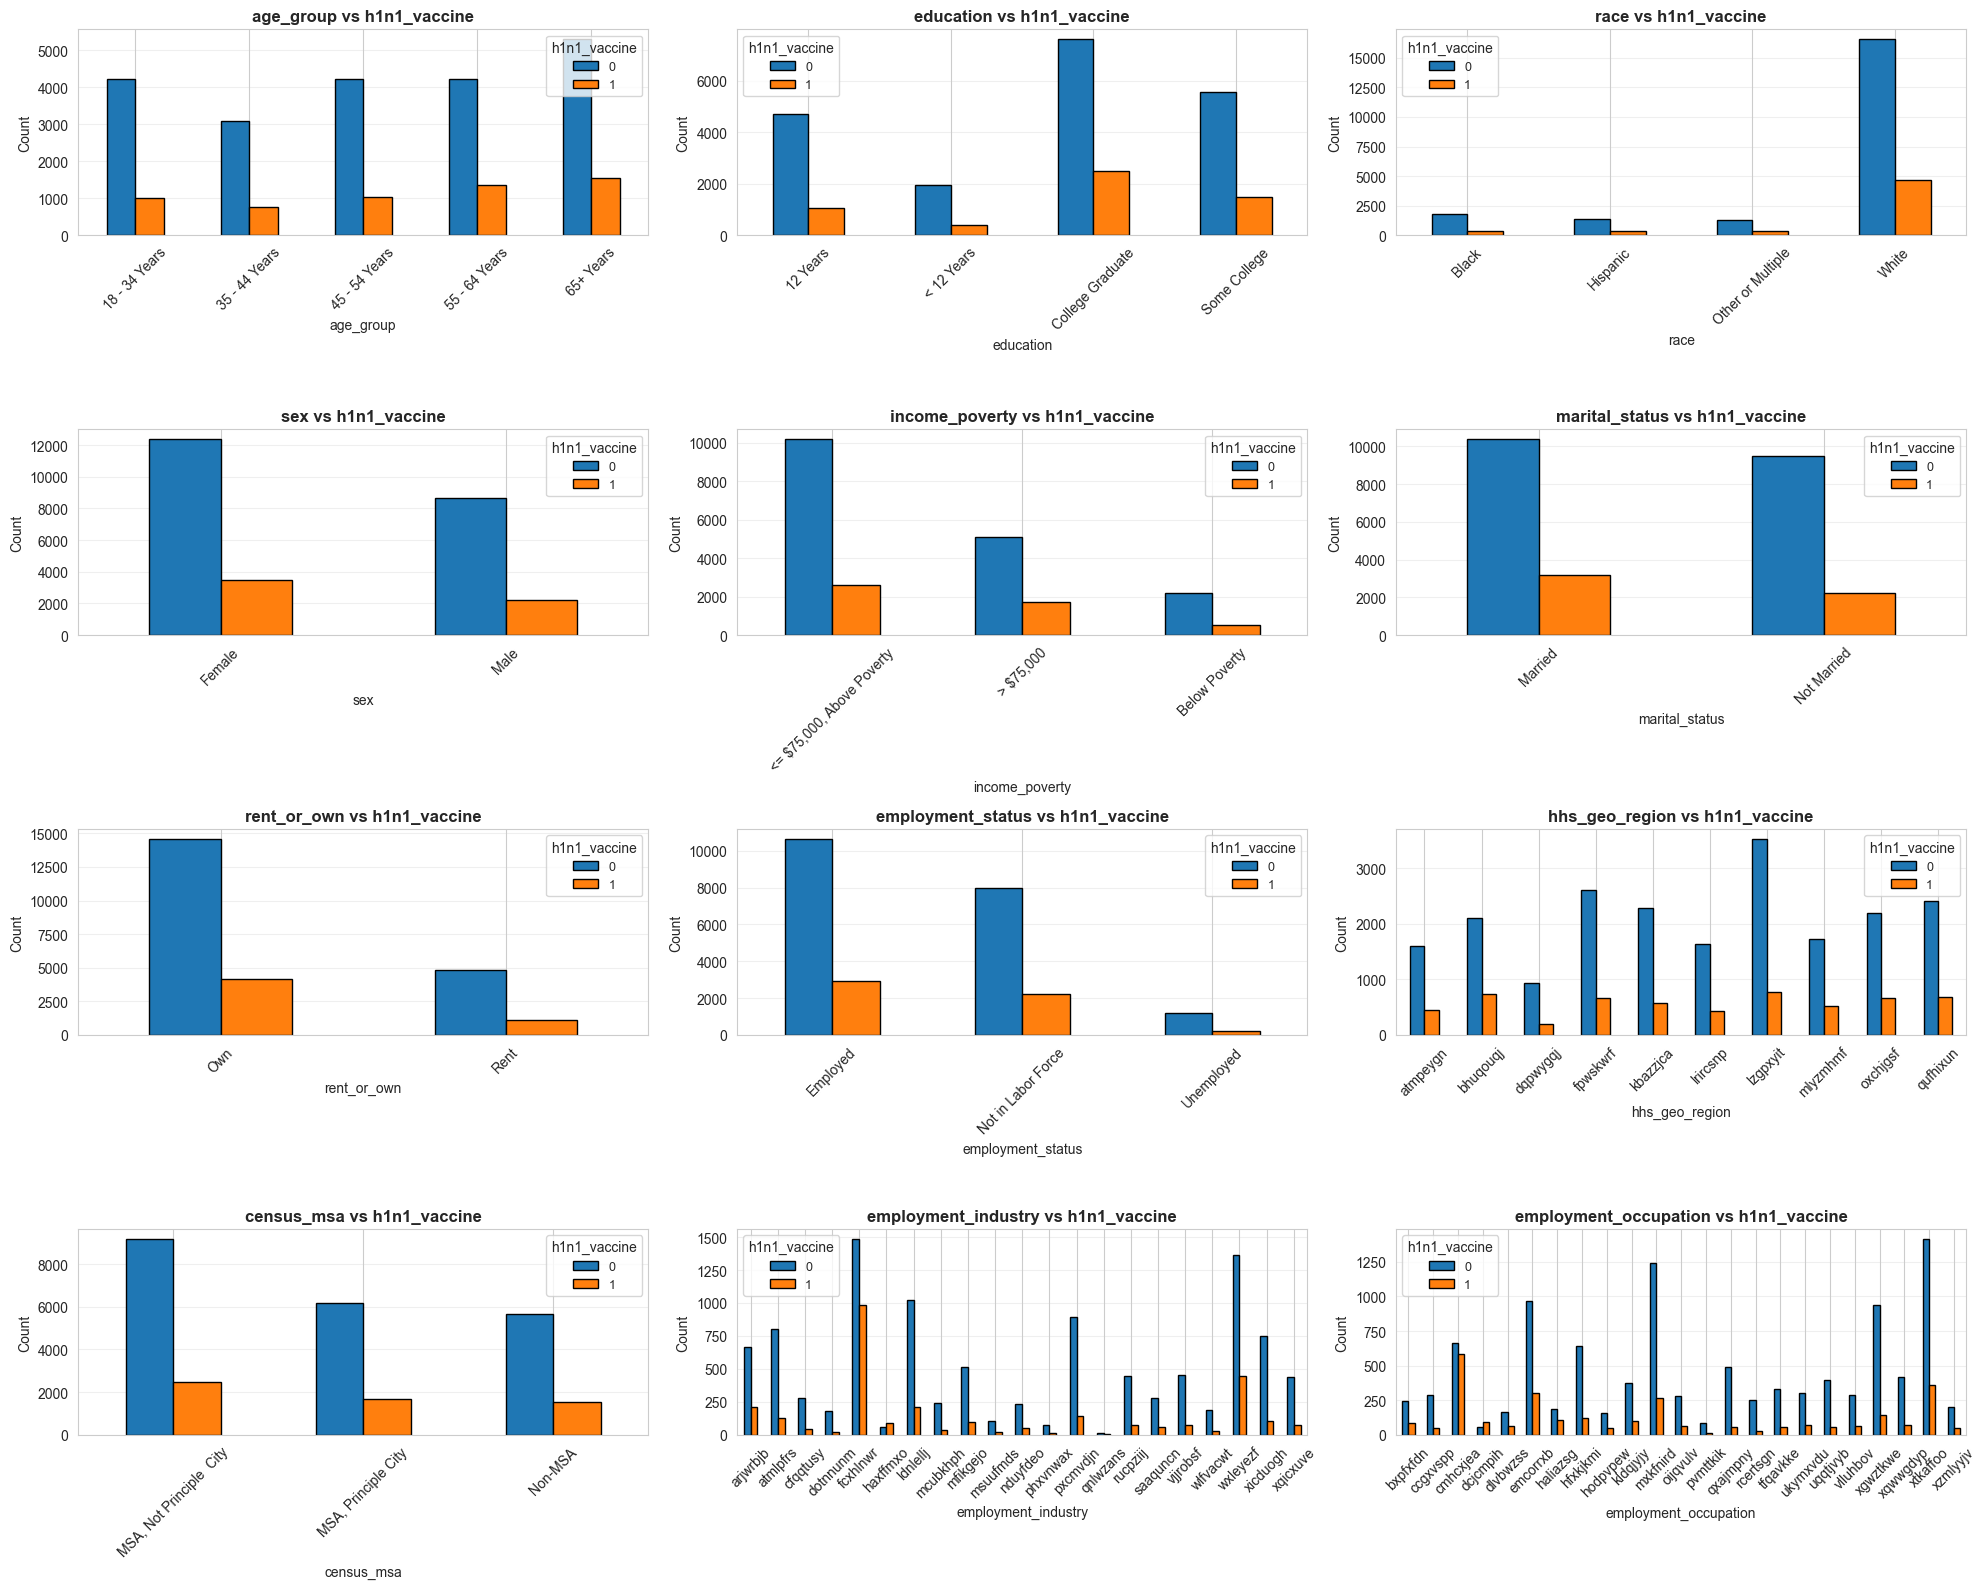

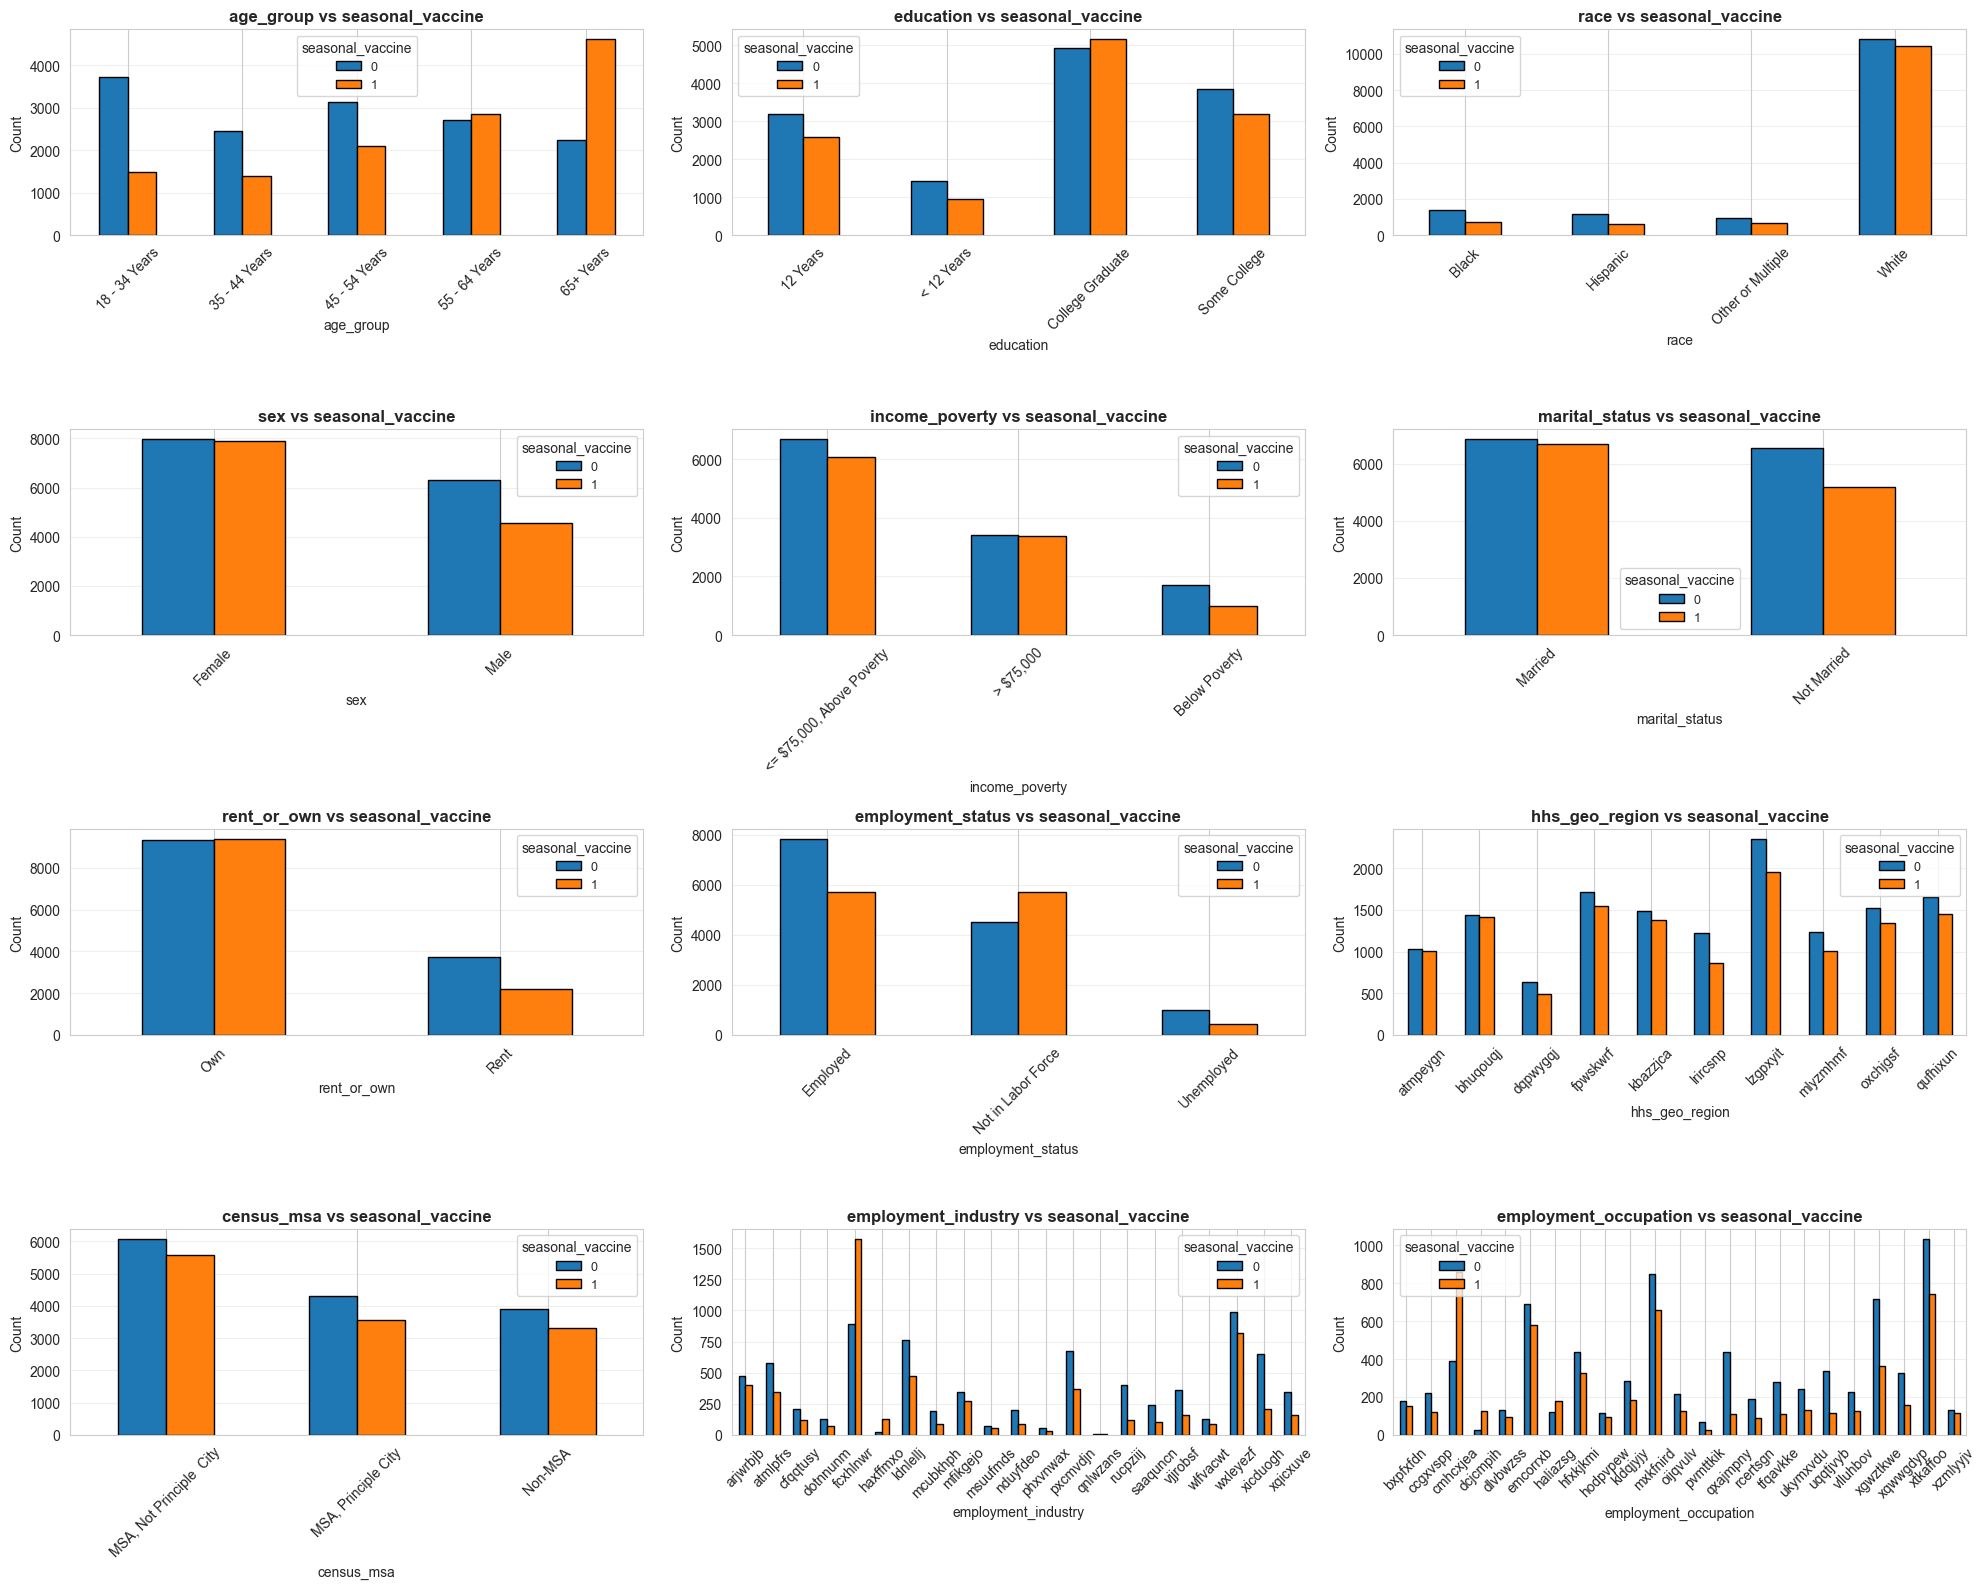

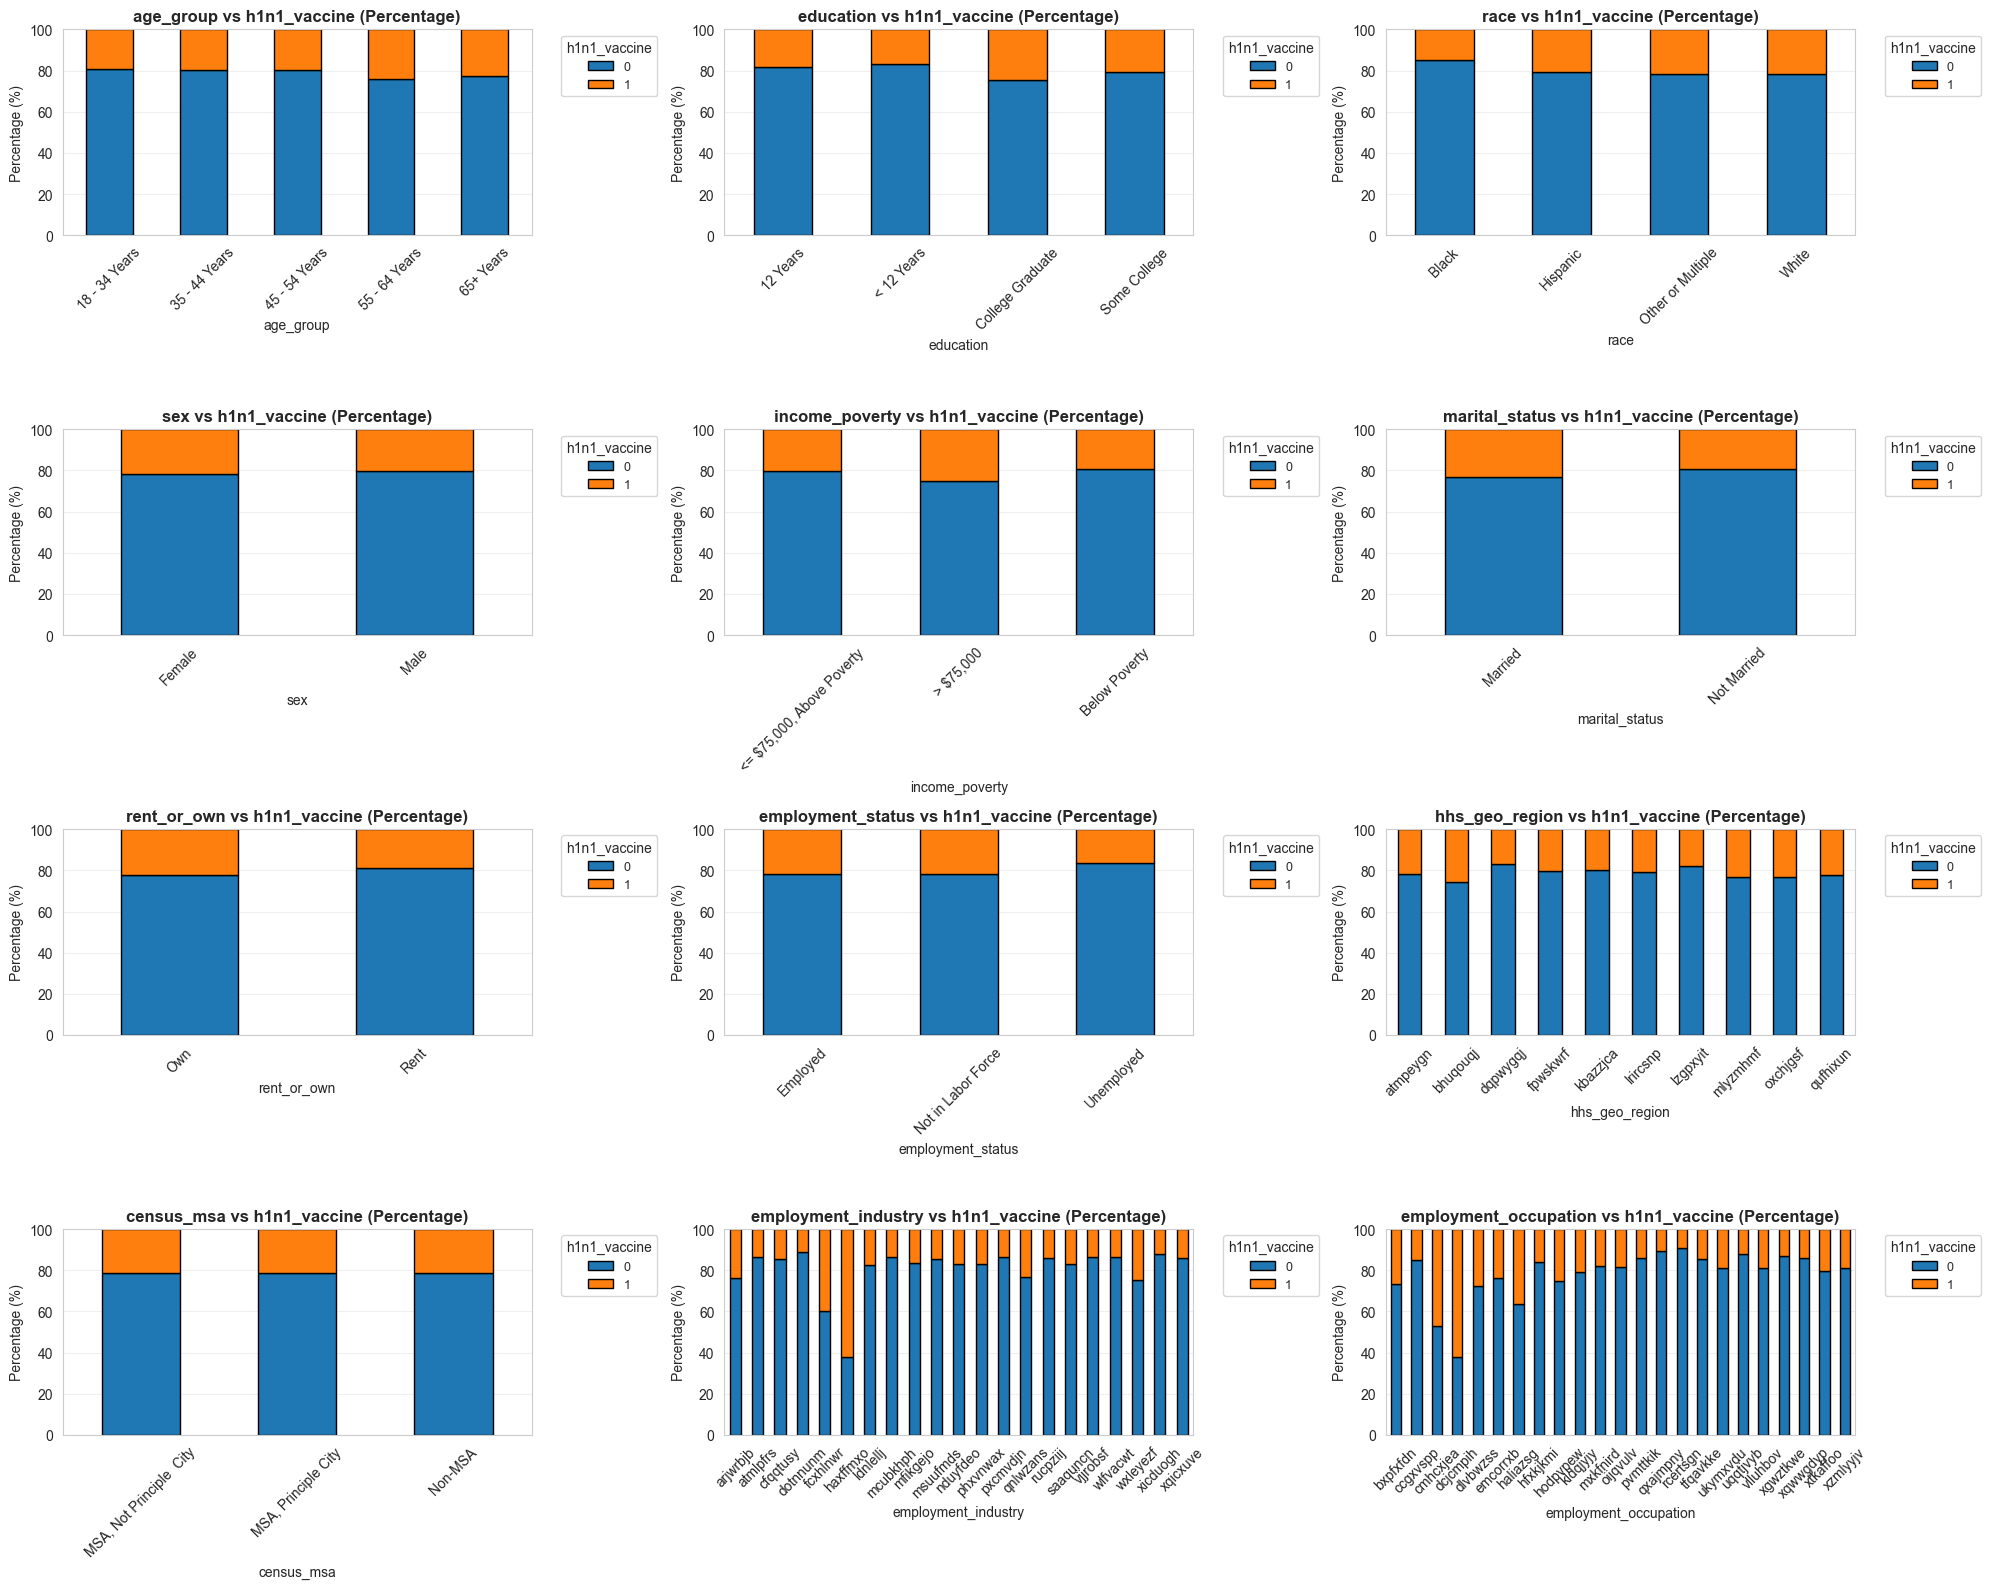

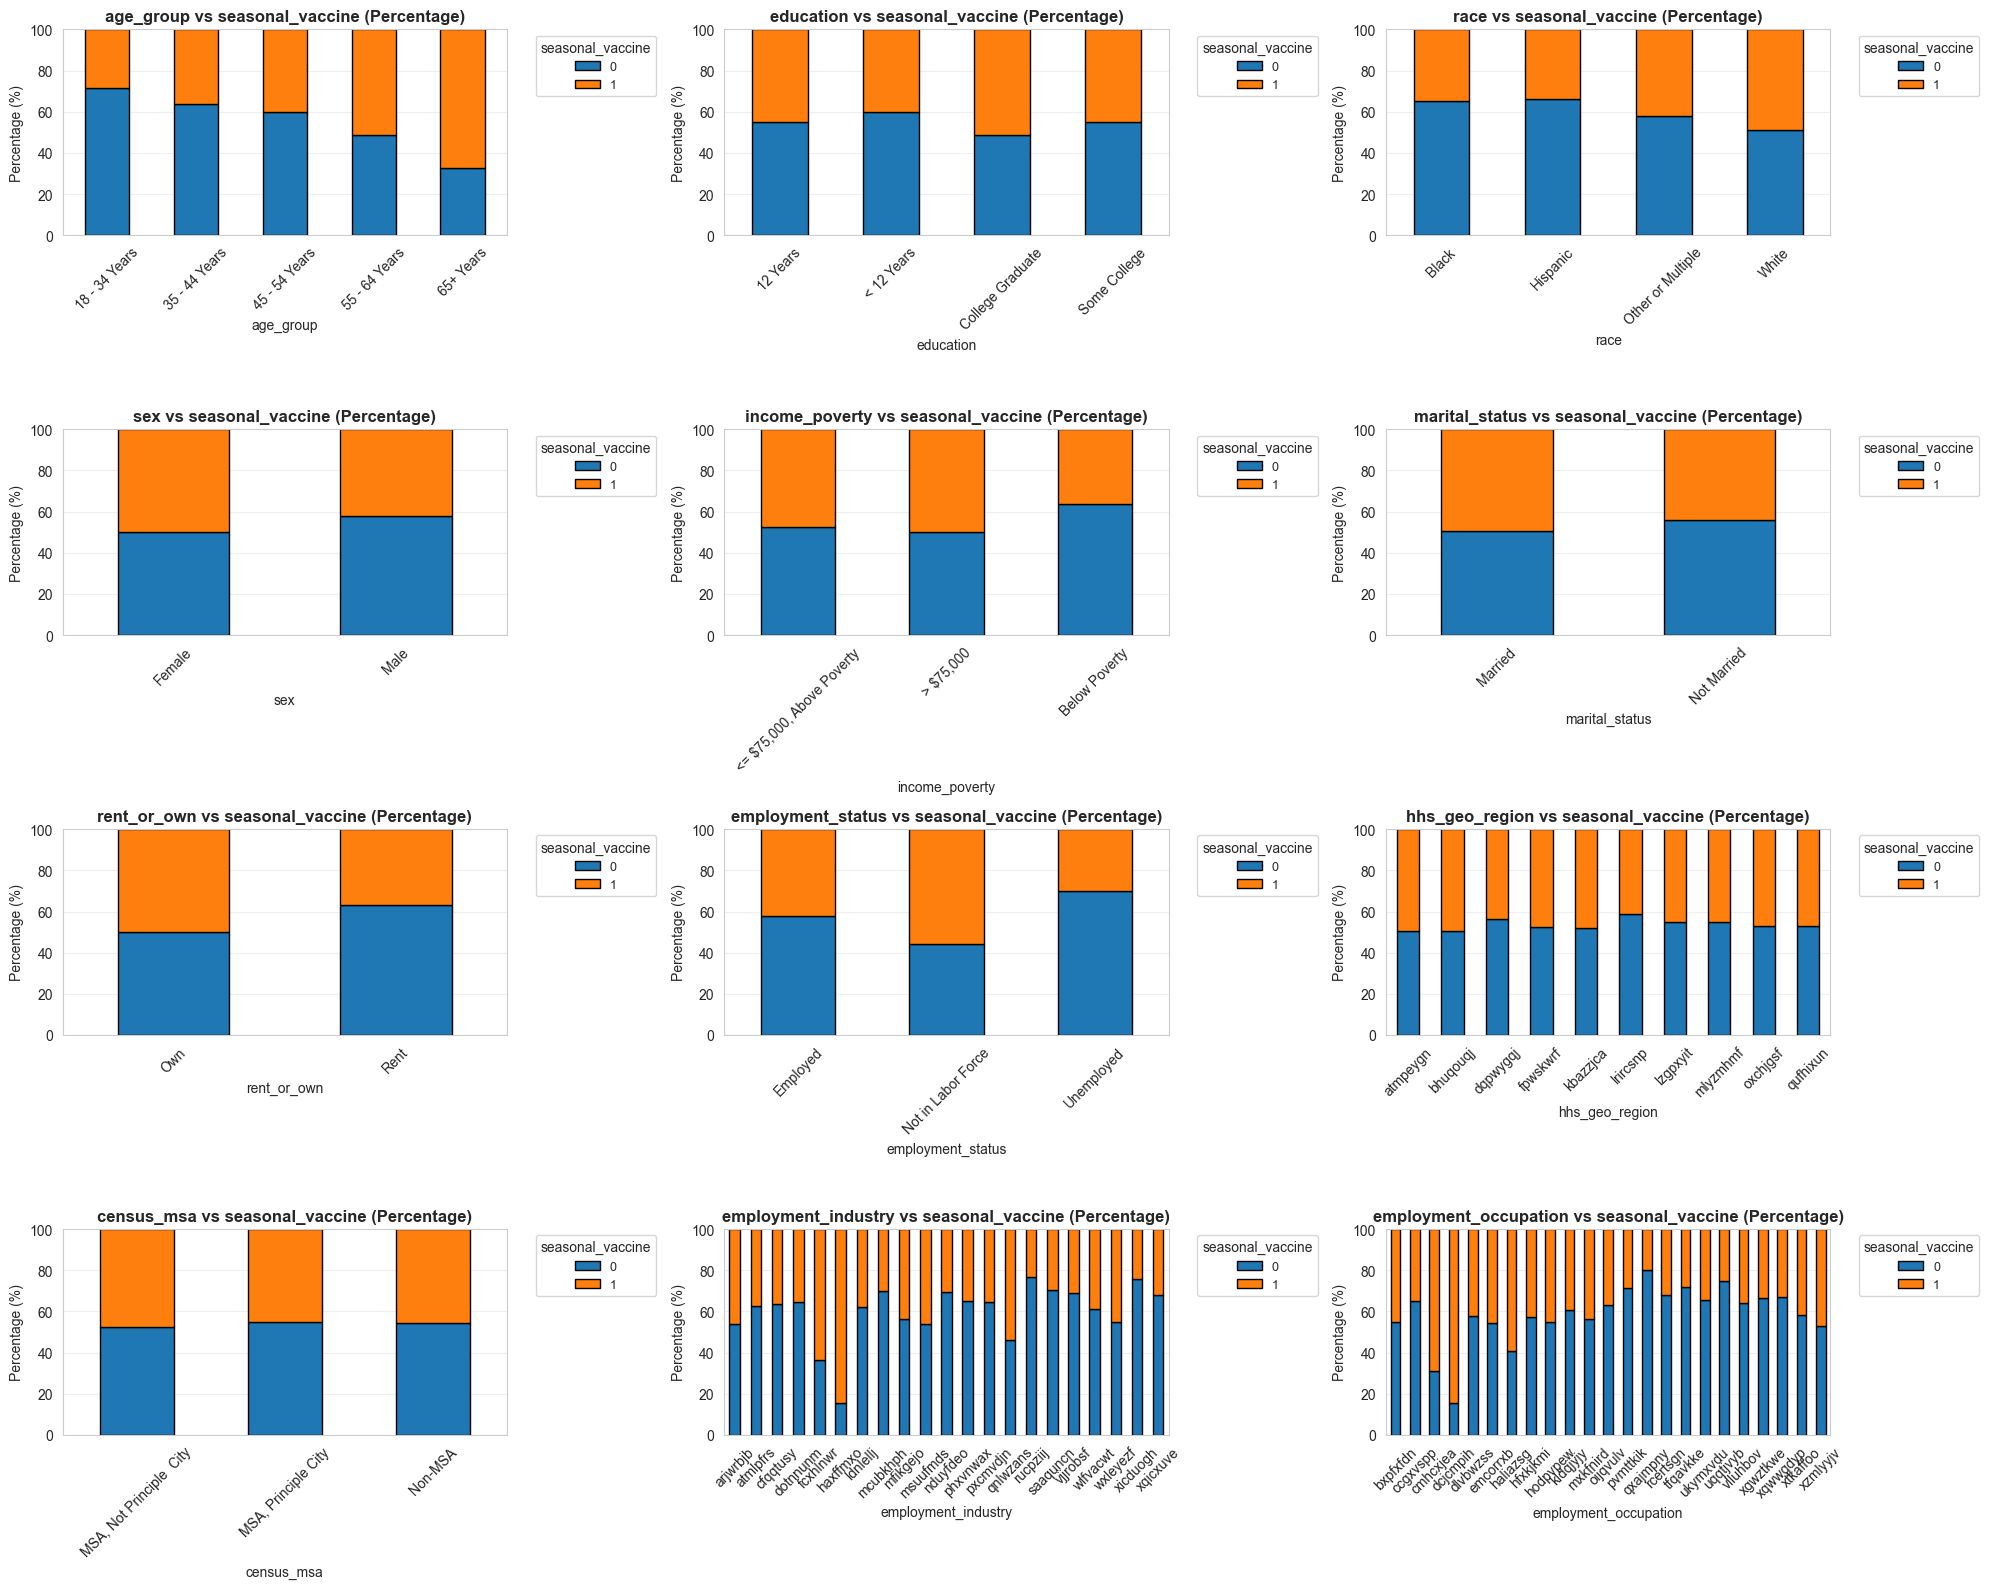


11. GENERATING HEATMAPS...


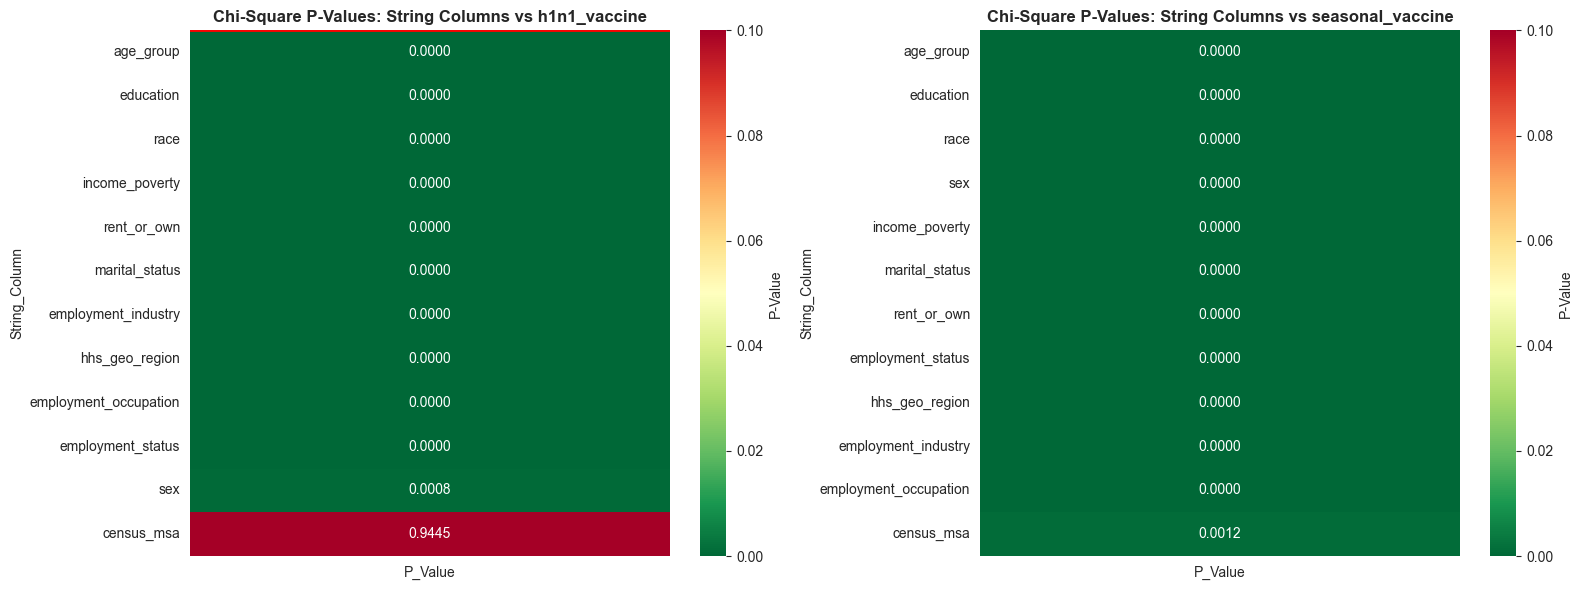

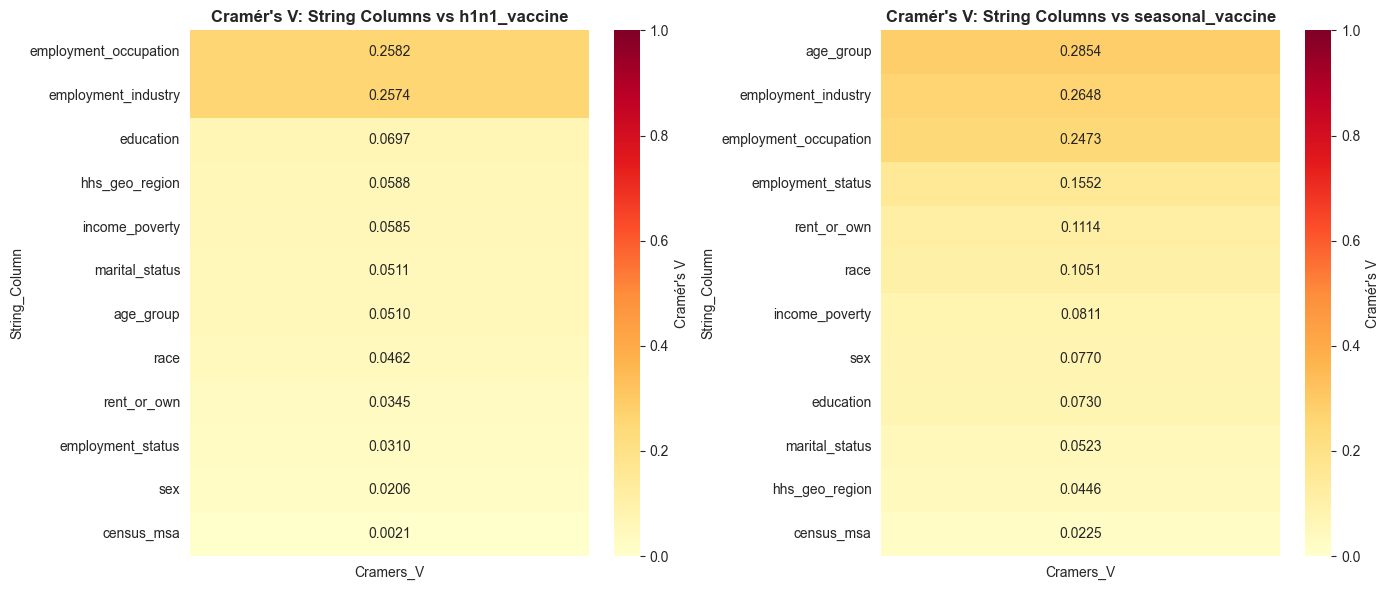


13. COMPARISON: H1N1 vs SEASONAL TARGETS

        String_Column  H1N1_Cramers_V  Seasonal_Cramers_V  Difference
employment_occupation          0.2582              0.2473      0.0109
  employment_industry          0.2574              0.2648      0.0074
            education          0.0697              0.0730      0.0033
       hhs_geo_region          0.0588              0.0446      0.0142
       income_poverty          0.0585              0.0811      0.0226
       marital_status          0.0511              0.0523      0.0012
            age_group          0.0510              0.2854      0.2344
                 race          0.0462              0.1051      0.0589
          rent_or_own          0.0345              0.1114      0.0769
    employment_status          0.0310              0.1552      0.1242
                  sex          0.0206              0.0770      0.0564
           census_msa          0.0021              0.0225      0.0204

14. SUMMARY & RECOMMENDATIONS

STRING COLUMNS 

In [101]:


# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# ============================================================
# 1. IDENTIFY STRING COLUMNS
# ============================================================
print("="*80)
print("1. IDENTIFYING STRING COLUMNS")
print("="*80)

string_cols = merged_df.select_dtypes(include=['object']).columns.tolist()
print(f"\nTotal String Columns: {len(string_cols)}")
print("\nString Columns:")
for col in string_cols:
    print(f"  - {col}")

# Define targets
target_h1n1 = 'h1n1_vaccine'
target_seasonal = 'seasonal_vaccine'

# ============================================================
# 2. VALUE COUNTS FOR EACH STRING COLUMN
# ============================================================
print("\n" + "="*80)
print("2. VALUE COUNTS FOR STRING COLUMNS")
print("="*80)

for col in string_cols:
    print(f"\n{col}:")
    print("-" * 60)
    print(merged_df[col].value_counts(dropna=False))
    print(f"Unique Values: {merged_df[col].nunique()}")
    print(f"Missing Values: {merged_df[col].isnull().sum()}")

# ============================================================
# 3. CROSS-TABULATION: STRING COLUMNS vs H1N1 VACCINE
# ============================================================
print("\n" + "="*80)
print("3. CROSS-TABULATION: STRING COLUMNS vs H1N1 VACCINE")
print("="*80)

for col in string_cols:
    print(f"\n{col} vs {target_h1n1}:")
    print("-" * 80)
    crosstab = pd.crosstab(merged_df[col], merged_df[target_h1n1], margins=True)
    print(crosstab)
    
    # Calculate percentages
    print(f"\nPercentage Distribution:")
    crosstab_pct = pd.crosstab(merged_df[col], merged_df[target_h1n1], normalize='index') * 100
    print(crosstab_pct.round(2))

# ============================================================
# 4. CROSS-TABULATION: STRING COLUMNS vs SEASONAL VACCINE
# ============================================================
print("\n" + "="*80)
print("4. CROSS-TABULATION: STRING COLUMNS vs SEASONAL VACCINE")
print("="*80)

for col in string_cols:
    print(f"\n{col} vs {target_seasonal}:")
    print("-" * 80)
    crosstab = pd.crosstab(merged_df[col], merged_df[target_seasonal], margins=True)
    print(crosstab)
    
    # Calculate percentages
    print(f"\nPercentage Distribution:")
    crosstab_pct = pd.crosstab(merged_df[col], merged_df[target_seasonal], normalize='index') * 100
    print(crosstab_pct.round(2))

# ============================================================
# 5. CHI-SQUARE TEST: STRING COLUMNS vs TARGETS
# ============================================================
print("\n" + "="*80)
print("5. CHI-SQUARE TEST (Independence Test)")
print("="*80)
print("(p-value < 0.05 suggests relationship between variables)")
print("="*80)

from scipy.stats import chi2_contingency

chi_square_results_h1n1 = []
chi_square_results_seasonal = []

for col in string_cols:
    # Remove null values for chi-square test
    clean_data = merged_df[[col, target_h1n1, target_seasonal]].dropna()
    
    # H1N1 Test
    crosstab_h1n1 = pd.crosstab(clean_data[col], clean_data[target_h1n1])
    chi2_h1n1, p_h1n1, dof_h1n1, expected_h1n1 = chi2_contingency(crosstab_h1n1)
    
    chi_square_results_h1n1.append({
        'String_Column': col,
        'Chi2_Statistic': round(chi2_h1n1, 4),
        'P_Value': round(p_h1n1, 6),
        'Significant': "Yes" if p_h1n1 < 0.05 else "No",
        'DOF': dof_h1n1
    })
    
    # Seasonal Test
    crosstab_seasonal = pd.crosstab(clean_data[col], clean_data[target_seasonal])
    chi2_seasonal, p_seasonal, dof_seasonal, expected_seasonal = chi2_contingency(crosstab_seasonal)
    
    chi_square_results_seasonal.append({
        'String_Column': col,
        'Chi2_Statistic': round(chi2_seasonal, 4),
        'P_Value': round(p_seasonal, 6),
        'Significant': "Yes" if p_seasonal < 0.05 else "No",
        'DOF': dof_seasonal
    })

chi2_df_h1n1 = pd.DataFrame(chi_square_results_h1n1).sort_values('P_Value')
chi2_df_seasonal = pd.DataFrame(chi_square_results_seasonal).sort_values('P_Value')

print(f"\nCHI-SQUARE TEST WITH H1N1 VACCINE:")
print(chi2_df_h1n1.to_string(index=False))

print(f"\n\nCHI-SQUARE TEST WITH SEASONAL VACCINE:")
print(chi2_df_seasonal.to_string(index=False))

# ============================================================
# 6. CRAMÉR'S V: EFFECT SIZE FOR STRING COLUMNS
# ============================================================
print("\n" + "="*80)
print("6. CRAMÉR'S V - ASSOCIATION STRENGTH (0 to 1)")
print("="*80)
print("0 = No association, 1 = Perfect association")
print("0.1-0.3 = Small, 0.3-0.5 = Medium, >0.5 = Large")
print("="*80)

def cramers_v(x, y):
    """Calculate Cramér's V statistic for categorical-categorical association."""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape) - 1
    return np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0

cramers_h1n1 = []
cramers_seasonal = []

for col in string_cols:
    clean_data = merged_df[[col, target_h1n1, target_seasonal]].dropna()
    
    v_h1n1 = cramers_v(clean_data[col], clean_data[target_h1n1])
    v_seasonal = cramers_v(clean_data[col], clean_data[target_seasonal])
    
    # Classify effect size
    def effect_size(v):
        if v < 0.1:
            return "Negligible"
        elif v < 0.3:
            return "Small"
        elif v < 0.5:
            return "Medium"
        else:
            return "Large"
    
    cramers_h1n1.append({
        'String_Column': col,
        'Cramers_V': round(v_h1n1, 4),
        'Effect_Size': effect_size(v_h1n1)
    })
    
    cramers_seasonal.append({
        'String_Column': col,
        'Cramers_V': round(v_seasonal, 4),
        'Effect_Size': effect_size(v_seasonal)
    })

cramers_h1n1_df = pd.DataFrame(cramers_h1n1).sort_values('Cramers_V', ascending=False)
cramers_seasonal_df = pd.DataFrame(cramers_seasonal).sort_values('Cramers_V', ascending=False)

print(f"\nCRAMÉR'S V WITH H1N1 VACCINE:")
print(cramers_h1n1_df.to_string(index=False))

print(f"\n\nCRAMÉR'S V WITH SEASONAL VACCINE:")
print(cramers_seasonal_df.to_string(index=False))

# ============================================================
# 7. VISUALIZATION: STACKED BAR CHARTS - H1N1 VACCINE
# ============================================================
print("\n" + "="*80)
print("7. GENERATING VISUALIZATIONS...")
print("="*80)

n_cols = len(string_cols)
n_rows = (n_cols + 2) // 3

fig, axes = plt.subplots(n_rows, 3, figsize=(20, n_rows * 4))
axes = axes.flatten()

for idx, col in enumerate(string_cols):
    crosstab = pd.crosstab(merged_df[col], merged_df[target_h1n1])
    crosstab.plot(kind='bar', ax=axes[idx], stacked=False, edgecolor='black')
    axes[idx].set_title(f'{col} vs {target_h1n1}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel('Count', fontsize=10)
    axes[idx].legend(title=target_h1n1, fontsize=9)
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(True, alpha=0.3, axis='y')

# Hide extra subplots
for idx in range(len(string_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('EDA_plots/string_cols_vs_h1n1_vaccine.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 8. VISUALIZATION: STACKED BAR CHARTS - SEASONAL VACCINE
# ============================================================

fig, axes = plt.subplots(n_rows, 3, figsize=(20, n_rows * 4))
axes = axes.flatten()

for idx, col in enumerate(string_cols):
    crosstab = pd.crosstab(merged_df[col], merged_df[target_seasonal])
    crosstab.plot(kind='bar', ax=axes[idx], stacked=False, edgecolor='black')
    axes[idx].set_title(f'{col} vs {target_seasonal}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel('Count', fontsize=10)
    axes[idx].legend(title=target_seasonal, fontsize=9)
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(True, alpha=0.3, axis='y')

# Hide extra subplots
for idx in range(len(string_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('EDA_plots/string_cols_vs_seasonal_vaccine.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 9. VISUALIZATION: PERCENTAGE STACKED BAR CHARTS - H1N1
# ============================================================

fig, axes = plt.subplots(n_rows, 3, figsize=(20, n_rows * 4))
axes = axes.flatten()

for idx, col in enumerate(string_cols):
    crosstab = pd.crosstab(merged_df[col], merged_df[target_h1n1], normalize='index') * 100
    crosstab.plot(kind='bar', ax=axes[idx], stacked=True, edgecolor='black')
    axes[idx].set_title(f'{col} vs {target_h1n1} (Percentage)', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel('Percentage (%)', fontsize=10)
    axes[idx].legend(title=target_h1n1, fontsize=9, bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(True, alpha=0.3, axis='y')
    axes[idx].set_ylim([0, 100])

# Hide extra subplots
for idx in range(len(string_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('EDA_plots/string_cols_vs_h1n1_vaccine_percentage.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 10. VISUALIZATION: PERCENTAGE STACKED BAR CHARTS - SEASONAL
# ============================================================

fig, axes = plt.subplots(n_rows, 3, figsize=(20, n_rows * 4))
axes = axes.flatten()

for idx, col in enumerate(string_cols):
    crosstab = pd.crosstab(merged_df[col], merged_df[target_seasonal], normalize='index') * 100
    crosstab.plot(kind='bar', ax=axes[idx], stacked=True, edgecolor='black')
    axes[idx].set_title(f'{col} vs {target_seasonal} (Percentage)', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel('Percentage (%)', fontsize=10)
    axes[idx].legend(title=target_seasonal, fontsize=9, bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(True, alpha=0.3, axis='y')
    axes[idx].set_ylim([0, 100])

# Hide extra subplots
for idx in range(len(string_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('EDA_plots/string_cols_vs_seasonal_vaccine_percentage.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 11. HEATMAP: CHI-SQUARE P-VALUES
# ============================================================

print("\n11. GENERATING HEATMAPS...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Prepare data for heatmap
chi2_pivot_h1n1 = chi2_df_h1n1.set_index('String_Column')[['P_Value']]
chi2_pivot_seasonal = chi2_df_seasonal.set_index('String_Column')[['P_Value']]

# H1N1 Heatmap
sns.heatmap(chi2_pivot_h1n1, annot=True, fmt='.4f', cmap='RdYlGn_r', 
            cbar_kws={'label': 'P-Value'}, ax=axes[0], vmin=0, vmax=0.1)
axes[0].set_title(f'Chi-Square P-Values: String Columns vs {target_h1n1}', 
                  fontsize=12, fontweight='bold')
axes[0].axhline(y=0, color='red', linewidth=2)

# Seasonal Heatmap
sns.heatmap(chi2_pivot_seasonal, annot=True, fmt='.4f', cmap='RdYlGn_r', 
            cbar_kws={'label': 'P-Value'}, ax=axes[1], vmin=0, vmax=0.1)
axes[1].set_title(f'Chi-Square P-Values: String Columns vs {target_seasonal}', 
                  fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('EDA_plots/chi_square_pvalues_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 12. HEATMAP: CRAMÉR'S V VALUES
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cramers_pivot_h1n1 = cramers_h1n1_df.set_index('String_Column')[['Cramers_V']]
cramers_pivot_seasonal = cramers_seasonal_df.set_index('String_Column')[['Cramers_V']]

sns.heatmap(cramers_pivot_h1n1, annot=True, fmt='.4f', cmap='YlOrRd', 
            cbar_kws={'label': "Cramér's V"}, ax=axes[0], vmin=0, vmax=1)
axes[0].set_title(f"Cramér's V: String Columns vs {target_h1n1}", 
                  fontsize=12, fontweight='bold')

sns.heatmap(cramers_pivot_seasonal, annot=True, fmt='.4f', cmap='YlOrRd', 
            cbar_kws={'label': "Cramér's V"}, ax=axes[1], vmin=0, vmax=1)
axes[1].set_title(f"Cramér's V: String Columns vs {target_seasonal}", 
                  fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('EDA_plots/cramers_v_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 13. COMPARISON: H1N1 vs SEASONAL TARGETS
# ============================================================
print("\n" + "="*80)
print("13. COMPARISON: H1N1 vs SEASONAL TARGETS")
print("="*80)

comparison_df = pd.DataFrame({
    'String_Column': cramers_h1n1_df['String_Column'],
    'H1N1_Cramers_V': cramers_h1n1_df['Cramers_V'].values,
    'Seasonal_Cramers_V': cramers_seasonal_df.set_index('String_Column').loc[
        cramers_h1n1_df['String_Column'], 'Cramers_V'].values,
})

comparison_df['Difference'] = abs(comparison_df['H1N1_Cramers_V'] - comparison_df['Seasonal_Cramers_V'])
comparison_df = comparison_df.sort_values('H1N1_Cramers_V', ascending=False)

print("\n" + comparison_df.to_string(index=False))

# ============================================================
# 14. SUMMARY & RECOMMENDATIONS
# ============================================================
print("\n" + "="*80)
print("14. SUMMARY & RECOMMENDATIONS")
print("="*80)

significant_h1n1 = chi2_df_h1n1[chi2_df_h1n1['Significant'] == 'Yes']
significant_seasonal = chi2_df_seasonal[chi2_df_seasonal['Significant'] == 'Yes']

strong_h1n1 = cramers_h1n1_df[cramers_h1n1_df['Effect_Size'].isin(['Large', 'Medium'])]['String_Column'].tolist()
strong_seasonal = cramers_seasonal_df[cramers_seasonal_df['Effect_Size'].isin(['Large', 'Medium'])]['String_Column'].tolist()

print(f"""
STRING COLUMNS ANALYSIS RESULTS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📊 SIGNIFICANT ASSOCIATIONS (Chi-Square p < 0.05):

H1N1 VACCINE:
  • Count: {len(significant_h1n1)} columns
  • Columns: {', '.join(significant_h1n1['String_Column'].tolist())}

SEASONAL VACCINE:
  • Count: {len(significant_seasonal)} columns
  • Columns: {', '.join(significant_seasonal['String_Column'].tolist())}

💪 STRONG PREDICTORS (Cramér's V > 0.3):

H1N1 VACCINE:
  • Columns: {', '.join(strong_h1n1) if strong_h1n1 else 'None'}

SEASONAL VACCINE:
  • Columns: {', '.join(strong_seasonal) if strong_seasonal else 'None'}

🎯 TOP 3 FEATURES FOR EACH TARGET:

H1N1 VACCINE:
{cramers_h1n1_df.head(3)[['String_Column', 'Cramers_V', 'Effect_Size']].to_string(index=False)}

SEASONAL VACCINE:
{cramers_seasonal_df.head(3)[['String_Column', 'Cramers_V', 'Effect_Size']].to_string(index=False)}

📌 RECOMMENDATIONS:
  1. Keep columns with p < 0.05 (statistically significant)
  2. Prioritize columns with Cramér's V > 0.3 for modeling
  3. Use one-hot encoding for categorical variables before model building
  4. Consider dropping columns with negligible association (Cramér's V < 0.1)
  5. Both targets show similar patterns - features are generally consistent
""")

# ============================================================
# 15. EXPORT RESULTS TO CSV
# ============================================================

chi2_df_h1n1.to_csv('analysis_results_csv/chi_square_h1n1.csv', index=False)
chi2_df_seasonal.to_csv('analysis_results_csv/chi_square_seasonal.csv', index=False)
cramers_h1n1_df.to_csv('analysis_results_csv/cramers_v_h1n1.csv', index=False)
cramers_seasonal_df.to_csv('analysis_results_csv/cramers_v_seasonal.csv', index=False)
comparison_df.to_csv('analysis_results_csv/h1n1_vs_seasonal_comparison.csv', index=False)

print("\n✓ Results exported to CSV files:")
print("  - chi_square_h1n1.csv")
print("  - chi_square_seasonal.csv")
print("  - cramers_v_h1n1.csv")
print("  - cramers_v_seasonal.csv")
print("  - h1n1_vs_seasonal_comparison.csv")

PART 1: MISSING DATA OVERVIEW

employment_occupation Missing Data:
  Total rows: 26707
  Missing: 13470 (50.44%)
  Non-missing: 13237

PART 2: MISSING RATES BY GROUP

EMPLOYMENT_STATUS:


                    Has Value  Missing  Total  Missing %
employment_status                                       
Employed                13237      323  13560       2.38
Not in Labor Force          0    10231  10231     100.00
Unemployed                  0     1453   1453     100.00

EDUCATION:
                  Has Value  Missing  Total  Missing %
education                                             
12 Years               2435     3362   5797      58.00
< 12 Years              713     1650   2363      69.83
College Graduate       6444     3653  10097      36.18
Some College           3596     3447   7043      48.94

INCOME_POVERTY:
                           Has Value  Missing  Total  Missing %
income_poverty                                                 
<= $75,000, Above Poverty       6450     6327  12777      49.52
> $75,000                       4979     1831   6810      26.89
Below Poverty                    769     1928   2697      71.49

AGE_GROUP:
               Has Value

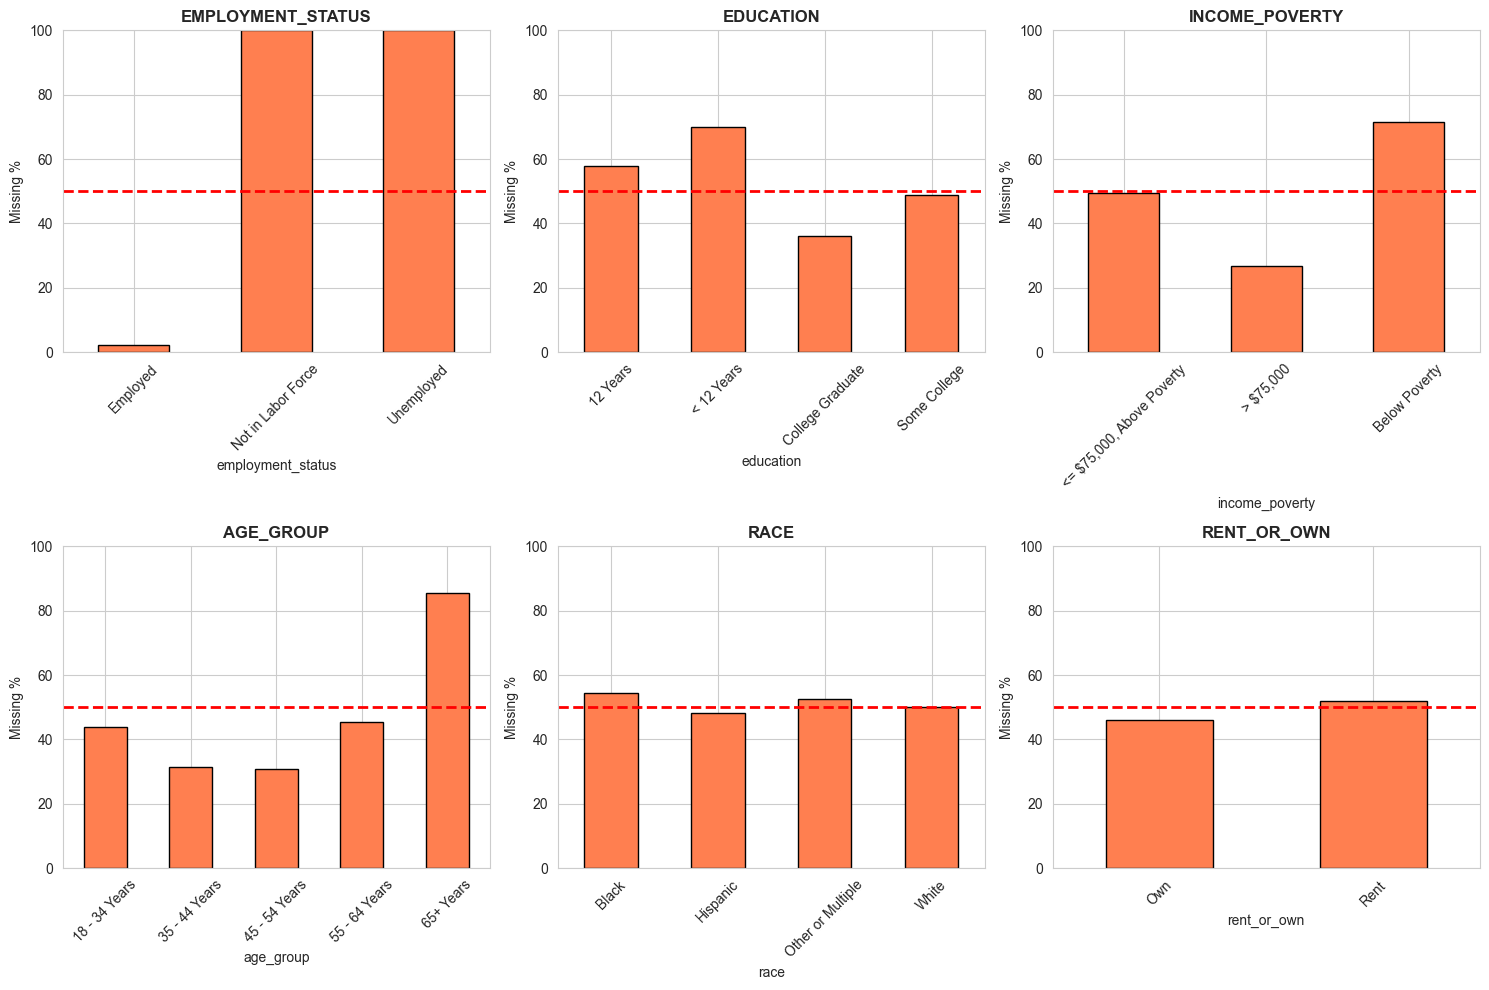

In [102]:


# CONFIGURATION
variables_to_check = ['employment_status', 'education', 'income_poverty', 
                      'age_group', 'race', 'rent_or_own']

# Assuming merged_df is already loaded
# If not, uncomment the line below:
# merged_df = pd.read_csv('your_data.csv')

# Create missing flag
merged_df['employment_occupation_missing'] = merged_df['employment_occupation'].isnull().astype(int)

# ===== 1. BASIC SUMMARY =====
print("="*60)
print("PART 1: MISSING DATA OVERVIEW")
print("="*60)

missing_count = merged_df['employment_occupation'].isnull().sum()
missing_rate = (missing_count / len(merged_df)) * 100

print(f"\nemployment_occupation Missing Data:")
print(f"  Total rows: {len(merged_df)}")
print(f"  Missing: {missing_count} ({missing_rate:.2f}%)")
print(f"  Non-missing: {len(merged_df) - missing_count}")

# ===== 2. MISSING RATES BY GROUP =====
print("\n" + "="*60)
print("PART 2: MISSING RATES BY GROUP")
print("="*60)

for var in variables_to_check:
    print(f"\n{var.upper()}:")
    missing_by_group = merged_df.groupby(var)['employment_occupation_missing'].agg([
        ('Has Value', lambda x: (x == 0).sum()),
        ('Missing', lambda x: (x == 1).sum()),
        ('Total', 'count'),
        ('Missing %', lambda x: (x.sum() / len(x) * 100).round(2))
    ])
    print(missing_by_group)

# ===== 3. CHI-SQUARE TESTS =====
print("\n" + "="*60)
print("PART 3: CHI-SQUARE TEST RESULTS")
print("="*60)

results = []

for var in variables_to_check:
    contingency = pd.crosstab(merged_df[var], merged_df['employment_occupation_missing'])
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    
    print(f"\n{var.upper()}: χ² = {chi2:.4f}, p-value = {p_value:.6f}", end="")
    
    if p_value < 0.05:
        print(" ✅ SIGNIFICANT")
        sig = "YES"
    else:
        print(" ❌ NOT SIGNIFICANT")
        sig = "NO"
    
    results.append({'Variable': var, 'Chi2': chi2, 'P-value': p_value, 'Significant': sig})

# ===== 4. SUMMARY TABLE =====
print("\n" + "="*60)
print("PART 4: SUMMARY TABLE")
print("="*60)

results_df = pd.DataFrame(results).sort_values('P-value')
print("\n" + results_df.to_string(index=False))

# ===== 5. FINAL RECOMMENDATION =====
print("\n" + "="*60)
print("FINAL RECOMMENDATION")
print("="*60)

significant_count = (results_df['P-value'] < 0.05).sum()

print(f"\nVariables related to missing: {significant_count}/6")
print(f"Missing percentage: {missing_rate:.2f}%")

if missing_rate > 50 and significant_count >= 2:
    print("\n🚨 RECOMMENDATION: EXCLUDE employment_occupation")
    print("   - Too much missing data (>50%)")
    print("   - Missing is NOT random (related to other variables)")
    print("   - Results would be BIASED if used")
elif missing_rate > 50:
    print("\n⚠️ RECOMMENDATION: EXCLUDE or use with caution")
    print("   - Too much missing data (>50%)")
elif significant_count >= 3:
    print("\n⚠️ RECOMMENDATION: EXCLUDE or use advanced methods")
    print("   - Missing is strongly related to other variables")
    print("   - Results would be biased")
else:
    print("\n✅ RECOMMENDATION: Can KEEP employment_occupation")
    print("   - Use listwise deletion or imputation")

print("\n" + "="*60)

# ===== 6. VISUALIZE =====
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, var in enumerate(variables_to_check):
    missing_rate_by_group = merged_df.groupby(var)['employment_occupation_missing'].apply(
        lambda x: (x.sum() / len(x) * 100)
    )
    missing_rate_by_group.plot(kind='bar', ax=axes[idx], color='coral', edgecolor='black')
    axes[idx].set_title(var.upper(), fontweight='bold')
    axes[idx].set_ylabel('Missing %')
    axes[idx].axhline(y=50, color='red', linestyle='--', linewidth=2)
    axes[idx].set_ylim(0, 100)
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('EDA_plots/missing_pattern_analysis.png', dpi=300, bbox_inches='tight')
print("\n✅ Chart saved as 'missing_pattern_analysis.png'")
plt.show()

"Employed": ~1% missing
"Not in Labor Force": ~100% missing
"Unemployed": ~100% missing


AGE_GROUP - Strong pattern
"65+ Years": ~85% missing (retirees don't have occupation)
Younger ages: 30-43% missing

INCOME_POVERTY - Strong pattern
"Below Poverty": ~73% missing
"Above $75,000": ~27% missing
Lower income = more likely missing occupation

EDUCATION - Moderate pattern
Varies 37-71% missing
Some education levels have higher missing rates

FILLING MISSING OCCUPATION DATA WITH SMART LOGIC

BEFORE:
Missing employment_occupation: 13470
Missing %: 50.44%

AFTER:
Missing employment_occupation: 0
Missing %: 0.00%

OCCUPATION VALUE COUNTS (INCLUDING SMART FILLS)

employment_occupation
Unknown Occupation    7624
Retired               5846
xtkaffoo              1778
mxkfnird              1509
emcorrxb              1270
cmhcxjea              1247
xgwztkwe              1082
hfxkjkmi               766
qxajmpny               548
xqwwgdyp               485
kldqjyjy               469
uqqtjvyb               452
tfqavkke               388
ukymxvdu               372
vlluhbov               354
oijqvulv               344
ccgxvspp               341
bxpfxfdn               331
haliazsg               296
rcertsgn               276
xzmlyyjv               248
dlvbwzss               227
hodpvpew               208
dcjcmpih               148
pvmttkik                98

FILL BREAKDOWN

Total Originally Missing: 13,470
  → Filled as 'Retired' (65+ Yea

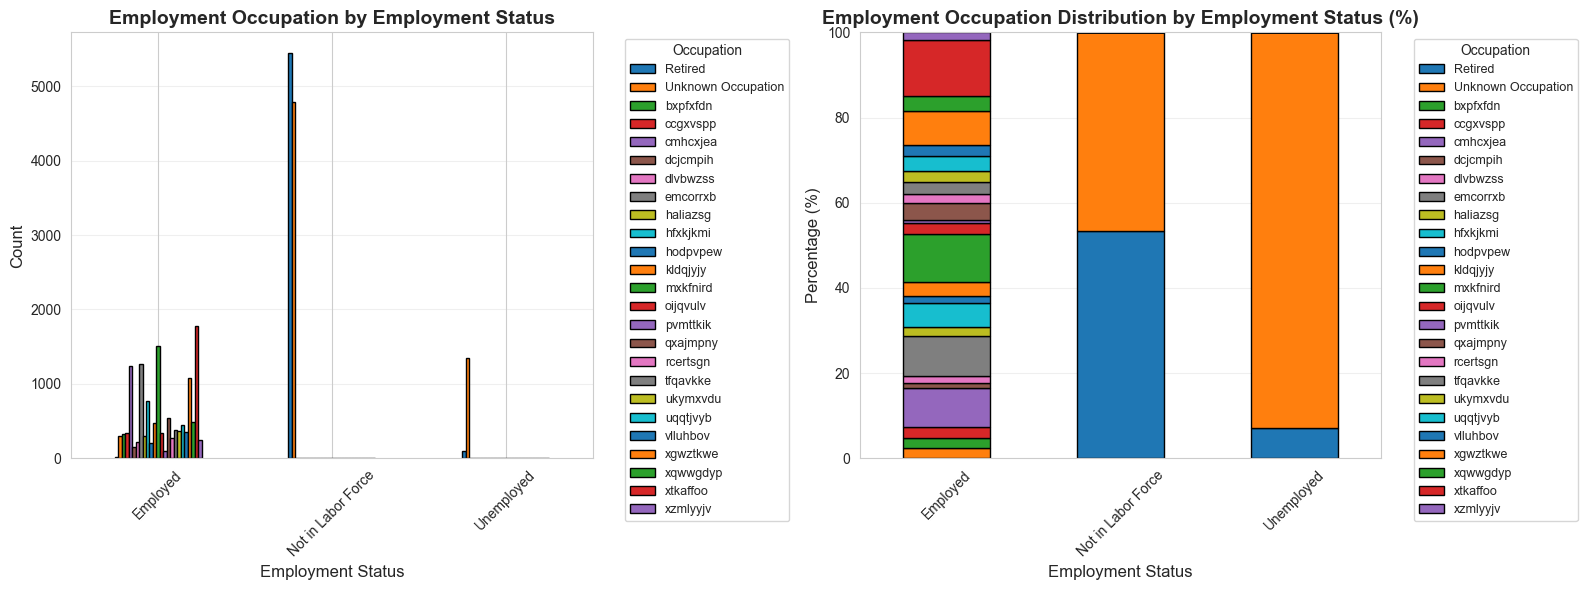

✅ Chart saved as 'occupation_filled_by_age.png'


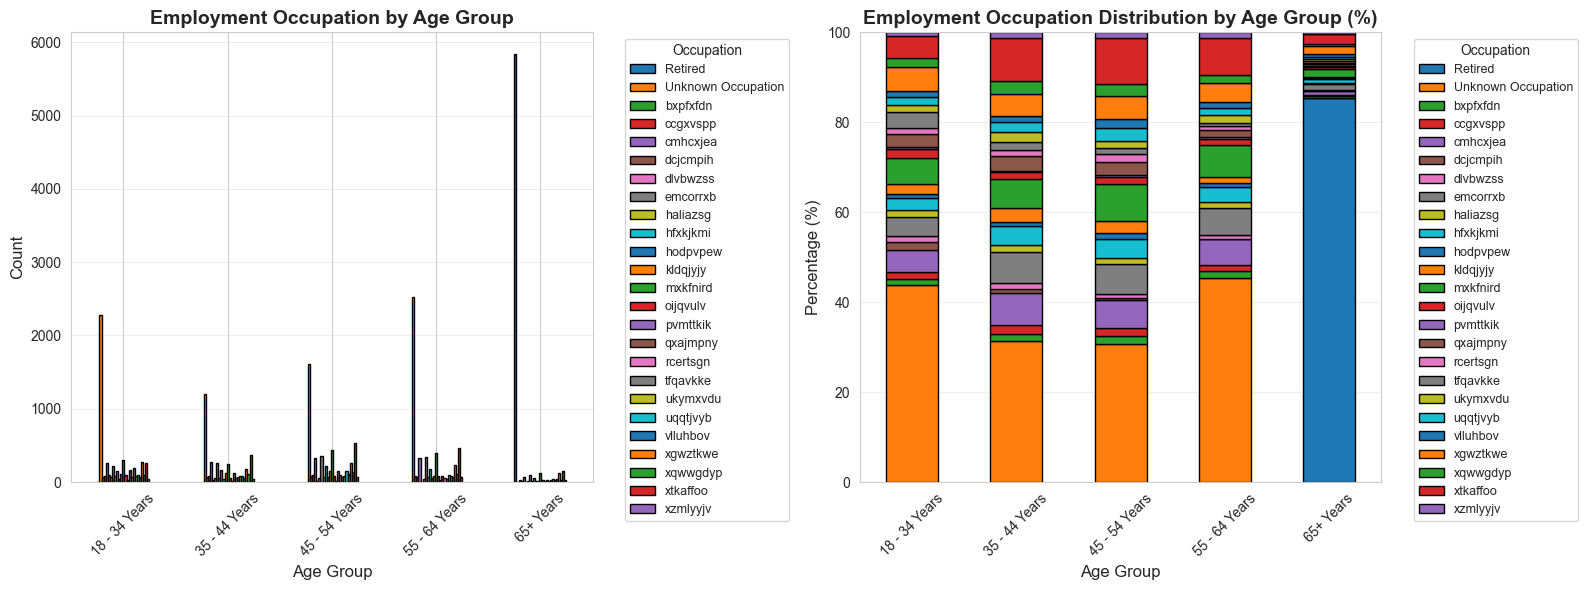

✅ Chart saved as 'top_occupations.png'


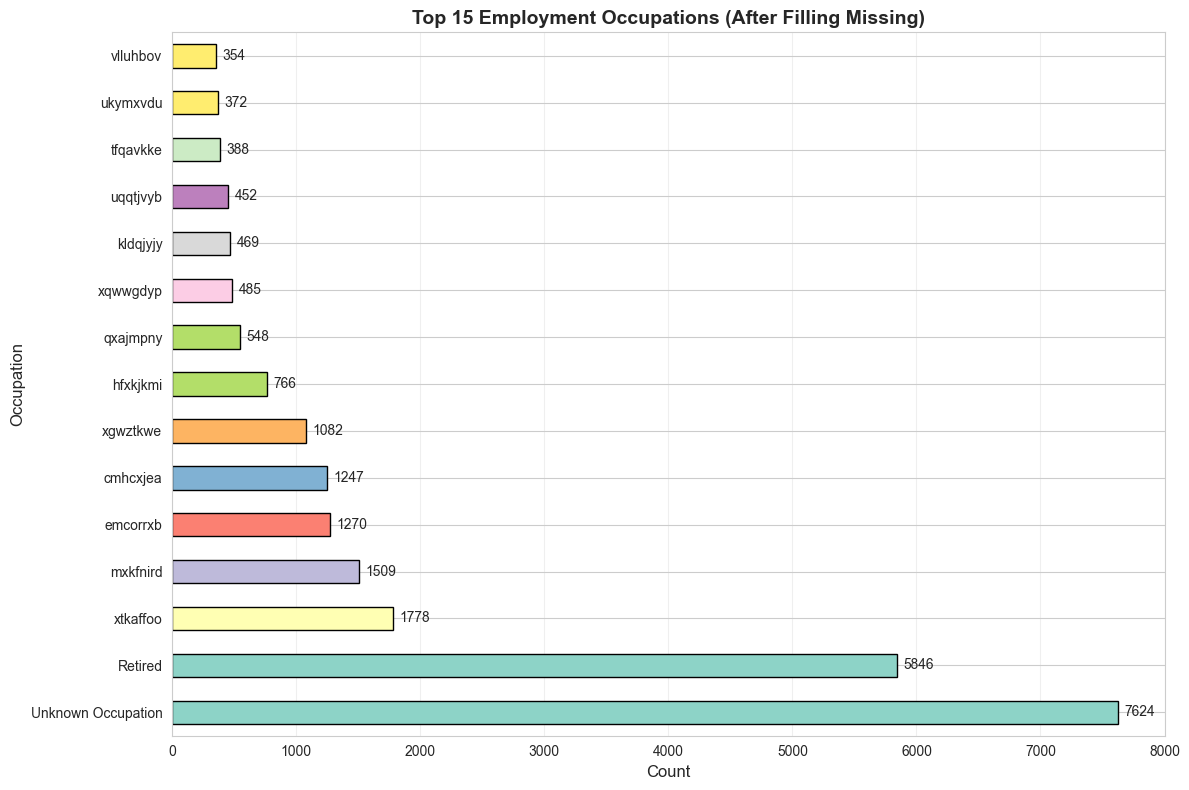


SUMMARY STATISTICS

Total Records: 26,707
Unique Occupations: 25

Occupation Counts:

   1. Unknown Occupation                                 :  7,624 (28.55%)
   2. Retired                                            :  5,846 (21.89%)
   3. xtkaffoo                                           :  1,778 ( 6.66%)
   4. mxkfnird                                           :  1,509 ( 5.65%)
   5. emcorrxb                                           :  1,270 ( 4.76%)
   6. cmhcxjea                                           :  1,247 ( 4.67%)
   7. xgwztkwe                                           :  1,082 ( 4.05%)
   8. hfxkjkmi                                           :    766 ( 2.87%)
   9. qxajmpny                                           :    548 ( 2.05%)
  10. xqwwgdyp                                           :    485 ( 1.82%)

  ... and 15 other occupations

VERIFICATION

✅ SUCCESS! No missing values in employment_occupation

CREATING HEATMAP...
✅ Chart saved as 'occupation_heatmap.png'

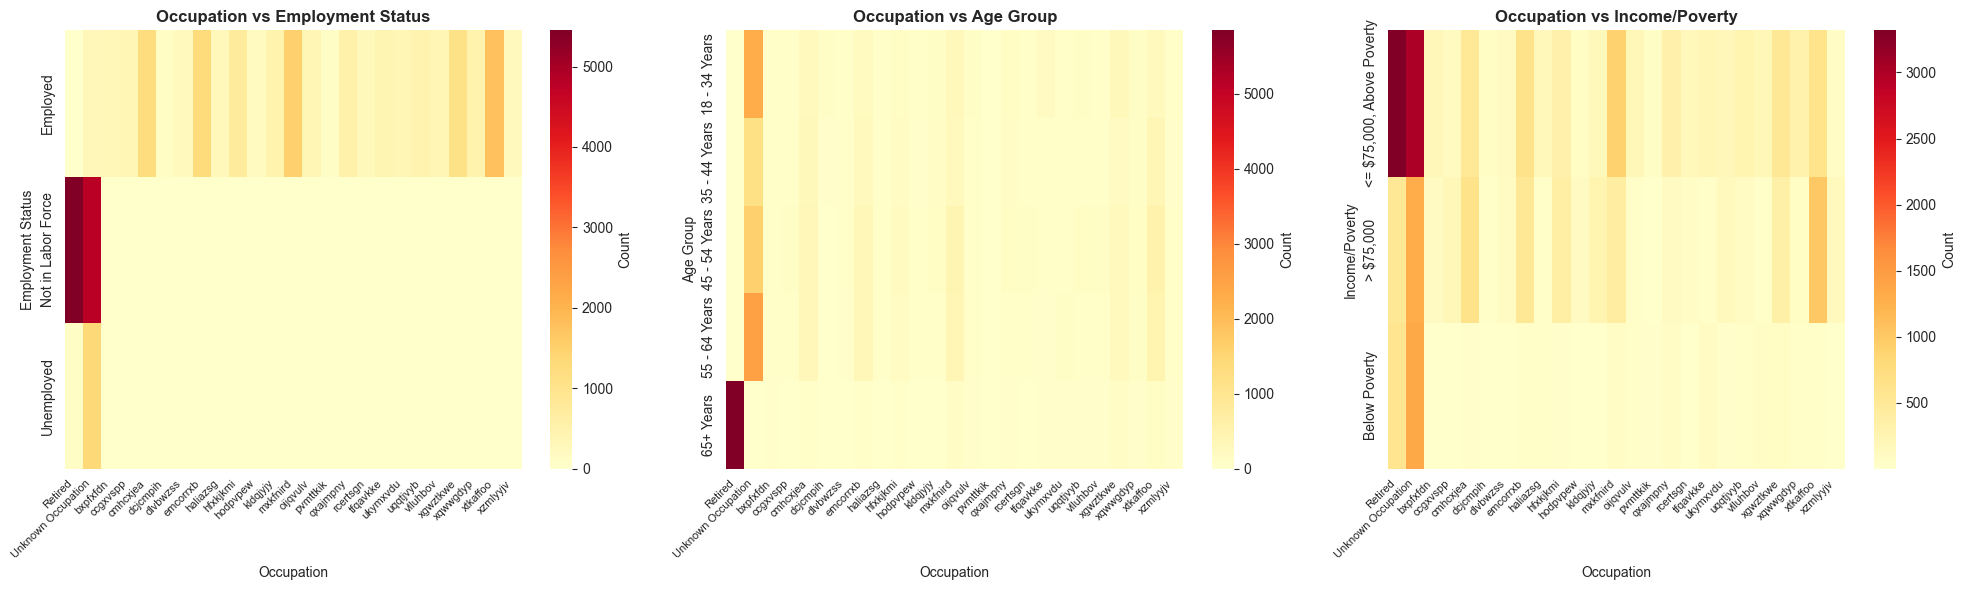


DETAILED BREAKDOWN: 65+ YEARS WITH 'RETIRED' FILL

65+ Years Age Group Analysis:
  Total 65+ Years: 6,843
  Filled as 'Retired': 5,846
  Percentage: 85.43%

Occupation Distribution for 65+ Years:
   1. Retired                                  :  5,846 (85.43%)
   2. xtkaffoo                                 :    156 ( 2.28%)
   3. mxkfnird                                 :    129 ( 1.89%)
   4. xgwztkwe                                 :    125 ( 1.83%)
   5. emcorrxb                                 :     90 ( 1.32%)
   6. cmhcxjea                                 :     66 ( 0.96%)
   7. hfxkjkmi                                 :     55 ( 0.80%)
   8. vlluhbov                                 :     40 ( 0.58%)
   9. ukymxvdu                                 :     37 ( 0.54%)
  10. uqqtjvyb                                 :     33 ( 0.48%)
  11. oijqvulv                                 :     32 ( 0.47%)
  12. qxajmpny                                 :     31 ( 0.45%)
  13. xqwwgdyp         

In [103]:

# ===== FILL MISSING VALUES WITH SMART LOGIC =====
print("="*80)
print("FILLING MISSING OCCUPATION DATA WITH SMART LOGIC")
print("="*80)

# Check missing values before
print("\nBEFORE:")
print(f"Missing employment_occupation: {merged_df['employment_occupation'].isnull().sum()}")
print(f"Missing %: {merged_df['employment_occupation'].isnull().sum() / len(merged_df) * 100:.2f}%")

# Create a copy to track changes
merged_df['employment_occupation_original'] = merged_df['employment_occupation'].copy()

# Smart fill based on age group
# For 65+ years, fill with "Retired" instead of "Unknown Occupation"
merged_df.loc[
    (merged_df['employment_occupation'].isnull()) & 
    (merged_df['age_group'] == '65+ Years'), 
    'employment_occupation'
] = 'Retired'

# For all other missing values, fill with "Unknown Occupation"
merged_df['employment_occupation'] = merged_df['employment_occupation'].fillna('Unknown Occupation')

# Check missing values after
print("\nAFTER:")
print(f"Missing employment_occupation: {merged_df['employment_occupation'].isnull().sum()}")
print(f"Missing %: {merged_df['employment_occupation'].isnull().sum() / len(merged_df) * 100:.2f}%")

# ===== SHOW VALUE COUNTS =====
print("\n" + "="*80)
print("OCCUPATION VALUE COUNTS (INCLUDING SMART FILLS)")
print("="*80)

occupation_counts = merged_df['employment_occupation'].value_counts(dropna=False)
print("\n" + occupation_counts.to_string())

# ===== SHOW FILL BREAKDOWN =====
print("\n" + "="*80)
print("FILL BREAKDOWN")
print("="*80)

retired_count = (merged_df['employment_occupation'] == 'Retired').sum()
unknown_count = (merged_df['employment_occupation'] == 'Unknown Occupation').sum()
original_missing = merged_df['employment_occupation_original'].isnull().sum()

print(f"\nTotal Originally Missing: {original_missing:,}")
print(f"  → Filled as 'Retired' (65+ Years): {retired_count:,}")
print(f"  → Filled as 'Unknown Occupation' (Other): {unknown_count - 1:,}")

# Check how many 65+ had missing occupation
retired_65plus = len(merged_df[(merged_df['age_group'] == '65+ Years') & (merged_df['employment_occupation_original'].isnull())])
print(f"\n65+ Years with original missing occupation: {retired_65plus:,}")

# ===== DISTRIBUTION BY EMPLOYMENT STATUS =====
print("\n" + "="*80)
print("OCCUPATION DISTRIBUTION BY EMPLOYMENT STATUS")
print("="*80)

crosstab = pd.crosstab(
    merged_df['employment_status'], 
    merged_df['employment_occupation'],
    margins=True
)
print("\n" + crosstab.to_string())

# ===== DISTRIBUTION BY AGE GROUP =====
print("\n" + "="*80)
print("OCCUPATION DISTRIBUTION BY AGE GROUP")
print("="*80)

crosstab_age = pd.crosstab(
    merged_df['age_group'], 
    merged_df['employment_occupation'],
    margins=True
)
print("\n" + crosstab_age.to_string())

# ===== VISUALIZATION: OCCUPATION BY EMPLOYMENT STATUS =====
print("\n" + "="*80)
print("GENERATING VISUALIZATIONS...")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Count of Occupation by Employment Status
occupation_by_emp = pd.crosstab(merged_df['employment_status'], merged_df['employment_occupation'])
occupation_by_emp.plot(kind='bar', ax=axes[0], edgecolor='black', stacked=False)
axes[0].set_title('Employment Occupation by Employment Status', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Employment Status', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].legend(title='Occupation', fontsize=9, bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# Chart 2: Percentage Distribution
occupation_by_emp_pct = pd.crosstab(merged_df['employment_status'], merged_df['employment_occupation'], normalize='index') * 100
occupation_by_emp_pct.plot(kind='bar', ax=axes[1], stacked=True, edgecolor='black')
axes[1].set_title('Employment Occupation Distribution by Employment Status (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Employment Status', fontsize=12)
axes[1].set_ylabel('Percentage (%)', fontsize=12)
axes[1].legend(title='Occupation', fontsize=9, bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylim([0, 100])
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('EDA_plots/occupation_filled_distribution.png', dpi=300, bbox_inches='tight')
print("✅ Chart saved as 'occupation_filled_distribution.png'")
plt.show()

# ===== VISUALIZATION: OCCUPATION BY AGE GROUP =====
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Count of Occupation by Age Group
occupation_by_age = pd.crosstab(merged_df['age_group'], merged_df['employment_occupation'])
occupation_by_age.plot(kind='bar', ax=axes[0], edgecolor='black', stacked=False)
axes[0].set_title('Employment Occupation by Age Group', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age Group', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].legend(title='Occupation', fontsize=9, bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# Chart 2: Percentage Distribution
occupation_by_age_pct = pd.crosstab(merged_df['age_group'], merged_df['employment_occupation'], normalize='index') * 100
occupation_by_age_pct.plot(kind='bar', ax=axes[1], stacked=True, edgecolor='black')
axes[1].set_title('Employment Occupation Distribution by Age Group (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Age Group', fontsize=12)
axes[1].set_ylabel('Percentage (%)', fontsize=12)
axes[1].legend(title='Occupation', fontsize=9, bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylim([0, 100])
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('EDA_plots/occupation_filled_by_age.png', dpi=300, bbox_inches='tight')
print("✅ Chart saved as 'occupation_filled_by_age.png'")
plt.show()

# ===== VISUALIZATION: TOP OCCUPATIONS =====
fig, ax = plt.subplots(figsize=(12, 8))

top_occupations = merged_df['employment_occupation'].value_counts().head(15)
colors = plt.cm.Set3(np.linspace(0, 1, len(top_occupations)))
top_occupations.plot(kind='barh', ax=ax, color=colors, edgecolor='black')
ax.set_title('Top 15 Employment Occupations (After Filling Missing)', fontsize=14, fontweight='bold')
ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('Occupation', fontsize=12)
ax.grid(True, alpha=0.3, axis='x')

# Add count labels
for i, v in enumerate(top_occupations.values):
    ax.text(v + 50, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.savefig('EDA_plots/top_occupations.png', dpi=300, bbox_inches='tight')
print("✅ Chart saved as 'top_occupations.png'")
plt.show()

# ===== SUMMARY STATISTICS =====
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

print(f"""
Total Records: {len(merged_df):,}
Unique Occupations: {merged_df['employment_occupation'].nunique()}

Occupation Counts:
""")

# Get top 10 occupations
top_10 = merged_df['employment_occupation'].value_counts().head(10)
for idx, (occupation, count) in enumerate(top_10.items(), 1):
    pct = (count / len(merged_df)) * 100
    print(f"  {idx:2d}. {occupation:50s} : {count:6,} ({pct:5.2f}%)")

print(f"\n  ... and {merged_df['employment_occupation'].nunique() - 10} other occupations")

# ===== VERIFY NO MISSING VALUES =====
print("\n" + "="*80)
print("VERIFICATION")
print("="*80)

missing_check = merged_df['employment_occupation'].isnull().sum()
if missing_check == 0:
    print("\n✅ SUCCESS! No missing values in employment_occupation")
else:
    print(f"\n❌ WARNING! Still {missing_check} missing values")

# ===== HEATMAP: OCCUPATION BY KEY VARIABLES =====
print("\n" + "="*80)
print("CREATING HEATMAP...")
print("="*80)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# By Employment Status
crosstab_emp = pd.crosstab(merged_df['employment_status'], merged_df['employment_occupation'])
sns.heatmap(crosstab_emp, annot=False, cmap='YlOrRd', ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title('Occupation vs Employment Status', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Occupation', fontsize=10)
axes[0].set_ylabel('Employment Status', fontsize=10)
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right', fontsize=8)

# By Age Group
crosstab_age = pd.crosstab(merged_df['age_group'], merged_df['employment_occupation'])
sns.heatmap(crosstab_age, annot=False, cmap='YlOrRd', ax=axes[1], cbar_kws={'label': 'Count'})
axes[1].set_title('Occupation vs Age Group', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Occupation', fontsize=10)
axes[1].set_ylabel('Age Group', fontsize=10)
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right', fontsize=8)

# By Income Poverty
crosstab_income = pd.crosstab(merged_df['income_poverty'], merged_df['employment_occupation'])
sns.heatmap(crosstab_income, annot=False, cmap='YlOrRd', ax=axes[2], cbar_kws={'label': 'Count'})
axes[2].set_title('Occupation vs Income/Poverty', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Occupation', fontsize=10)
axes[2].set_ylabel('Income/Poverty', fontsize=10)
plt.setp(axes[2].get_xticklabels(), rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig('EDA_plots/occupation_heatmap.png', dpi=300, bbox_inches='tight')
print("✅ Chart saved as 'occupation_heatmap.png'")
plt.show()

# ===== DETAILED BREAKDOWN BY AGE GROUP =====
print("\n" + "="*80)
print("DETAILED BREAKDOWN: 65+ YEARS WITH 'RETIRED' FILL")
print("="*80)

age_65plus = merged_df[merged_df['age_group'] == '65+ Years']
retired_from_fill = age_65plus[age_65plus['employment_occupation'] == 'Retired']

print(f"\n65+ Years Age Group Analysis:")
print(f"  Total 65+ Years: {len(age_65plus):,}")
print(f"  Filled as 'Retired': {len(retired_from_fill):,}")
print(f"  Percentage: {len(retired_from_fill)/len(age_65plus)*100:.2f}%")

print(f"\nOccupation Distribution for 65+ Years:")
age_65_occ = age_65plus['employment_occupation'].value_counts()
for idx, (occ, count) in enumerate(age_65_occ.items(), 1):
    pct = (count / len(age_65plus)) * 100
    print(f"  {idx:2d}. {occ:40s} : {count:6,} ({pct:5.2f}%)")

# ===== COMPARISON: BEFORE vs AFTER =====
print("\n" + "="*80)
print("COMPARISON: BEFORE vs AFTER SMART FILL")
print("="*80)

print(f"""
BEFORE FILLING:
  • Total Missing: {merged_df['employment_occupation_original'].isnull().sum():,}
  • Unique Occupations: {merged_df['employment_occupation_original'].nunique()}

AFTER SMART FILL:
  • Total Missing: {merged_df['employment_occupation'].isnull().sum():,}
  • Unique Occupations: {merged_df['employment_occupation'].nunique()}

SMART FILL STRATEGY APPLIED:
  ✅ 65+ Years → "Retired" ({retired_count:,} records)
  ✅ Others → "Unknown Occupation" ({unknown_count - 1:,} records)
  ✅ Total Filled: {original_missing:,} records
""")

# ===== FINAL REPORT =====
print("\n" + "="*80)
print("FINAL REPORT")
print("="*80)

print(f"""
SMART MISSING VALUE FILLING COMPLETED:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

✅ All {merged_df['employment_occupation'].isnull().sum()} missing values filled with smart logic

Data Quality:
  • Total Records: {len(merged_df):,}
  • Unique Occupations: {merged_df['employment_occupation'].nunique()}
  • Missing Values: {merged_df['employment_occupation'].isnull().sum()} (0.00%)
  • "Retired" Records (from 65+): {(merged_df['employment_occupation'] == 'Retired').sum():,}
  • "Unknown Occupation" Records: {(merged_df['employment_occupation'] == 'Unknown Occupation').sum():,}

Smart Fill Logic Applied:
  1. ✅ IF age_group == '65+ Years' AND occupation is missing → Fill with "Retired"
  2. ✅ IF age_group != '65+ Years' AND occupation is missing → Fill with "Unknown Occupation"

Advantages of Smart Fill:
  • More meaningful occupation categories
  • Better represents retirees vs unemployed/unknown
  • Improves data quality and interpretability
  • Helps model understand different populations
  • Reduces bias from "Unknown Occupation" domination

Next Steps:
  1. ✅ Use employment_occupation in analysis/modeling
  2. ✅ Both "Retired" and "Unknown Occupation" are now valid categories
  3. ⚠️ Document the smart fill logic in your report
  4. 📊 Can now perform EDA on occupation variable with better categories
  5. 🔄 Can encode categorically for machine learning

Files Saved:
  • occupation_filled_distribution.png
  • occupation_filled_by_age.png
  • top_occupations.png
  • occupation_heatmap.png
""")

print("=" * 80)

# Drop the temporary column
merged_df = merged_df.drop(columns=['employment_occupation_original'])
print("\n✅ Cleanup: Removed temporary tracking column")

1. EMPLOYMENT INDUSTRY - MISSING VALUES ANALYSIS

Dataset Info:
  Total Records: 26,707

BEFORE FILLING:
  Missing employment_industry: 13,330
  Missing %: 49.91%

2. EMPLOYMENT INDUSTRY DISTRIBUTION (BEFORE FILLING)

Total Unique Industries: 21

Top 20 Industries:
   1. nan                                                : 13,330 (49.91%)
   2. fcxhlnwr                                           :  2,468 ( 9.24%)
   3. wxleyezf                                           :  1,804 ( 6.75%)
   4. ldnlellj                                           :  1,231 ( 4.61%)
   5. pxcmvdjn                                           :  1,037 ( 3.88%)
   6. atmlpfrs                                           :    926 ( 3.47%)
   7. arjwrbjb                                           :    871 ( 3.26%)
   8. xicduogh                                           :    851 ( 3.19%)
   9. mfikgejo                                           :    614 ( 2.30%)
  10. vjjrobsf                                           : 

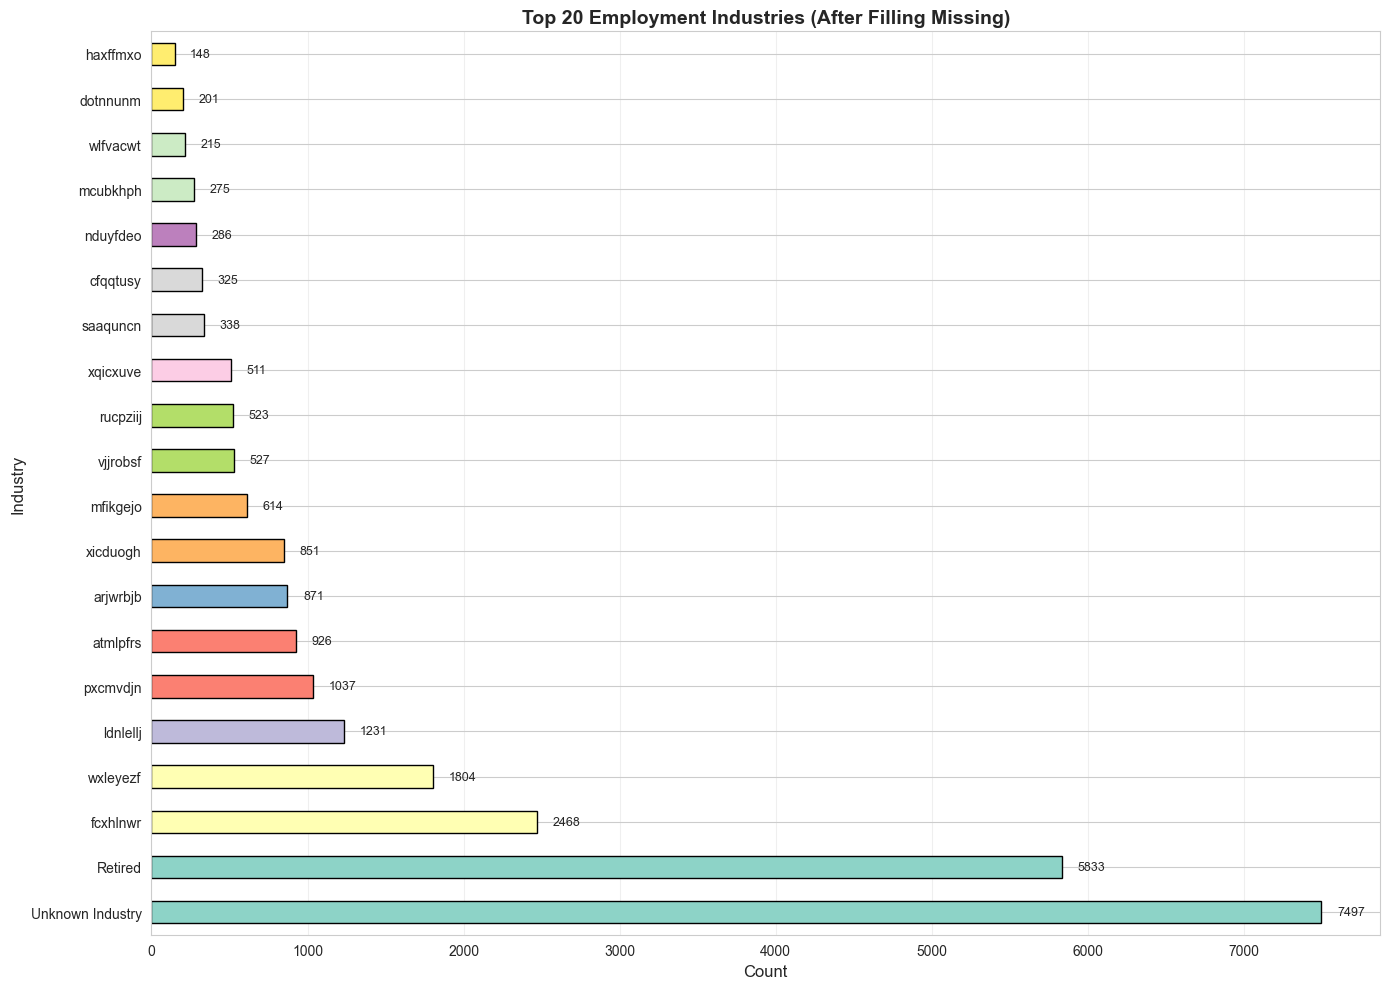

✅ Chart saved as 'EDA_plots/industry_by_occupation.png'


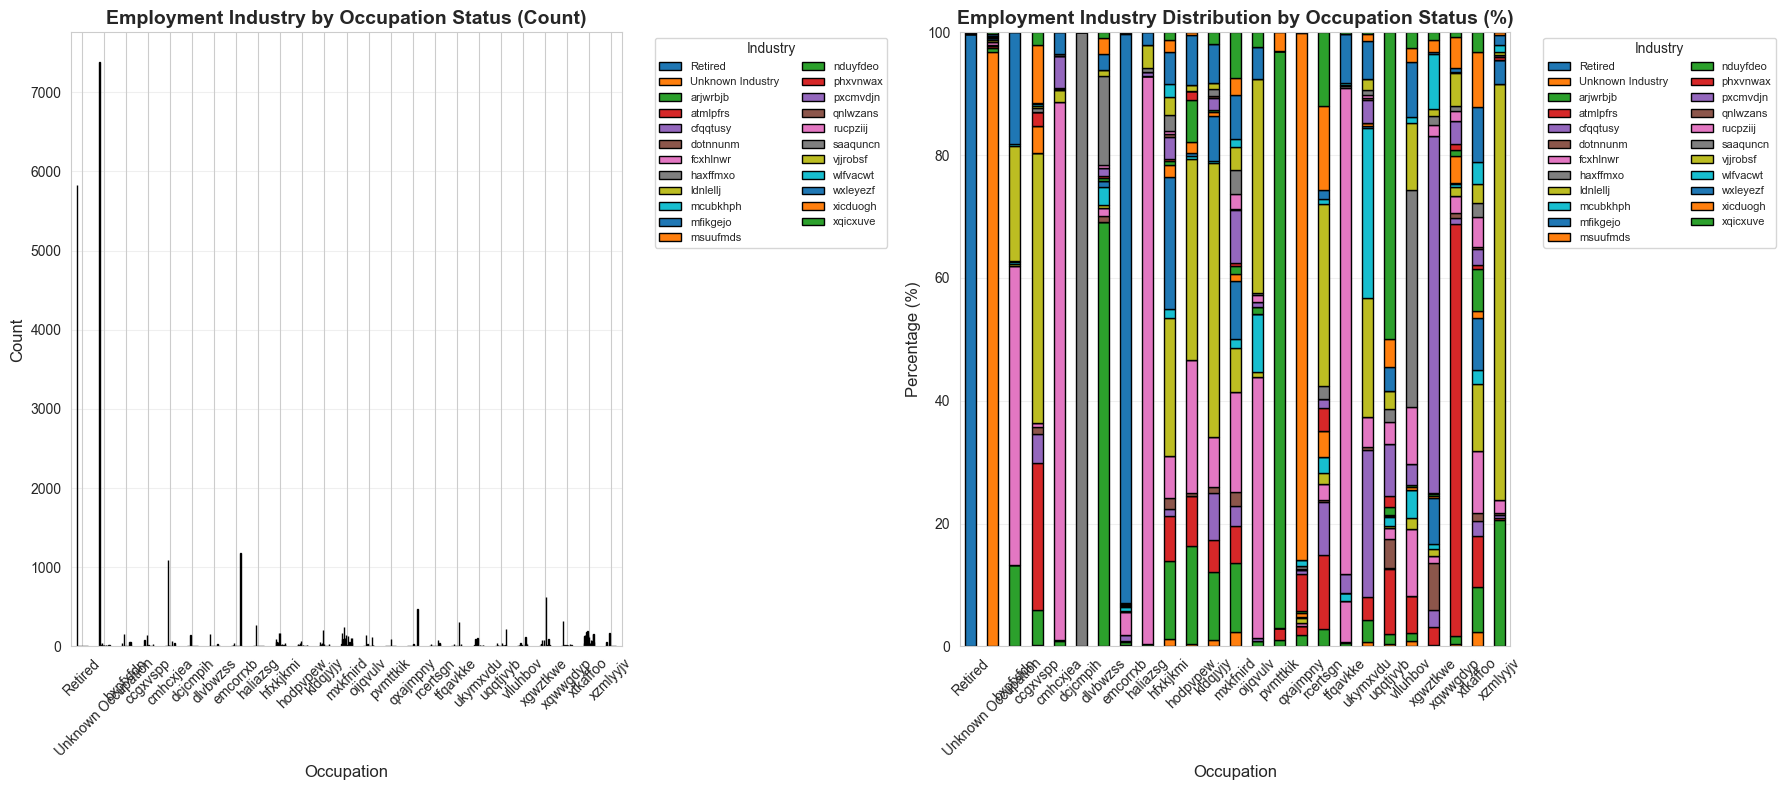

✅ Chart saved as 'EDA_plots/industry_by_age_group.png'


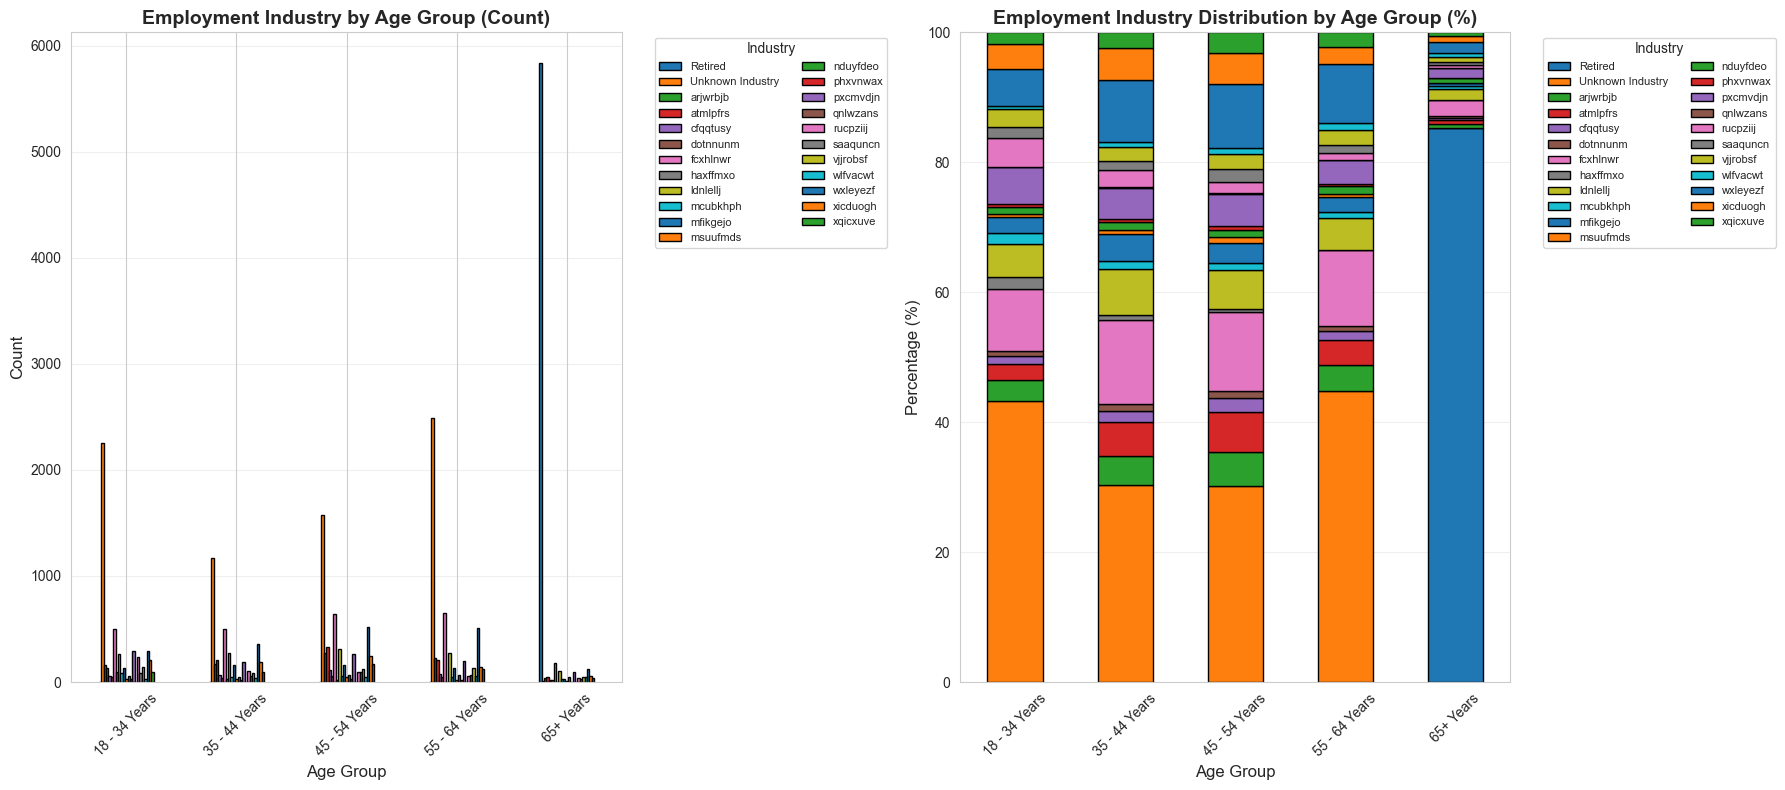

✅ Chart saved as 'EDA_plots/occupation_vs_industry_heatmap.png'


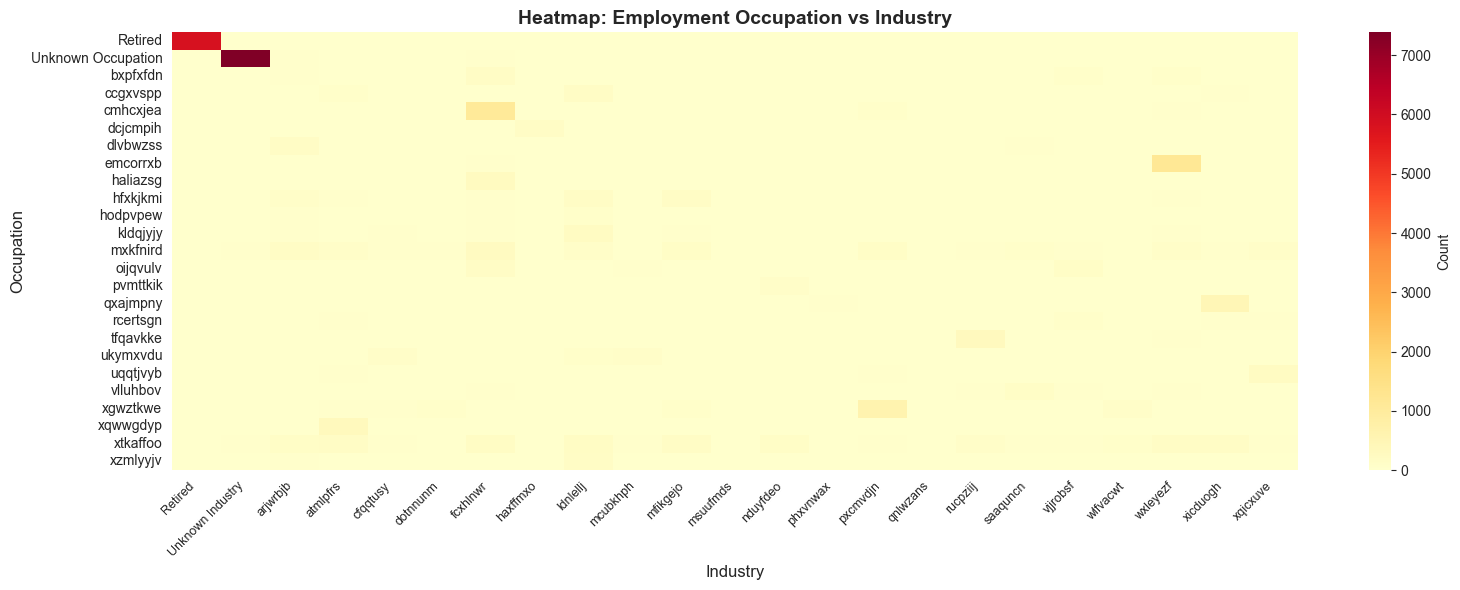

✅ Chart saved as 'EDA_plots/employment_status_vs_industry_heatmap.png'


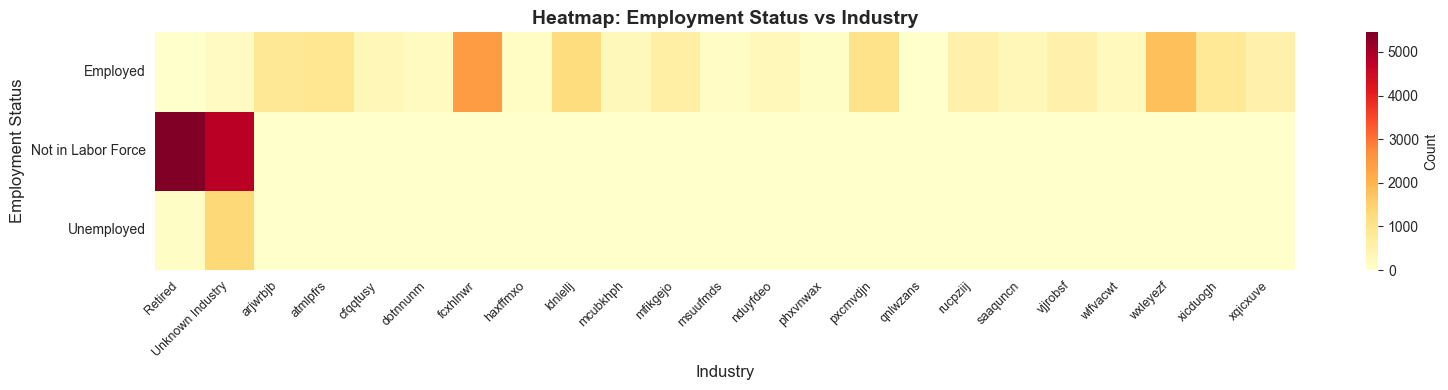


9. SUMMARY STATISTICS

Total Records: 26,707
Unique Industries: 23

Top 15 Industries:
        Industry  Count  Percentage
Unknown Industry   7497       28.07
         Retired   5833       21.84
        fcxhlnwr   2468        9.24
        wxleyezf   1804        6.75
        ldnlellj   1231        4.61
        pxcmvdjn   1037        3.88
        atmlpfrs    926        3.47
        arjwrbjb    871        3.26
        xicduogh    851        3.19
        mfikgejo    614        2.30
        vjjrobsf    527        1.97
        rucpziij    523        1.96
        xqicxuve    511        1.91
        saaquncn    338        1.27
        cfqqtusy    325        1.22

10. DETAILED BREAKDOWN BY OCCUPATION

UNKNOWN OCCUPATION:
  Total Records: 7,624
    1. Unknown Industry                              :  7,386 (96.88%)
    2. arjwrbjb                                      :     47 ( 0.62%)
    3. fcxhlnwr                                      :     47 ( 0.62%)
    4. atmlpfrs                          

In [104]:


# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)


# ============================================================
# 1. ANALYZE MISSING VALUES IN EMPLOYMENT INDUSTRY
# ============================================================
print("="*80)
print("1. EMPLOYMENT INDUSTRY - MISSING VALUES ANALYSIS")
print("="*80)

print(f"\nDataset Info:")
print(f"  Total Records: {len(merged_df):,}")

print(f"\nBEFORE FILLING:")
print(f"  Missing employment_industry: {merged_df['employment_industry'].isnull().sum():,}")
print(f"  Missing %: {merged_df['employment_industry'].isnull().sum() / len(merged_df) * 100:.2f}%")

# ============================================================
# 2. VALUE COUNTS - EMPLOYMENT INDUSTRY
# ============================================================
print("\n" + "="*80)
print("2. EMPLOYMENT INDUSTRY DISTRIBUTION (BEFORE FILLING)")
print("="*80)

industry_counts_before = merged_df['employment_industry'].value_counts(dropna=False)
print(f"\nTotal Unique Industries: {merged_df['employment_industry'].nunique()}")
print("\nTop 20 Industries:")
for idx, (ind, count) in enumerate(industry_counts_before.head(20).items(), 1):
    pct = (count / len(merged_df)) * 100
    print(f"  {idx:2d}. {str(ind):50s} : {count:6,} ({pct:5.2f}%)")

# ============================================================
# 3. ANALYZE MISSING PATTERN BY OCCUPATION
# ============================================================
print("\n" + "="*80)
print("3. MISSING INDUSTRY BY OCCUPATION STATUS")
print("="*80)

missing_by_occ = merged_df.groupby('employment_occupation')['employment_industry'].apply(
    lambda x: x.isnull().sum()
).sort_values(ascending=False)

print("\nMissing Industry Count by Occupation:")
for occ, missing_count in missing_by_occ.items():
    total = len(merged_df[merged_df['employment_occupation'] == occ])
    pct = (missing_count / total) * 100
    print(f"  {occ:40s} : {missing_count:6,} ({pct:6.2f}%)")

# ============================================================
# 4. SMART FILLING LOGIC
# ============================================================
print("\n" + "="*80)
print("4. APPLYING SMART FILLING LOGIC")
print("="*80)

# Create a copy to track original missing
merged_df['employment_industry_original'] = merged_df['employment_industry'].copy()

# Fill based on occupation status:
# If occupation is "Retired" → Fill industry with "Retired"
# If occupation is "Unknown Occupation" → Fill industry with "Unknown Industry"
# Otherwise → Fill with "Unknown Industry"

# Rule 1: If occupation is "Retired", fill industry with "Retired"
retired_mask = (merged_df['employment_occupation'] == 'Retired') & (merged_df['employment_industry'].isnull())
merged_df.loc[retired_mask, 'employment_industry'] = 'Retired'
retired_filled = retired_mask.sum()

# Rule 2: If occupation is "Unknown Occupation", fill industry with "Unknown Industry"
unknown_occ_mask = (merged_df['employment_occupation'] == 'Unknown Occupation') & (merged_df['employment_industry'].isnull())
merged_df.loc[unknown_occ_mask, 'employment_industry'] = 'Unknown Industry'
unknown_filled = unknown_occ_mask.sum()

# Rule 3: Any remaining missing → Fill with "Unknown Industry"
merged_df['employment_industry'] = merged_df['employment_industry'].fillna('Unknown Industry')
remaining_filled = merged_df['employment_industry_original'].isnull().sum() - retired_filled - unknown_filled

print(f"\nSmart Filling Applied:")
print(f"  ✅ Occupation = 'Retired' → Industry = 'Retired' : {retired_filled:,} records")
print(f"  ✅ Occupation = 'Unknown Occupation' → Industry = 'Unknown Industry' : {unknown_filled:,} records")
print(f"  ✅ Others → Industry = 'Unknown Industry' : {remaining_filled:,} records")
print(f"  ✅ Total Filled: {retired_filled + unknown_filled + remaining_filled:,} records")

# ============================================================
# 5. VERIFY FILLING
# ============================================================
print("\n" + "="*80)
print("5. VERIFICATION - AFTER FILLING")
print("="*80)

print(f"\nAFTER FILLING:")
print(f"  Missing employment_industry: {merged_df['employment_industry'].isnull().sum():,}")
print(f"  Missing %: {merged_df['employment_industry'].isnull().sum() / len(merged_df) * 100:.2f}%")

missing_check = merged_df['employment_industry'].isnull().sum()
if missing_check == 0:
    print(f"\n✅ SUCCESS! No missing values in employment_industry")
else:
    print(f"\n❌ WARNING! Still {missing_check} missing values")

# ============================================================
# 6. VALUE COUNTS - AFTER FILLING
# ============================================================
print("\n" + "="*80)
print("6. EMPLOYMENT INDUSTRY DISTRIBUTION (AFTER FILLING)")
print("="*80)

industry_counts_after = merged_df['employment_industry'].value_counts()
print(f"\nTotal Unique Industries: {merged_df['employment_industry'].nunique()}")
print("\nTop 20 Industries:")
for idx, (ind, count) in enumerate(industry_counts_after.head(20).items(), 1):
    pct = (count / len(merged_df)) * 100
    print(f"  {idx:2d}. {str(ind):50s} : {count:6,} ({pct:5.2f}%)")

# ============================================================
# 7. CROSS-TABULATION: OCCUPATION vs INDUSTRY
# ============================================================
print("\n" + "="*80)
print("7. CROSS-TABULATION: OCCUPATION vs INDUSTRY")
print("="*80)

crosstab_occ_ind = pd.crosstab(
    merged_df['employment_occupation'], 
    merged_df['employment_industry'],
    margins=True
)
print("\n" + crosstab_occ_ind.to_string())

# ============================================================
# 8. VISUALIZATION 1: TOP INDUSTRIES - HORIZONTAL BAR
# ============================================================
print("\n" + "="*80)
print("8. GENERATING VISUALIZATIONS...")
print("="*80)

fig, ax = plt.subplots(figsize=(14, 10))

top_industries = merged_df['employment_industry'].value_counts().head(20)
colors = plt.cm.Set3(np.linspace(0, 1, len(top_industries)))
top_industries.plot(kind='barh', ax=ax, color=colors, edgecolor='black')
ax.set_title('Top 20 Employment Industries (After Filling Missing)', fontsize=14, fontweight='bold')
ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('Industry', fontsize=12)
ax.grid(True, alpha=0.3, axis='x')

# Add count labels
for i, v in enumerate(top_industries.values):
    ax.text(v + 100, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('EDA_plots/top_industries.png', dpi=300, bbox_inches='tight')
print("✅ Chart saved as 'EDA_plots/top_industries.png'")
plt.show()

# ============================================================
# 9. VISUALIZATION 2: INDUSTRY BY OCCUPATION STATUS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Chart 1: Count of Industry by Occupation
industry_by_occ = pd.crosstab(merged_df['employment_occupation'], merged_df['employment_industry'])
industry_by_occ.plot(kind='bar', ax=axes[0], edgecolor='black', stacked=False)
axes[0].set_title('Employment Industry by Occupation Status (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Occupation', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].legend(title='Industry', fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# Chart 2: Percentage Distribution
industry_by_occ_pct = pd.crosstab(merged_df['employment_occupation'], merged_df['employment_industry'], normalize='index') * 100
industry_by_occ_pct.plot(kind='bar', ax=axes[1], stacked=True, edgecolor='black')
axes[1].set_title('Employment Industry Distribution by Occupation Status (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Occupation', fontsize=12)
axes[1].set_ylabel('Percentage (%)', fontsize=12)
axes[1].legend(title='Industry', fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylim([0, 100])
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('EDA_plots/industry_by_occupation.png', dpi=300, bbox_inches='tight')
print("✅ Chart saved as 'EDA_plots/industry_by_occupation.png'")
plt.show()

# ============================================================
# 10. VISUALIZATION 3: INDUSTRY BY AGE GROUP
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Chart 1: Count of Industry by Age Group
industry_by_age = pd.crosstab(merged_df['age_group'], merged_df['employment_industry'])
industry_by_age.plot(kind='bar', ax=axes[0], edgecolor='black', stacked=False)
axes[0].set_title('Employment Industry by Age Group (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age Group', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].legend(title='Industry', fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# Chart 2: Percentage Distribution
industry_by_age_pct = pd.crosstab(merged_df['age_group'], merged_df['employment_industry'], normalize='index') * 100
industry_by_age_pct.plot(kind='bar', ax=axes[1], stacked=True, edgecolor='black')
axes[1].set_title('Employment Industry Distribution by Age Group (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Age Group', fontsize=12)
axes[1].set_ylabel('Percentage (%)', fontsize=12)
axes[1].legend(title='Industry', fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylim([0, 100])
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('EDA_plots/industry_by_age_group.png', dpi=300, bbox_inches='tight')
print("✅ Chart saved as 'EDA_plots/industry_by_age_group.png'")
plt.show()

# ============================================================
# 11. VISUALIZATION 4: HEATMAP - OCCUPATION vs INDUSTRY
# ============================================================

fig, ax = plt.subplots(figsize=(16, 6))

crosstab_heat = pd.crosstab(merged_df['employment_occupation'], merged_df['employment_industry'])
sns.heatmap(crosstab_heat, annot=False, cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Count'})
ax.set_title('Heatmap: Employment Occupation vs Industry', fontsize=14, fontweight='bold')
ax.set_xlabel('Industry', fontsize=12)
ax.set_ylabel('Occupation', fontsize=12)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig('EDA_plots/occupation_vs_industry_heatmap.png', dpi=300, bbox_inches='tight')
print("✅ Chart saved as 'EDA_plots/occupation_vs_industry_heatmap.png'")
plt.show()

# ============================================================
# 12. VISUALIZATION 5: HEATMAP - EMPLOYMENT STATUS vs INDUSTRY
# ============================================================

fig, ax = plt.subplots(figsize=(16, 4))

crosstab_status = pd.crosstab(merged_df['employment_status'], merged_df['employment_industry'])
sns.heatmap(crosstab_status, annot=False, cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Count'})
ax.set_title('Heatmap: Employment Status vs Industry', fontsize=14, fontweight='bold')
ax.set_xlabel('Industry', fontsize=12)
ax.set_ylabel('Employment Status', fontsize=12)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig('EDA_plots/employment_status_vs_industry_heatmap.png', dpi=300, bbox_inches='tight')
print("✅ Chart saved as 'EDA_plots/employment_status_vs_industry_heatmap.png'")
plt.show()

# ============================================================
# 13. SUMMARY STATISTICS
# ============================================================
print("\n" + "="*80)
print("9. SUMMARY STATISTICS")
print("="*80)

summary_stats = pd.DataFrame({
    'Industry': merged_df['employment_industry'].unique(),
    'Count': [len(merged_df[merged_df['employment_industry'] == ind]) for ind in merged_df['employment_industry'].unique()],
})
summary_stats['Percentage'] = (summary_stats['Count'] / len(merged_df) * 100).round(2)
summary_stats = summary_stats.sort_values('Count', ascending=False)

print(f"\nTotal Records: {len(merged_df):,}")
print(f"Unique Industries: {merged_df['employment_industry'].nunique()}")
print("\nTop 15 Industries:")
print(summary_stats.head(15).to_string(index=False))

# ============================================================
# 14. DETAILED BREAKDOWN
# ============================================================
print("\n" + "="*80)
print("10. DETAILED BREAKDOWN BY OCCUPATION")
print("="*80)

for occ in merged_df['employment_occupation'].unique():
    occ_data = merged_df[merged_df['employment_occupation'] == occ]
    print(f"\n{occ.upper()}:")
    print(f"  Total Records: {len(occ_data):,}")
    
    ind_dist = occ_data['employment_industry'].value_counts().head(5)
    for idx, (ind, count) in enumerate(ind_dist.items(), 1):
        pct = (count / len(occ_data)) * 100
        print(f"    {idx}. {ind:45s} : {count:6,} ({pct:5.2f}%)")

# ============================================================
# 15. CROSS-TABULATION: AGE GROUP vs INDUSTRY
# ============================================================
print("\n" + "="*80)
print("11. INDUSTRY DISTRIBUTION BY AGE GROUP")
print("="*80)

crosstab_age_ind = pd.crosstab(
    merged_df['age_group'], 
    merged_df['employment_industry'],
    margins=True
)
print("\n" + crosstab_age_ind.to_string())

# ============================================================
# 16. COMPARISON: BEFORE vs AFTER
# ============================================================
print("\n" + "="*80)
print("12. COMPARISON: BEFORE vs AFTER SMART FILL")
print("="*80)

print(f"""
BEFORE FILLING:
  • Missing Values: {merged_df['employment_industry_original'].isnull().sum():,}
  • Unique Industries: {merged_df['employment_industry_original'].nunique()}

AFTER SMART FILL:
  • Missing Values: {merged_df['employment_industry'].isnull().sum():,}
  • Unique Industries: {merged_df['employment_industry'].nunique()}

SMART FILL STRATEGY:
  ✅ Occupation = 'Retired' → Industry = 'Retired' : {retired_filled:,}
  ✅ Occupation = 'Unknown Occupation' → Industry = 'Unknown Industry' : {unknown_filled:,}
  ✅ Others → Industry = 'Unknown Industry' : {remaining_filled:,}
  ✅ TOTAL FILLED: {retired_filled + unknown_filled + remaining_filled:,}

KEY STATISTICS:
  • "Retired" Industry: {(merged_df['employment_industry'] == 'Retired').sum():,} ({(merged_df['employment_industry'] == 'Retired').sum()/len(merged_df)*100:.2f}%)
  • "Unknown Industry": {(merged_df['employment_industry'] == 'Unknown Industry').sum():,} ({(merged_df['employment_industry'] == 'Unknown Industry').sum()/len(merged_df)*100:.2f}%)
  • Other Industries: {len(merged_df[~merged_df['employment_industry'].isin(['Retired', 'Unknown Industry'])]):,}
""")

# ============================================================
# 17. FINAL REPORT
# ============================================================
print("\n" + "="*80)
print("13. FINAL REPORT")
print("="*80)

print(f"""
SMART EMPLOYMENT INDUSTRY FILLING COMPLETED:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

✅ All missing industry values filled with smart logic

Data Quality:
  • Total Records: {len(merged_df):,}
  • Unique Industries: {merged_df['employment_industry'].nunique()}
  • Missing Values: {merged_df['employment_industry'].isnull().sum()} (0.00%)
  • "Retired" Industry: {(merged_df['employment_industry'] == 'Retired').sum():,}
  • "Unknown Industry": {(merged_df['employment_industry'] == 'Unknown Industry').sum():,}

Smart Fill Logic Applied:
  1. ✅ IF employment_occupation == 'Retired' AND industry is missing
     → Fill with "Retired"
  2. ✅ IF employment_occupation == 'Unknown Occupation' AND industry is missing
     → Fill with "Unknown Industry"
  3. ✅ All remaining missing values → Fill with "Unknown Industry"

Advantages of Smart Fill:
  • Maintains consistency with occupation mapping
  • "Retired" individuals map to "Retired" industry
  • "Unknown Occupation" maps to "Unknown Industry"
  • Better data quality and interpretability
  • Helps model understand employment patterns

Files Generated:
  ✅ EDA_plots/top_industries.png
  ✅ EDA_plots/industry_by_occupation.png
  ✅ EDA_plots/industry_by_age_group.png
  ✅ EDA_plots/occupation_vs_industry_heatmap.png
  ✅ EDA_plots/employment_status_vs_industry_heatmap.png

Next Steps:
  1. ✅ Use employment_industry in analysis/modeling
  2. ✅ Both "Retired" and "Unknown Industry" are valid categories
  3. ⚠️ Document the smart fill logic in your report
  4. 📊 Can now perform EDA on industry variable
  5. 🔄 Ready for categorical encoding for machine learning
  6. 📈 Analyze relationship between occupation and industry
""")

print("=" * 80)

# Cleanup
merged_df = merged_df.drop(columns=['employment_industry_original'])
print("\n✅ Cleanup: Removed temporary tracking column")
print("=" * 80)

In [105]:
merged_df.isna().sum()

respondent_id                        0
h1n1_concern                        92
h1n1_knowledge                     116
behavioral_antiviral_meds           71
behavioral_avoidance               208
behavioral_face_mask                19
behavioral_wash_hands               42
behavioral_large_gatherings         87
behavioral_outside_home             82
behavioral_touch_face              128
doctor_recc_h1n1                  2160
doctor_recc_seasonal              2160
chronic_med_condition              971
child_under_6_months               820
health_worker                      804
health_insurance                 12274
opinion_h1n1_vacc_effective        391
opinion_h1n1_risk                  388
opinion_h1n1_sick_from_vacc        395
opinion_seas_vacc_effective        462
opinion_seas_risk                  514
opinion_seas_sick_from_vacc        537
age_group                            0
education                         1407
race                                 0
sex                      

In [106]:
# Check if missingness correlates with other variables
for col in ['income_poverty', 'employment_status', 'age_group', 'health_worker']:
    missing_rate = merged_df[merged_df['health_insurance'].isna()][col].value_counts(normalize=True)
    print(f"\n{col} distribution where health_insurance is MISSING:")
    print(missing_rate)


income_poverty distribution where health_insurance is MISSING:
income_poverty
<= $75,000, Above Poverty    0.57256
> $75,000                    0.31151
Below Poverty                0.11593
Name: proportion, dtype: float64

employment_status distribution where health_insurance is MISSING:
employment_status
Employed              0.545771
Not in Labor Force    0.400037
Unemployed            0.054193
Name: proportion, dtype: float64

age_group distribution where health_insurance is MISSING:
age_group
65+ Years        0.246374
55 - 64 Years    0.202460
45 - 54 Years    0.198387
18 - 34 Years    0.197817
35 - 44 Years    0.154962
Name: proportion, dtype: float64

health_worker distribution where health_insurance is MISSING:
health_worker
0.0    0.887195
1.0    0.112805
Name: proportion, dtype: float64


In [107]:
merged_df.columns
merged_df = merged_df.drop(columns=['employment_occupation_missing'])
merged_df.columns

Index(['respondent_id', 'h1n1_concern', 'h1n1_knowledge',
       'behavioral_antiviral_meds', 'behavioral_avoidance',
       'behavioral_face_mask', 'behavioral_wash_hands',
       'behavioral_large_gatherings', 'behavioral_outside_home',
       'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal',
       'chronic_med_condition', 'child_under_6_months', 'health_worker',
       'health_insurance', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk',
       'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effective',
       'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'age_group',
       'education', 'race', 'sex', 'income_poverty', 'marital_status',
       'rent_or_own', 'employment_status', 'hhs_geo_region', 'census_msa',
       'household_adults', 'household_children', 'employment_industry',
       'employment_occupation', 'h1n1_vaccine', 'seasonal_vaccine'],
      dtype='str')

STEP 1: RAW DATA EXPLORATION

📊 Dataset Shape: (26707, 38)
   Rows: 26,707
   Columns: 38

🔍 Missing Values in Raw Data:
                     Column  Missing_Count  Missing_Percent
           health_insurance          12274        45.957989
             income_poverty           4423        16.561201
           doctor_recc_h1n1           2160         8.087767
       doctor_recc_seasonal           2160         8.087767
                rent_or_own           2042         7.645936
          employment_status           1463         5.477965
             marital_status           1408         5.272026
                  education           1407         5.268282
      chronic_med_condition            971         3.635751
       child_under_6_months            820         3.070356
              health_worker            804         3.010447
opinion_seas_sick_from_vacc            537         2.010709
          opinion_seas_risk            514         1.924589
opinion_seas_vacc_effective            

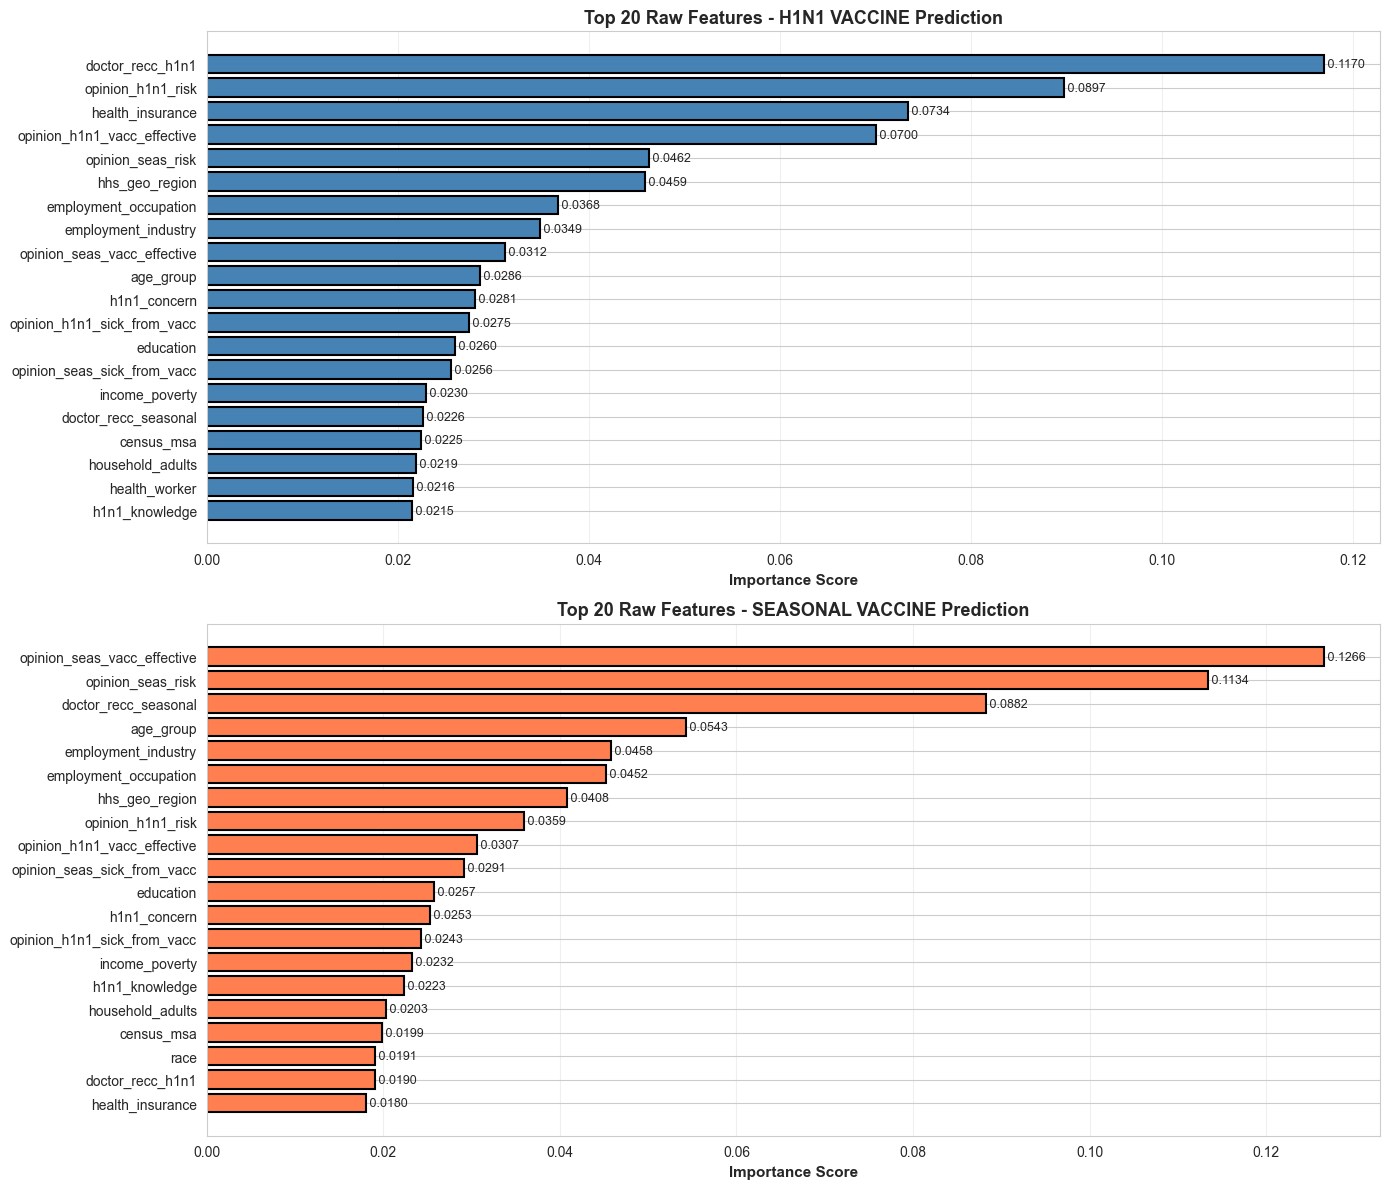


✅ Saved: EDA_plots/01_raw_features_importance_individual.png


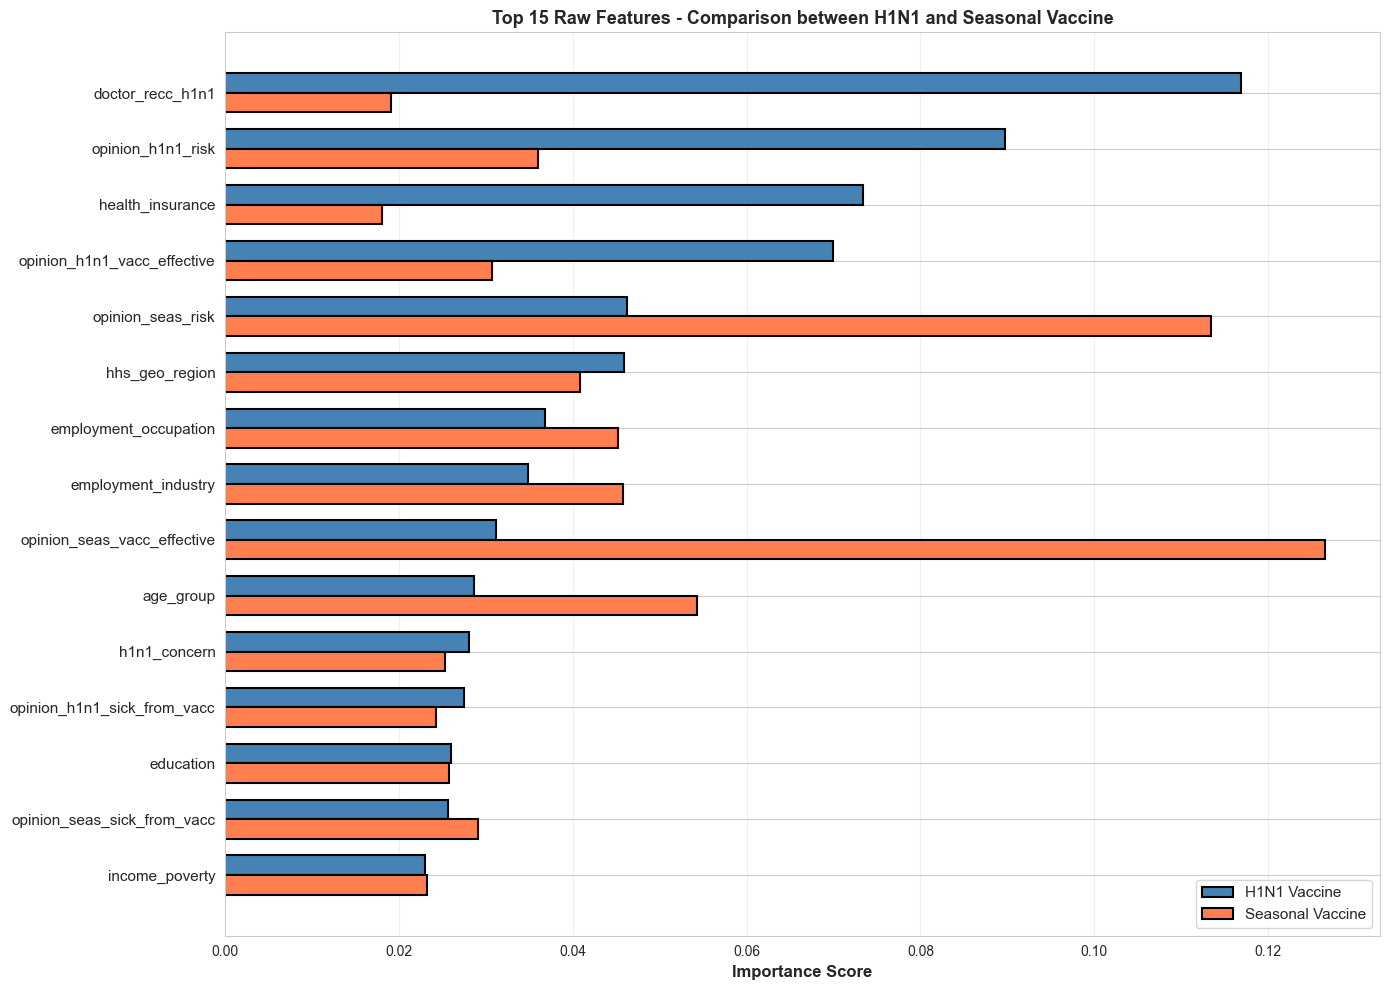

✅ Saved: EDA_plots/02_raw_features_importance_comparison.png


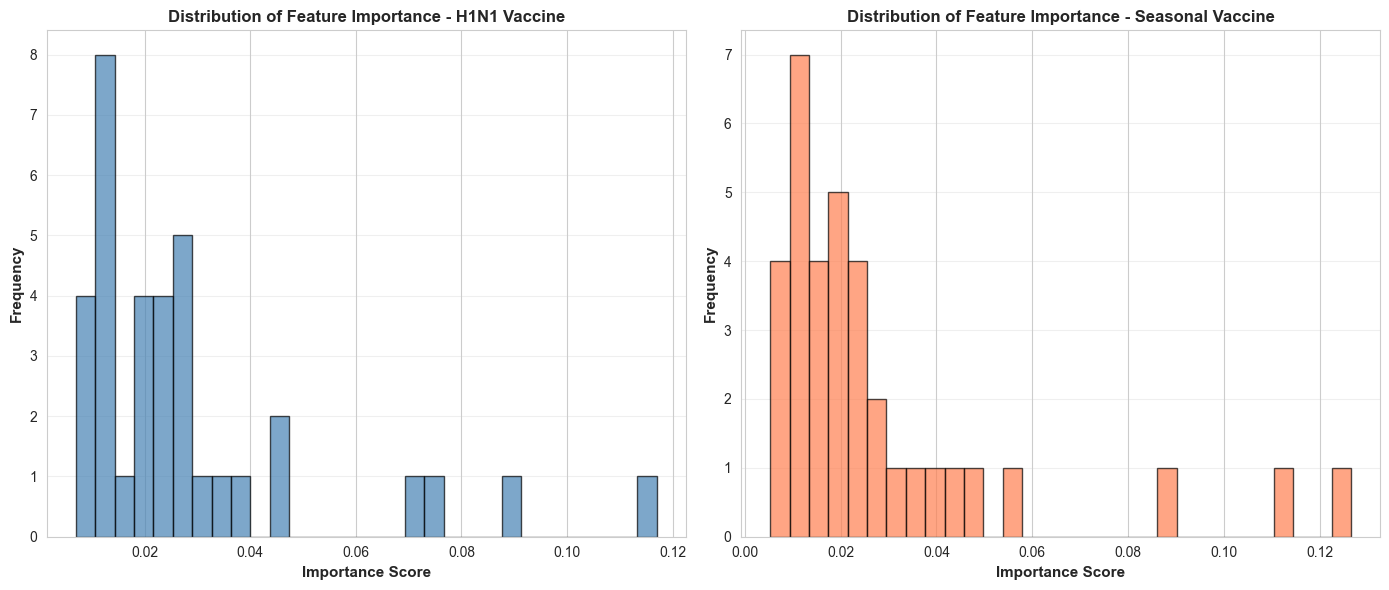

✅ Saved: EDA_plots/03_raw_features_importance_distribution.png


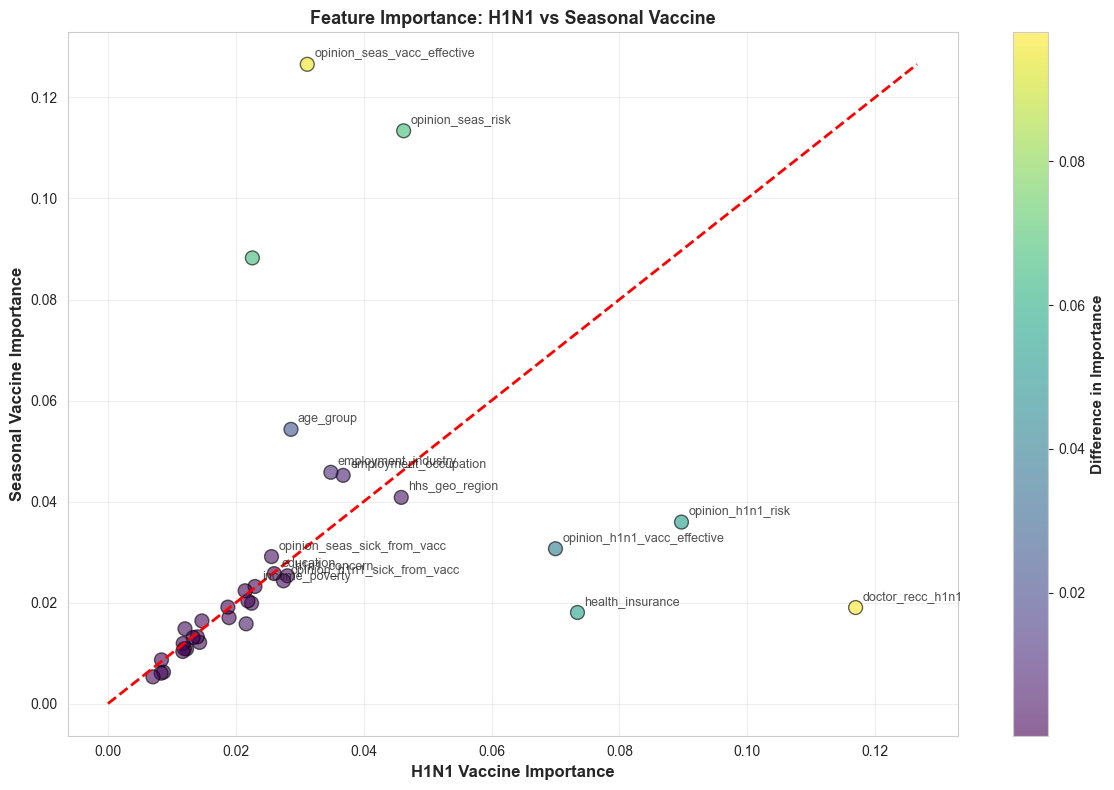

✅ Saved: EDA_plots/04_raw_features_importance_scatter.png

STEP 8: SUMMARY STATISTICS

📊 H1N1 VACCINE - Importance Statistics:
   Mean Importance: 0.028571
   Std Importance:  0.024470
   Max Importance:  0.116951
   Min Importance:  0.007032

📊 SEASONAL VACCINE - Importance Statistics:
   Mean Importance: 0.028571
   Std Importance:  0.028130
   Max Importance:  0.126563
   Min Importance:  0.005305

🎯 TOP 10 IMPORTANT FEATURES - H1N1:
   doctor_recc_h1n1: 0.116951
   opinion_h1n1_risk: 0.089714
   health_insurance: 0.073444
   opinion_h1n1_vacc_effective: 0.069998
   opinion_seas_risk: 0.046250
   hhs_geo_region: 0.045877
   employment_occupation: 0.036793
   employment_industry: 0.034867
   opinion_seas_vacc_effective: 0.031177
   age_group: 0.028627

🎯 TOP 10 IMPORTANT FEATURES - SEASONAL:
   opinion_seas_vacc_effective: 0.126563
   opinion_seas_risk: 0.113400
   doctor_recc_seasonal: 0.088237
   age_group: 0.054297
   employment_industry: 0.045797
   employment_occupation: 0.04519

In [108]:


eda_df = merged_df.copy()
# ============================================================================
# STEP 1: LOAD AND EXPLORE RAW DATA
# ============================================================================

print("=" * 80)
print("STEP 1: RAW DATA EXPLORATION")
print("=" * 80)

print(f"\n📊 Dataset Shape: {eda_df.shape}")
print(f"   Rows: {eda_df.shape[0]:,}")
print(f"   Columns: {eda_df.shape[1]}")

# Check missing values
print(f"\n🔍 Missing Values in Raw Data:")
missing_summary = eda_df.isna().sum()
missing_percent = (missing_summary / len(eda_df)) * 100
missing_df = pd.DataFrame({
    'Column': missing_summary.index,
    'Missing_Count': missing_summary.values,
    'Missing_Percent': missing_percent.values
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

print(missing_df.to_string(index=False))

# Identify target and features
target_cols = ['h1n1_vaccine', 'seasonal_vaccine']
feature_cols = [col for col in eda_df.columns if col not in target_cols + ['respondent_id']]

print(f"\n📋 Dataset Info:")
print(f"   Total Features: {len(feature_cols)}")
print(f"   Target Variables: {len(target_cols)}")

# Data types
print(f"\n📊 Data Types:")
print(eda_df[feature_cols].dtypes.value_counts())

# ============================================================================
# STEP 2: PREPARE DATA - REPLACE NaN WITH 0
# ============================================================================

print("\n" + "=" * 80)
print("STEP 2: PREPARE DATA - REPLACE NaN WITH 0")
print("=" * 80)

df_prepared = eda_df.copy()

# Replace NaN with 0
print(f"\n🔧 Replacing NaN with 0...")
df_prepared[feature_cols] = df_prepared[feature_cols].fillna(0)

print(f"✅ Missing values after filling: {df_prepared[feature_cols].isna().sum().sum()}")

# ============================================================================
# STEP 3: ENCODE CATEGORICAL FEATURES
# ============================================================================

print("\n" + "=" * 80)
print("STEP 3: ENCODE CATEGORICAL FEATURES")
print("=" * 80)

df_encoded = df_prepared.copy()

# Get categorical columns
categorical_cols = df_encoded[feature_cols].select_dtypes(include=['object']).columns.tolist()
print(f"\n🔤 Found {len(categorical_cols)} categorical columns:")
for i, col in enumerate(categorical_cols, 1):
    unique_count = df_encoded[col].nunique()
    print(f"   {i}. {col} ({unique_count} unique values)")

# Encode categorical columns
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    le_dict[col] = le

print(f"\n✅ Encoded all {len(categorical_cols)} categorical columns")

# ============================================================================
# STEP 4: CALCULATE FEATURE IMPORTANCE FOR H1N1_VACCINE
# ============================================================================

print("\n" + "=" * 80)
print("STEP 4: FEATURE IMPORTANCE - H1N1 VACCINE TARGET")
print("=" * 80)

# Prepare data for H1N1
X_h1n1 = df_encoded[feature_cols].copy()
y_h1n1 = eda_df['h1n1_vaccine'].copy()

# Remove rows where target is missing
valid_idx_h1n1 = y_h1n1.notna()
X_h1n1 = X_h1n1[valid_idx_h1n1]
y_h1n1 = y_h1n1[valid_idx_h1n1]

print(f"\n📊 Data Available for H1N1:")
print(f"   Total Samples: {len(X_h1n1):,}")
print(f"   Target Value Counts:")
print(y_h1n1.value_counts())

# Train RandomForest for importance
print(f"\n🤖 Training RandomForest for H1N1 feature importance...")
rf_h1n1 = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=15,
    n_jobs=-1
)

rf_h1n1.fit(X_h1n1, y_h1n1)
print(f"✅ Model trained!")

# Get feature importance
feature_importance_h1n1 = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_h1n1.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\n📈 Top 25 Important Features for H1N1 Vaccine:")
print(feature_importance_h1n1.head(25).to_string(index=False))

# ============================================================================
# STEP 5: CALCULATE FEATURE IMPORTANCE FOR SEASONAL_VACCINE
# ============================================================================

print("\n" + "=" * 80)
print("STEP 5: FEATURE IMPORTANCE - SEASONAL VACCINE TARGET")
print("=" * 80)

# Prepare data for Seasonal
X_seasonal = df_encoded[feature_cols].copy()
y_seasonal = eda_df['seasonal_vaccine'].copy()

# Remove rows where target is missing
valid_idx_seasonal = y_seasonal.notna()
X_seasonal = X_seasonal[valid_idx_seasonal]
y_seasonal = y_seasonal[valid_idx_seasonal]

print(f"\n📊 Data Available for Seasonal Vaccine:")
print(f"   Total Samples: {len(X_seasonal):,}")
print(f"   Target Value Counts:")
print(y_seasonal.value_counts())

# Train RandomForest for importance
print(f"\n🤖 Training RandomForest for Seasonal feature importance...")
rf_seasonal = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=15,
    n_jobs=-1
)

rf_seasonal.fit(X_seasonal, y_seasonal)
print(f"✅ Model trained!")

# Get feature importance
feature_importance_seasonal = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_seasonal.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\n📈 Top 25 Important Features for Seasonal Vaccine:")
print(feature_importance_seasonal.head(25).to_string(index=False))

# ============================================================================
# STEP 6: COMPARE IMPORTANCE - BOTH TARGETS
# ============================================================================

print("\n" + "=" * 80)
print("STEP 6: FEATURE IMPORTANCE COMPARISON")
print("=" * 80)

comparison_df = pd.DataFrame({
    'Feature': feature_importance_h1n1['Feature'],
    'H1N1_Importance': feature_importance_h1n1['Importance'].values,
    'Seasonal_Importance': feature_importance_seasonal.set_index('Feature').loc[feature_importance_h1n1['Feature'], 'Importance'].values
})

comparison_df['Difference'] = abs(comparison_df['H1N1_Importance'] - comparison_df['Seasonal_Importance'])
comparison_df = comparison_df.sort_values('H1N1_Importance', ascending=False)

print(f"\n📊 Top 20 Features - Side by Side Comparison:")
print(comparison_df.head(20)[['Feature', 'H1N1_Importance', 'Seasonal_Importance', 'Difference']].to_string(index=False))

# ============================================================================
# STEP 7: VISUALIZATIONS
# ============================================================================

print("\n" + "=" * 80)
print("STEP 7: CREATING VISUALIZATIONS")
print("=" * 80)

# Figure 1: Individual importance plots
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# H1N1 importance
top_20_h1n1 = feature_importance_h1n1.head(20)
axes[0].barh(range(len(top_20_h1n1)), top_20_h1n1['Importance'], color='steelblue', edgecolor='black', linewidth=1.5)
axes[0].set_yticks(range(len(top_20_h1n1)))
axes[0].set_yticklabels(top_20_h1n1['Feature'], fontsize=10)
axes[0].set_xlabel('Importance Score', fontsize=11, fontweight='bold')
axes[0].set_title('Top 20 Raw Features - H1N1 VACCINE Prediction', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Add values on bars
for i, v in enumerate(top_20_h1n1['Importance']):
    axes[0].text(v, i, f' {v:.4f}', va='center', fontsize=9)

# Seasonal importance
top_20_seasonal = feature_importance_seasonal.head(20)
axes[1].barh(range(len(top_20_seasonal)), top_20_seasonal['Importance'], color='coral', edgecolor='black', linewidth=1.5)
axes[1].set_yticks(range(len(top_20_seasonal)))
axes[1].set_yticklabels(top_20_seasonal['Feature'], fontsize=10)
axes[1].set_xlabel('Importance Score', fontsize=11, fontweight='bold')
axes[1].set_title('Top 20 Raw Features - SEASONAL VACCINE Prediction', fontsize=13, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

# Add values on bars
for i, v in enumerate(top_20_seasonal['Importance']):
    axes[1].text(v, i, f' {v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('EDA_plots/01_raw_features_importance_individual.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✅ Saved: EDA_plots/01_raw_features_importance_individual.png")

# ============================================================================
# Figure 2: Side-by-side comparison
# ============================================================================

fig, ax = plt.subplots(figsize=(14, 10))

top_15_features = comparison_df.head(15)
x = np.arange(len(top_15_features))
width = 0.35

bars1 = ax.barh(x - width/2, top_15_features['H1N1_Importance'], width, label='H1N1 Vaccine', color='steelblue', edgecolor='black', linewidth=1.5)
bars2 = ax.barh(x + width/2, top_15_features['Seasonal_Importance'], width, label='Seasonal Vaccine', color='coral', edgecolor='black', linewidth=1.5)

ax.set_yticks(x)
ax.set_yticklabels(top_15_features['Feature'], fontsize=11)
ax.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
ax.set_title('Top 15 Raw Features - Comparison between H1N1 and Seasonal Vaccine', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('EDA_plots/02_raw_features_importance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: EDA_plots/02_raw_features_importance_comparison.png")

# ============================================================================
# Figure 3: Distribution of importance scores
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# H1N1 distribution
axes[0].hist(feature_importance_h1n1['Importance'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Importance Score', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0].set_title('Distribution of Feature Importance - H1N1 Vaccine', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Seasonal distribution
axes[1].hist(feature_importance_seasonal['Importance'], bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Importance Score', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[1].set_title('Distribution of Feature Importance - Seasonal Vaccine', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('EDA_plots/03_raw_features_importance_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: EDA_plots/03_raw_features_importance_distribution.png")

# ============================================================================
# Figure 4: Scatter plot - H1N1 vs Seasonal
# ============================================================================

fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(
    comparison_df['H1N1_Importance'],
    comparison_df['Seasonal_Importance'],
    s=100,
    alpha=0.6,
    c=comparison_df['Difference'],
    cmap='viridis',
    edgecolor='black',
    linewidth=1
)

# Add diagonal line (equal importance)
max_importance = max(comparison_df['H1N1_Importance'].max(), comparison_df['Seasonal_Importance'].max())
ax.plot([0, max_importance], [0, max_importance], 'r--', label='Equal Importance', linewidth=2)

# Label top features
for idx, row in comparison_df.head(15).iterrows():
    ax.annotate(row['Feature'], 
                (row['H1N1_Importance'], row['Seasonal_Importance']),
                fontsize=9,
                xytext=(5, 5),
                textcoords='offset points',
                alpha=0.8)

ax.set_xlabel('H1N1 Vaccine Importance', fontsize=12, fontweight='bold')
ax.set_ylabel('Seasonal Vaccine Importance', fontsize=12, fontweight='bold')
ax.set_title('Feature Importance: H1N1 vs Seasonal Vaccine', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Difference in Importance', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('EDA_plots/04_raw_features_importance_scatter.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: EDA_plots/04_raw_features_importance_scatter.png")

# ============================================================================
# STEP 8: SUMMARY STATISTICS
# ============================================================================

print("\n" + "=" * 80)
print("STEP 8: SUMMARY STATISTICS")
print("=" * 80)

print(f"\n📊 H1N1 VACCINE - Importance Statistics:")
print(f"   Mean Importance: {feature_importance_h1n1['Importance'].mean():.6f}")
print(f"   Std Importance:  {feature_importance_h1n1['Importance'].std():.6f}")
print(f"   Max Importance:  {feature_importance_h1n1['Importance'].max():.6f}")
print(f"   Min Importance:  {feature_importance_h1n1['Importance'].min():.6f}")

print(f"\n📊 SEASONAL VACCINE - Importance Statistics:")
print(f"   Mean Importance: {feature_importance_seasonal['Importance'].mean():.6f}")
print(f"   Std Importance:  {feature_importance_seasonal['Importance'].std():.6f}")
print(f"   Max Importance:  {feature_importance_seasonal['Importance'].max():.6f}")
print(f"   Min Importance:  {feature_importance_seasonal['Importance'].min():.6f}")

# Features that matter for both
both_important = comparison_df.nlargest(10, 'H1N1_Importance')
both_important_seasonal = comparison_df.nlargest(10, 'Seasonal_Importance')

print(f"\n🎯 TOP 10 IMPORTANT FEATURES - H1N1:")
for i, row in both_important.iterrows():
    print(f"   {row['Feature']}: {row['H1N1_Importance']:.6f}")

print(f"\n🎯 TOP 10 IMPORTANT FEATURES - SEASONAL:")
for i, row in both_important_seasonal.iterrows():
    print(f"   {row['Feature']}: {row['Seasonal_Importance']:.6f}")

# Features that differ most between targets
print(f"\n⚠️  FEATURES WITH HIGHEST DIFFERENCE IN IMPORTANCE:")
diff_features = comparison_df.nlargest(10, 'Difference')
for i, row in diff_features.iterrows():
    print(f"   {row['Feature']}: H1N1={row['H1N1_Importance']:.6f}, Seasonal={row['Seasonal_Importance']:.6f}, Diff={row['Difference']:.6f}")

# ============================================================================
# STEP 9: SAVE RESULTS
# ============================================================================

print("\n" + "=" * 80)
print("STEP 9: SAVE RESULTS")
print("=" * 80)

# Save feature importance to CSV
feature_importance_h1n1.to_csv('EDA_plots/feature_importance_h1n1_raw.csv', index=False)
feature_importance_seasonal.to_csv('EDA_plots/feature_importance_seasonal_raw.csv', index=False)
comparison_df.to_csv('EDA_plots/feature_importance_comparison_raw.csv', index=False)

print(f"\n💾 Saved feature importance files:")
print(f"   • EDA_plots/feature_importance_h1n1_raw.csv")
print(f"   • EDA_plots/feature_importance_seasonal_raw.csv")
print(f"   • EDA_plots/feature_importance_comparison_raw.csv")

# ============================================================================
# STEP 10: CREATE SUMMARY REPORT
# ============================================================================

print("\n" + "=" * 80)
print("STEP 10: SUMMARY REPORT")
print("=" * 80)

summary_report = f"""
╔═══════════════════════════════════════════════════════════════════════════╗
║           RAW FEATURE IMPORTANCE ANALYSIS (NaN → 0) REPORT                ║
╚═══════════════════════════════════════════════════════════════════════════╝

📊 DATASET INFORMATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Initial Data:
  • Total Rows: {len(eda_df):,}
  • Total Columns: {eda_df.shape[1]}
  • Total Features: {len(feature_cols)}
  • Target Variables: {len(target_cols)}

After NaN → 0 Replacement:
  • Missing Values Remaining: {df_prepared[feature_cols].isna().sum().sum()}
  • Categorical Features: {len(categorical_cols)}
  • Numerical Features: {len(feature_cols) - len(categorical_cols)}

🎯 H1N1 VACCINE TARGET
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Data Available:
  • Samples with target: {len(X_h1n1):,}
  • Class Distribution:
    - No (0): {(y_h1n1 == 0).sum():,} ({(y_h1n1 == 0).sum() / len(y_h1n1) * 100:.2f}%)
    - Yes (1): {(y_h1n1 == 1).sum():,} ({(y_h1n1 == 1).sum() / len(y_h1n1) * 100:.2f}%)

Importance Statistics:
  • Mean: {feature_importance_h1n1['Importance'].mean():.6f}
  • Std: {feature_importance_h1n1['Importance'].std():.6f}
  • Max: {feature_importance_h1n1['Importance'].max():.6f}
  • Min: {feature_importance_h1n1['Importance'].min():.6f}

Top 10 Important Features:
{feature_importance_h1n1.head(10).to_string(index=False)}

🎯 SEASONAL VACCINE TARGET
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Data Available:
  • Samples with target: {len(X_seasonal):,}
  • Class Distribution:
    - No (0): {(y_seasonal == 0).sum():,} ({(y_seasonal == 0).sum() / len(y_seasonal) * 100:.2f}%)
    - Yes (1): {(y_seasonal == 1).sum():,} ({(y_seasonal == 1).sum() / len(y_seasonal) * 100:.2f}%)

Importance Statistics:
  • Mean: {feature_importance_seasonal['Importance'].mean():.6f}
  • Std: {feature_importance_seasonal['Importance'].std():.6f}
  • Max: {feature_importance_seasonal['Importance'].max():.6f}
  • Min: {feature_importance_seasonal['Importance'].min():.6f}

Top 10 Important Features:
{feature_importance_seasonal.head(10).to_string(index=False)}

📈 COMMON IMPORTANT FEATURES (Both Targets)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

{comparison_df.head(15)[['Feature', 'H1N1_Importance', 'Seasonal_Importance', 'Difference']].to_string(index=False)}

⚠️  FEATURES WITH HIGHEST DIFFERENCE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

(Features that matter more for one target than the other)

{comparison_df.nlargest(10, 'Difference')[['Feature', 'H1N1_Importance', 'Seasonal_Importance', 'Difference']].to_string(index=False)}

📁 OUTPUT FILES GENERATED
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Visualizations:
  ✓ EDA_plots/01_raw_features_importance_individual.png
  ✓ EDA_plots/02_raw_features_importance_comparison.png
  ✓ EDA_plots/03_raw_features_importance_distribution.png
  ✓ EDA_plots/04_raw_features_importance_scatter.png

Data Files:
  ✓ EDA_plots/feature_importance_h1n1_raw.csv
  ✓ EDA_plots/feature_importance_seasonal_raw.csv
  ✓ EDA_plots/feature_importance_comparison_raw.csv

═══════════════════════════════════════════════════════════════════════════════
"""

print(summary_report)


In [109]:
eda_df.columns

Index(['respondent_id', 'h1n1_concern', 'h1n1_knowledge',
       'behavioral_antiviral_meds', 'behavioral_avoidance',
       'behavioral_face_mask', 'behavioral_wash_hands',
       'behavioral_large_gatherings', 'behavioral_outside_home',
       'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal',
       'chronic_med_condition', 'child_under_6_months', 'health_worker',
       'health_insurance', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk',
       'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effective',
       'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'age_group',
       'education', 'race', 'sex', 'income_poverty', 'marital_status',
       'rent_or_own', 'employment_status', 'hhs_geo_region', 'census_msa',
       'household_adults', 'household_children', 'employment_industry',
       'employment_occupation', 'h1n1_vaccine', 'seasonal_vaccine'],
      dtype='str')

In [110]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# TRAIN-TEST SPLIT
# ============================================================================

print("=" * 80)
print("TRAIN-TEST SPLIT FROM merged_df")
print("=" * 80)

# Display original data info
print(f"\n📊 Original merged_df Shape: {merged_df.shape}")
print(f"   Rows: {merged_df.shape[0]:,}")
print(f"   Columns: {merged_df.shape[1]}")

# Identify target columns
target_cols = ['h1n1_vaccine', 'seasonal_vaccine']

print(f"\n🎯 Target Variables: {target_cols}")

# Check how many rows have target values
rows_with_h1n1 = merged_df['h1n1_vaccine'].notna().sum()
rows_with_seasonal = merged_df['seasonal_vaccine'].notna().sum()
rows_with_either = (merged_df['h1n1_vaccine'].notna() | merged_df['seasonal_vaccine'].notna()).sum()

print(f"\n📊 Target Data Availability:")
print(f"   Rows with h1n1_vaccine: {rows_with_h1n1:,}")
print(f"   Rows with seasonal_vaccine: {rows_with_seasonal:,}")
print(f"   Rows with at least one target: {rows_with_either:,}")

# ============================================================================
# METHOD 1: SPLIT ALL ROWS (Simple Split)
# ============================================================================

print("\n" + "=" * 80)
print("METHOD 1: SIMPLE SPLIT (All rows, stratified by h1n1_vaccine)")
print("=" * 80)

# Prepare stratification column
stratify_col = merged_df['h1n1_vaccine'].fillna(0)

# Train-test split (80-20)
train_merged_df, test_merged_df = train_test_split(
    merged_df,
    test_size=0.2,
    random_state=42,
    stratify=stratify_col
)

print(f"\n✅ Train-Test Split Complete:")
print(f"   Training Set: {len(train_merged_df):,} rows ({len(train_merged_df)/len(merged_df)*100:.2f}%)")
print(f"   Test Set: {len(test_merged_df):,} rows ({len(test_merged_df)/len(merged_df)*100:.2f}%)")
print(f"   Total: {len(merged_df):,} rows")

print(f"\n📊 Training Set Info:")
print(f"   Shape: {train_merged_df.shape}")
print(f"   h1n1_vaccine present: {train_merged_df['h1n1_vaccine'].notna().sum():,}")
print(f"   seasonal_vaccine present: {train_merged_df['seasonal_vaccine'].notna().sum():,}")

print(f"\n📊 Test Set Info:")
print(f"   Shape: {test_merged_df.shape}")
print(f"   h1n1_vaccine present: {test_merged_df['h1n1_vaccine'].notna().sum():,}")
print(f"   seasonal_vaccine present: {test_merged_df['seasonal_vaccine'].notna().sum():,}")

# ============================================================================
# METHOD 2: SPLIT ONLY ROWS WITH TARGETS (Recommended)
# ============================================================================

print("\n" + "=" * 80)
print("METHOD 2: SPLIT ONLY ROWS WITH TARGETS (Recommended)")
print("=" * 80)

# Select only rows with at least one target
df_with_targets = merged_df[
    (merged_df['h1n1_vaccine'].notna()) | (merged_df['seasonal_vaccine'].notna())
].copy()

print(f"\n📊 Filtering rows with targets:")
print(f"   Original rows: {len(merged_df):,}")
print(f"   Rows with targets: {len(df_with_targets):,}")
print(f"   Rows removed: {len(merged_df) - len(df_with_targets):,}")

# Prepare stratification column
stratify_col = df_with_targets['h1n1_vaccine'].fillna(0)

# Train-test split (80-20)
train_merged_df, test_merged_df = train_test_split(
    df_with_targets,
    test_size=0.2,
    random_state=42,
    stratify=stratify_col
)

print(f"\n✅ Train-Test Split Complete:")
print(f"   Training Set: {len(train_merged_df):,} rows ({len(train_merged_df)/len(df_with_targets)*100:.2f}%)")
print(f"   Test Set: {len(test_merged_df):,} rows ({len(test_merged_df)/len(df_with_targets)*100:.2f}%)")
print(f"   Total: {len(df_with_targets):,} rows")

print(f"\n📊 Training Set Class Distribution:")
print(f"   H1N1 Vaccine:")
print(train_merged_df['h1n1_vaccine'].value_counts().to_string())
print(f"\n   Seasonal Vaccine:")
print(train_merged_df['seasonal_vaccine'].value_counts().to_string())

print(f"\n📊 Test Set Class Distribution:")
print(f"   H1N1 Vaccine:")
print(test_merged_df['h1n1_vaccine'].value_counts().to_string())
print(f"\n   Seasonal Vaccine:")
print(test_merged_df['seasonal_vaccine'].value_counts().to_string())

# ============================================================================
# VERIFY SPLIT
# ============================================================================

print("\n" + "=" * 80)
print("VERIFY SPLIT - NO OVERLAP")
print("=" * 80)

# Get indices
train_indices = set(train_merged_df.index)
test_indices = set(test_merged_df.index)

# Check overlap
overlap = train_indices.intersection(test_indices)
print(f"\n✅ Overlap check:")
print(f"   Rows in both train and test: {len(overlap)}")

if len(overlap) == 0:
    print(f"   ✅ NO OVERLAP - Split is clean!")
else:
    print(f"   ⚠️  WARNING: {len(overlap)} rows in both sets!")

# Check all rows covered
all_indices = set(merged_df.index)
covered = train_indices.union(test_indices)
print(f"\n✅ Coverage check:")
print(f"   Original rows: {len(all_indices)}")
print(f"   Rows in split: {len(covered)}")

if len(all_indices) == len(covered):
    print(f"   ✅ ALL ROWS COVERED!")
else:
    print(f"   ⚠️  WARNING: {len(all_indices) - len(covered)} rows missing!")

# ============================================================================
# SUMMARY
# ============================================================================

print("\n" + "=" * 80)
print("SUMMARY - AVAILABLE DATAFRAMES")
print("=" * 80)

summary_info = f"""
✅ You now have 2 DataFrames:

1. train_merged_df
   Shape: {train_merged_df.shape}
   Rows: {len(train_merged_df):,}
   Missing values: {train_merged_df.isna().sum().sum():,}
   
2. test_merged_df
   Shape: {test_merged_df.shape}
   Rows: {len(test_merged_df):,}
   Missing values: {test_merged_df.isna().sum().sum():,}

✅ PROPERTIES:
   • 80-20 train-test split
   • Stratified by h1n1_vaccine
   • No overlap between train and test
   • Random state: 42 (reproducible)
   • All rows included in split

🚀 NEXT STEPS:
   1. Apply IterativeImputer on train_merged_df
   2. Transform test_merged_df using fitted imputer
   3. Encode categorical features
   4. Train model on train_merged_df
   5. Evaluate on test_merged_df
"""

print(summary_info)

print("=" * 80)
print("✅ TRAIN-TEST SPLIT COMPLETE!")
print("=" * 80)

TRAIN-TEST SPLIT FROM merged_df

📊 Original merged_df Shape: (26707, 38)
   Rows: 26,707
   Columns: 38

🎯 Target Variables: ['h1n1_vaccine', 'seasonal_vaccine']

📊 Target Data Availability:
   Rows with h1n1_vaccine: 26,707
   Rows with seasonal_vaccine: 26,707
   Rows with at least one target: 26,707

METHOD 1: SIMPLE SPLIT (All rows, stratified by h1n1_vaccine)

✅ Train-Test Split Complete:
   Training Set: 21,365 rows (80.00%)
   Test Set: 5,342 rows (20.00%)
   Total: 26,707 rows

📊 Training Set Info:
   Shape: (21365, 38)
   h1n1_vaccine present: 21,365
   seasonal_vaccine present: 21,365

📊 Test Set Info:
   Shape: (5342, 38)
   h1n1_vaccine present: 5,342
   seasonal_vaccine present: 5,342

METHOD 2: SPLIT ONLY ROWS WITH TARGETS (Recommended)

📊 Filtering rows with targets:
   Original rows: 26,707
   Rows with targets: 26,707
   Rows removed: 0

✅ Train-Test Split Complete:
   Training Set: 21,365 rows (80.00%)
   Test Set: 5,342 rows (20.00%)
   Total: 26,707 rows

📊 Training

In [111]:
# Adding the feature engineered_cols on both dataset

# First on Train dataset

print(f"\n🔧 Creating engineered features...")

# 1. Behavioral Risk Score
behavioral_cols = [col for col in train_merged_df.columns if col.startswith('behavioral_')]
train_merged_df['behavioral_risk_score'] = train_merged_df[behavioral_cols].notna().sum(axis=1)
print(f"   ✓ behavioral_risk_score")

# 2. Opinion Concern Score
opinion_cols = [col for col in train_merged_df.columns if col.startswith('opinion_')]
train_merged_df['opinion_concern_score'] = train_merged_df[opinion_cols].notna().sum(axis=1)
print(f"   ✓ opinion_concern_score")

# 3. Doctor Recommendation Score
doctor_cols = [col for col in train_merged_df.columns if col.startswith('doctor_recc_')]
train_merged_df['doctor_recommendation_score'] = (
    train_merged_df['doctor_recc_h1n1'].fillna(0) + 
    train_merged_df['doctor_recc_seasonal'].fillna(0)
)
print(f"   ✓ doctor_recommendation_score")

# 4. Health Risk Profile
train_merged_df['health_risk_profile'] = (
    train_merged_df['chronic_med_condition'].fillna(0) + 
    train_merged_df['child_under_6_months'].fillna(0) + 
    (train_merged_df['health_worker'].fillna(0))
)
print(f"   ✓ health_risk_profile")

# 5. Age-Income Interaction
train_merged_df['age_income_interaction'] = (
    train_merged_df['age_group'].astype(str) + '_' + 
    train_merged_df['income_poverty'].astype(str)
)
print(f"   ✓ age_income_interaction")

# 6. Employment-Insurance Interaction
train_merged_df['employment_insurance_interaction'] = (
    train_merged_df['employment_status'].astype(str) + '_' + 
    train_merged_df['health_insurance'].astype(str)
)
print(f"   ✓ employment_insurance_interaction")

# 7. Household Size
train_merged_df['household_size'] = (
    train_merged_df['household_adults'].fillna(0) + 
    train_merged_df['household_children'].fillna(0)
)
print(f"   ✓ household_size")

# 8. Has Children
train_merged_df['has_children'] = (train_merged_df['household_children'] > 0).astype(int)
print(f"   ✓ has_children")

# 9. Overall Risk Level
risk_values = (
    train_merged_df['behavioral_risk_score'] + 
    train_merged_df['health_risk_profile']
)

train_merged_df['overall_risk_level'] = pd.cut(
    risk_values,
    bins=3,
    labels=['Low', 'Medium', 'High']
)

train_merged_df['overall_risk_level'] = (
    train_merged_df['overall_risk_level'].cat.codes
)

print(f"   ✓ overall_risk_level")

print(f"\n✅ All engineered features created")


# now on the test dataset

# Adding the feature engineered_cols on both dataset

print(f"\n🔧 Creating engineered features...")

# 1. Behavioral Risk Score
behavioral_cols = [col for col in test_merged_df.columns if col.startswith('behavioral_')]
test_merged_df['behavioral_risk_score'] = test_merged_df[behavioral_cols].notna().sum(axis=1)
print(f"   ✓ behavioral_risk_score")

# 2. Opinion Concern Score
opinion_cols = [col for col in test_merged_df.columns if col.startswith('opinion_')]
test_merged_df['opinion_concern_score'] = test_merged_df[opinion_cols].notna().sum(axis=1)
print(f"   ✓ opinion_concern_score")

# 3. Doctor Recommendation Score
doctor_cols = [col for col in test_merged_df.columns if col.startswith('doctor_recc_')]
test_merged_df['doctor_recommendation_score'] = (
    test_merged_df['doctor_recc_h1n1'].fillna(0) + 
    test_merged_df['doctor_recc_seasonal'].fillna(0)
)
print(f"   ✓ doctor_recommendation_score")

# 4. Health Risk Profile
test_merged_df['health_risk_profile'] = (
    test_merged_df['chronic_med_condition'].fillna(0) + 
    test_merged_df['child_under_6_months'].fillna(0) + 
    (test_merged_df['health_worker'].fillna(0))
)
print(f"   ✓ health_risk_profile")

# 5. Age-Income Interaction
test_merged_df['age_income_interaction'] = (
    test_merged_df['age_group'].astype(str) + '_' + 
    test_merged_df['income_poverty'].astype(str)
)
print(f"   ✓ age_income_interaction")

# 6. Employment-Insurance Interaction
test_merged_df['employment_insurance_interaction'] = (
    test_merged_df['employment_status'].astype(str) + '_' + 
    test_merged_df['health_insurance'].astype(str)
)
print(f"   ✓ employment_insurance_interaction")

# 7. Household Size
test_merged_df['household_size'] = (
    test_merged_df['household_adults'].fillna(0) + 
    test_merged_df['household_children'].fillna(0)
)
print(f"   ✓ household_size")

# 8. Has Children
test_merged_df['has_children'] = (test_merged_df['household_children'] > 0).astype(int)
print(f"   ✓ has_children")

# 9. Overall Risk Level
risk_values = (
    test_merged_df['behavioral_risk_score'] + 
    test_merged_df['health_risk_profile']
)

test_merged_df['overall_risk_level'] = pd.cut(
    risk_values,
    bins=3,
    labels=['Low', 'Medium', 'High']
)

test_merged_df['overall_risk_level'] = (
    test_merged_df['overall_risk_level'].cat.codes
)

print(f"   ✓ overall_risk_level")

print(f"\n✅ All engineered features created")


🔧 Creating engineered features...
   ✓ behavioral_risk_score
   ✓ opinion_concern_score
   ✓ doctor_recommendation_score
   ✓ health_risk_profile
   ✓ age_income_interaction
   ✓ employment_insurance_interaction
   ✓ household_size
   ✓ has_children
   ✓ overall_risk_level

✅ All engineered features created

🔧 Creating engineered features...
   ✓ behavioral_risk_score
   ✓ opinion_concern_score
   ✓ doctor_recommendation_score
   ✓ health_risk_profile
   ✓ age_income_interaction
   ✓ employment_insurance_interaction
   ✓ household_size
   ✓ has_children
   ✓ overall_risk_level

✅ All engineered features created


STEP 1: PREPARE DATA FOR MODELING

✅ Using separate train and test datasets:
   Training: (21365, 47)
   Test: (5342, 47)

🔤 Encoding categorical features...
✅ Encoded 14 categorical columns

STEP 2: MODEL 1 - H1N1 VACCINE PREDICTION

📊 H1N1 Data Summary:
   Training samples: 21,365
   Test samples: 5,342

   Training class distribution:
h1n1_vaccine
0    16826
1     4539
Name: count, dtype: int64

   Test class distribution:
h1n1_vaccine
0    4207
1    1135
Name: count, dtype: int64

🤖 Training RandomForest for H1N1 Vaccine...
✅ Model trained!

📊 H1N1 MODEL PERFORMANCE:
   Training Accuracy: 0.9005
   Test Accuracy:     0.8338
   Training AUC:      0.9629
   Test AUC:          0.8597
   Training F1:       0.7829
   Test F1:           0.6231

🔍 H1N1 Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      4207
           1       0.60      0.65      0.62      1135

    accuracy                           0.8

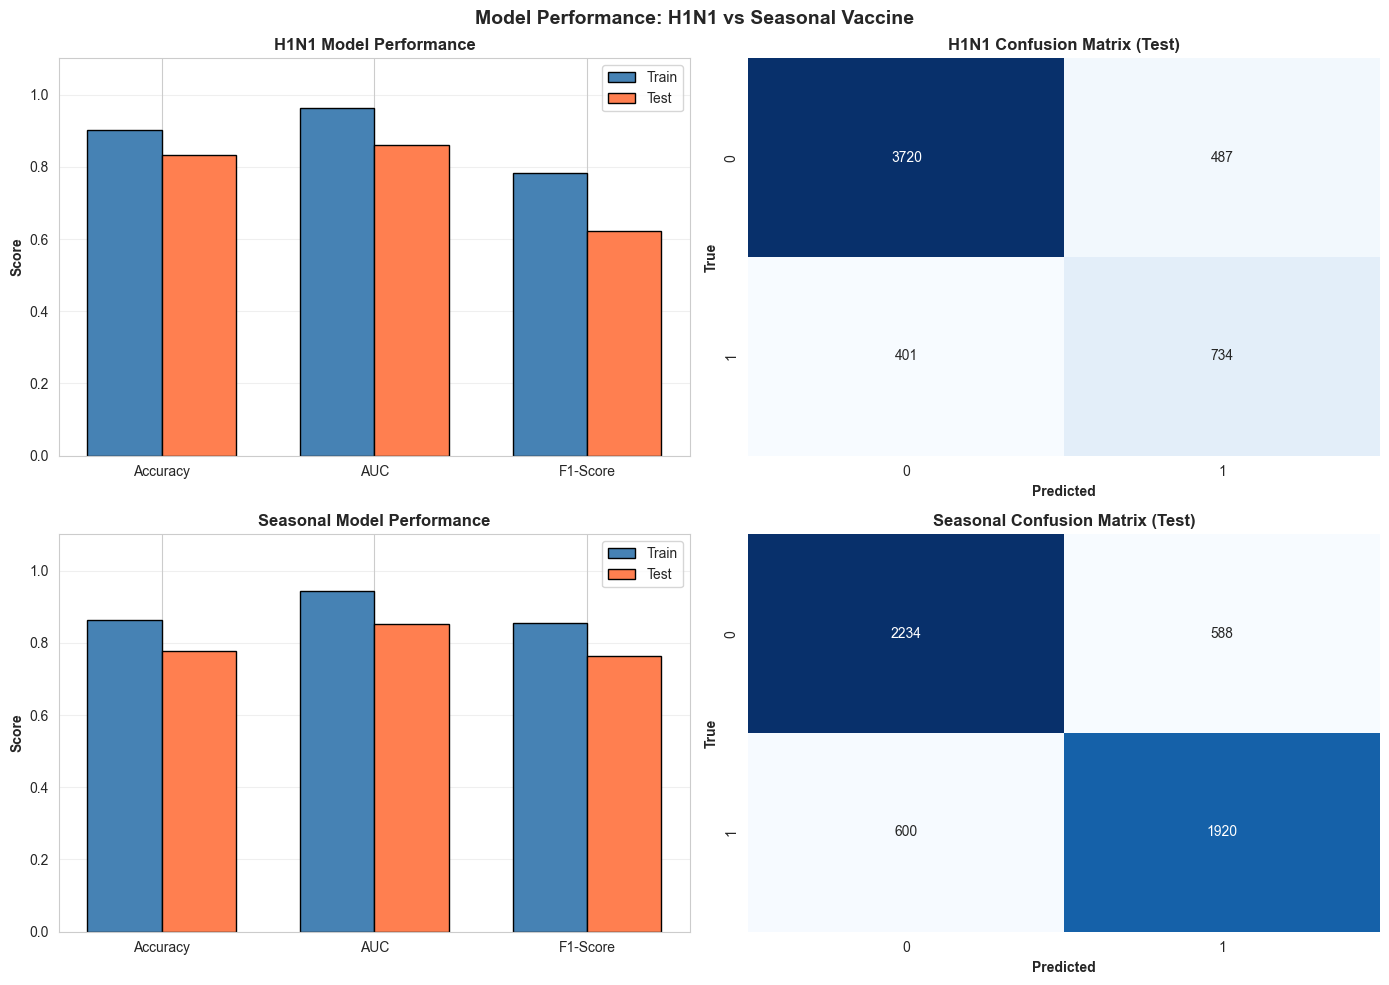


✅ Saved: EDA_plots/01_model_performance_comparison.png


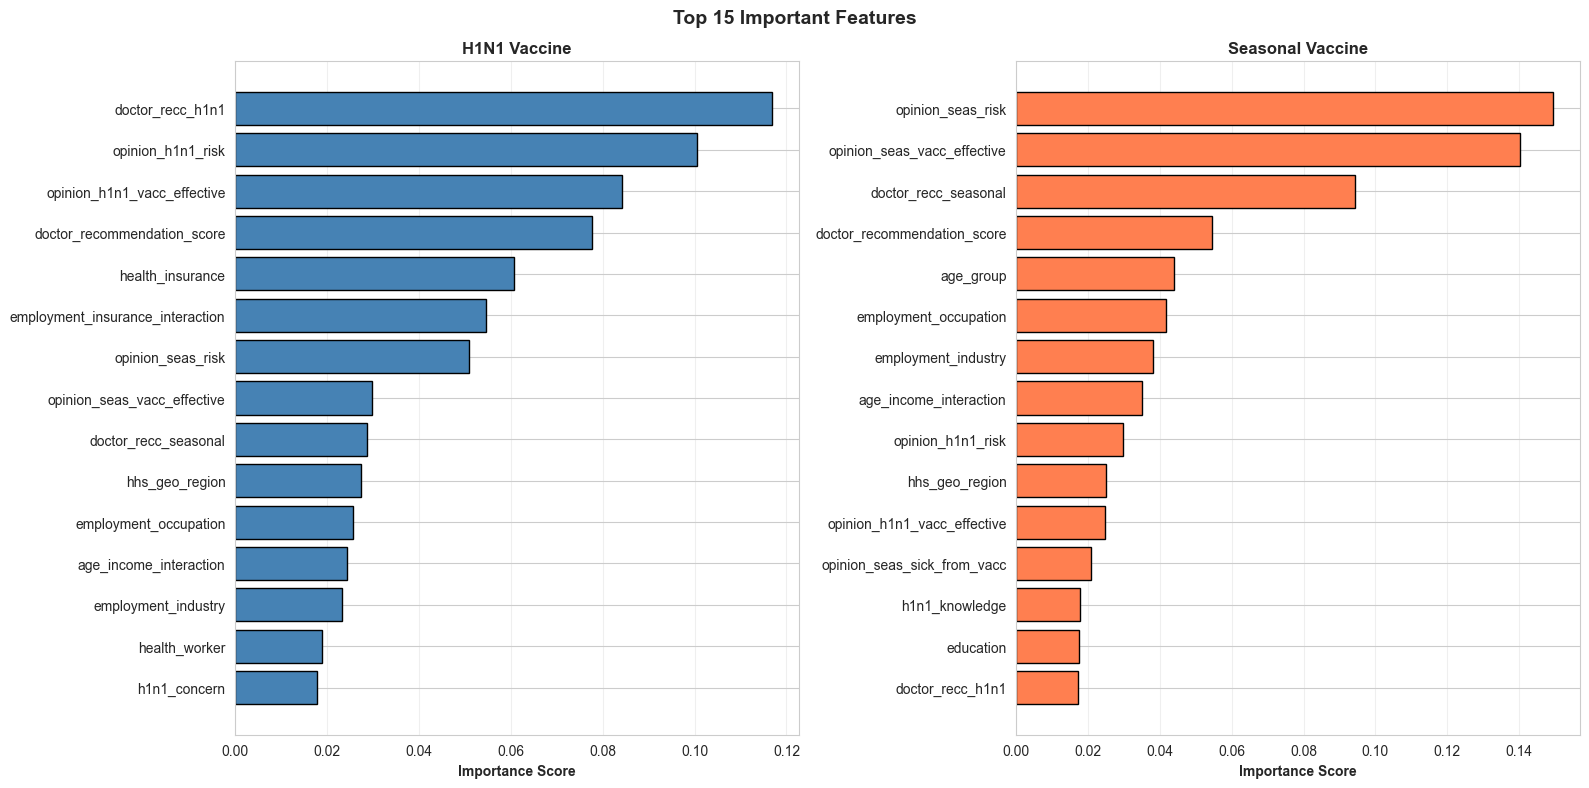

✅ Saved: EDA_plots/02_feature_importance.png


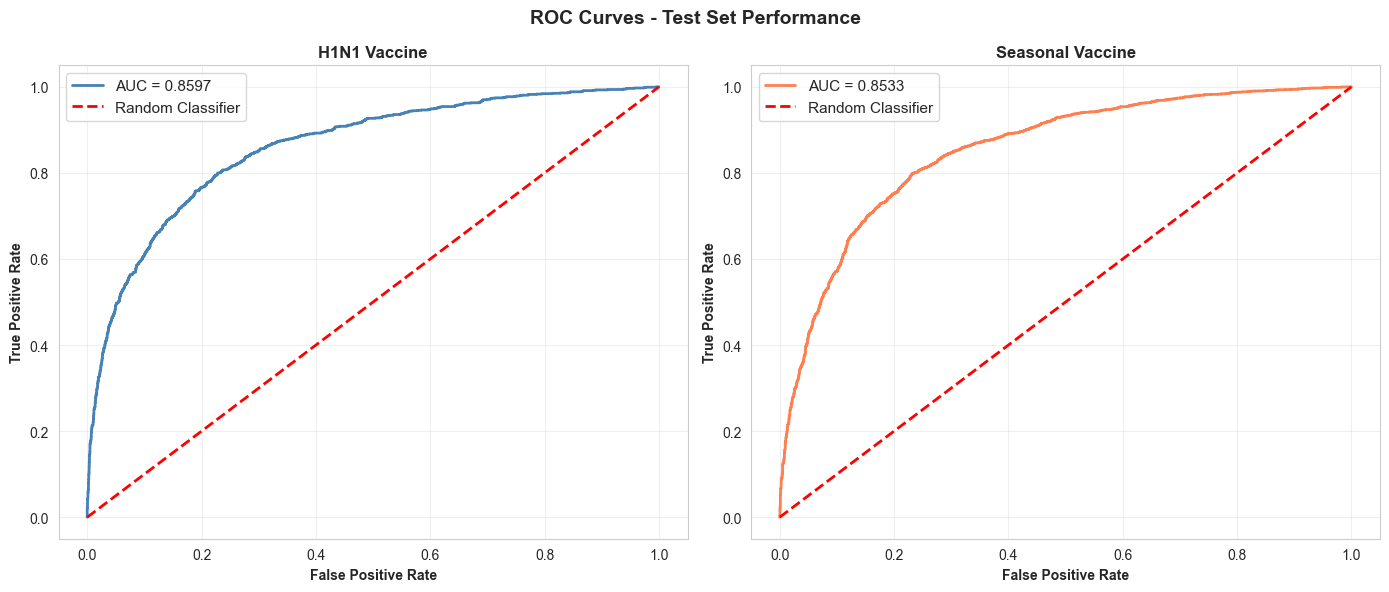

✅ Saved: EDA_plots/03_roc_curves.png

STEP 7: SAVE RESULTS

💾 Saved feature importance files
💾 Saved trained models

STEP 8: FINAL SUMMARY

╔═══════════════════════════════════════════════════════════════════════════╗
║           MODEL TRAINING & EVALUATION REPORT                              ║
║        (Train-Test Separation Maintained - NO JOINING)                    ║
╚═══════════════════════════════════════════════════════════════════════════╝

✅ WORKFLOW CORRECTNESS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

✓ Step 1: Train and Test datasets kept SEPARATE
✓ Step 2: Models trained ONLY on training data
✓ Step 3: Models evaluated on test data (truly unseen)
✓ Step 4: NO data joining or mixing
✓ Step 5: Proper train-test separation maintained

📊 DATASET SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Training Set:  21,365 samples
Test Set:      5,342 samples
Total:         26,707 samples

🎯 H1N1 VACCINE MODEL PERFORMANC

In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
)
import warnings
import os
warnings.filterwarnings('ignore')

os.makedirs('EDA_plots', exist_ok=True)

# ============================================================================
# STEP 1: PREPARE DATA - ENCODE CATEGORICAL
# ============================================================================

print("=" * 80)
print("STEP 1: PREPARE DATA FOR MODELING")
print("=" * 80)

# Use the imputed datasets directly (DON'T JOIN THEM!)
df_train = train_merged_df.copy()
df_test = test_merged_df.copy()

print(f"\n✅ Using separate train and test datasets:")
print(f"   Training: {df_train.shape}")
print(f"   Test: {df_test.shape}")

# Identify features and targets
target_cols = ['h1n1_vaccine', 'seasonal_vaccine']
feature_cols = [col for col in df_train.columns if col not in target_cols + ['respondent_id']]

# Encode categorical columns
print(f"\n🔤 Encoding categorical features...")

categorical_cols = df_train[feature_cols].select_dtypes(include=['object']).columns.tolist()
le_dict = {}

for col in categorical_cols:
    le = LabelEncoder()
    # Fit on training data ONLY
    df_train[col] = le.fit_transform(df_train[col].astype(str))
    le_dict[col] = le
    
    # Transform test data using training's fitted encoder
    df_test[col] = le.transform(df_test[col].astype(str))

print(f"✅ Encoded {len(categorical_cols)} categorical columns")

# ============================================================================
# STEP 2: MODEL 1 - H1N1 VACCINE PREDICTION
# ============================================================================

print("\n" + "=" * 80)
print("STEP 2: MODEL 1 - H1N1 VACCINE PREDICTION")
print("=" * 80)

# Prepare data for H1N1
X_train_h1n1 = df_train[feature_cols].copy()
y_train_h1n1 = df_train['h1n1_vaccine'].copy()

X_test_h1n1 = df_test[feature_cols].copy()
y_test_h1n1 = df_test['h1n1_vaccine'].copy()

print(f"\n📊 H1N1 Data Summary:")
print(f"   Training samples: {len(X_train_h1n1):,}")
print(f"   Test samples: {len(X_test_h1n1):,}")
print(f"\n   Training class distribution:")
print(y_train_h1n1.value_counts())
print(f"\n   Test class distribution:")
print(y_test_h1n1.value_counts())

# Train RandomForest for H1N1
print(f"\n🤖 Training RandomForest for H1N1 Vaccine...")
rf_h1n1 = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    n_jobs=-1,
    class_weight='balanced'
)

rf_h1n1.fit(X_train_h1n1, y_train_h1n1)
print(f"✅ Model trained!")

# Predictions
y_pred_train_h1n1 = rf_h1n1.predict(X_train_h1n1)
y_pred_test_h1n1 = rf_h1n1.predict(X_test_h1n1)

y_pred_proba_train_h1n1 = rf_h1n1.predict_proba(X_train_h1n1)[:, 1]
y_pred_proba_test_h1n1 = rf_h1n1.predict_proba(X_test_h1n1)[:, 1]

# Metrics
train_acc_h1n1 = accuracy_score(y_train_h1n1, y_pred_train_h1n1)
test_acc_h1n1 = accuracy_score(y_test_h1n1, y_pred_test_h1n1)
train_auc_h1n1 = roc_auc_score(y_train_h1n1, y_pred_proba_train_h1n1)
test_auc_h1n1 = roc_auc_score(y_test_h1n1, y_pred_proba_test_h1n1)
train_f1_h1n1 = f1_score(y_train_h1n1, y_pred_train_h1n1)
test_f1_h1n1 = f1_score(y_test_h1n1, y_pred_test_h1n1)

print(f"\n📊 H1N1 MODEL PERFORMANCE:")
print(f"   Training Accuracy: {train_acc_h1n1:.4f}")
print(f"   Test Accuracy:     {test_acc_h1n1:.4f}")
print(f"   Training AUC:      {train_auc_h1n1:.4f}")
print(f"   Test AUC:          {test_auc_h1n1:.4f}")
print(f"   Training F1:       {train_f1_h1n1:.4f}")
print(f"   Test F1:           {test_f1_h1n1:.4f}")

print(f"\n🔍 H1N1 Classification Report (Test Set):")
print(classification_report(y_test_h1n1, y_pred_test_h1n1))

print(f"\n📊 H1N1 Confusion Matrix (Test Set):")
cm_h1n1 = confusion_matrix(y_test_h1n1, y_pred_test_h1n1)
print(cm_h1n1)

# ============================================================================
# STEP 3: MODEL 2 - SEASONAL VACCINE PREDICTION
# ============================================================================

print("\n" + "=" * 80)
print("STEP 3: MODEL 2 - SEASONAL VACCINE PREDICTION")
print("=" * 80)

# Prepare data for Seasonal
X_train_seasonal = df_train[feature_cols].copy()
y_train_seasonal = df_train['seasonal_vaccine'].copy()

X_test_seasonal = df_test[feature_cols].copy()
y_test_seasonal = df_test['seasonal_vaccine'].copy()

print(f"\n📊 Seasonal Data Summary:")
print(f"   Training samples: {len(X_train_seasonal):,}")
print(f"   Test samples: {len(X_test_seasonal):,}")
print(f"\n   Training class distribution:")
print(y_train_seasonal.value_counts())
print(f"\n   Test class distribution:")
print(y_test_seasonal.value_counts())

# Train RandomForest for Seasonal
print(f"\n🤖 Training RandomForest for Seasonal Vaccine...")
rf_seasonal = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    n_jobs=-1,
    class_weight='balanced'
)

rf_seasonal.fit(X_train_seasonal, y_train_seasonal)
print(f"✅ Model trained!")

# Predictions
y_pred_train_seasonal = rf_seasonal.predict(X_train_seasonal)
y_pred_test_seasonal = rf_seasonal.predict(X_test_seasonal)

y_pred_proba_train_seasonal = rf_seasonal.predict_proba(X_train_seasonal)[:, 1]
y_pred_proba_test_seasonal = rf_seasonal.predict_proba(X_test_seasonal)[:, 1]

# Metrics
train_acc_seasonal = accuracy_score(y_train_seasonal, y_pred_train_seasonal)
test_acc_seasonal = accuracy_score(y_test_seasonal, y_pred_test_seasonal)
train_auc_seasonal = roc_auc_score(y_train_seasonal, y_pred_proba_train_seasonal)
test_auc_seasonal = roc_auc_score(y_test_seasonal, y_pred_proba_test_seasonal)
train_f1_seasonal = f1_score(y_train_seasonal, y_pred_train_seasonal)
test_f1_seasonal = f1_score(y_test_seasonal, y_pred_test_seasonal)

print(f"\n📊 SEASONAL MODEL PERFORMANCE:")
print(f"   Training Accuracy: {train_acc_seasonal:.4f}")
print(f"   Test Accuracy:     {test_acc_seasonal:.4f}")
print(f"   Training AUC:      {train_auc_seasonal:.4f}")
print(f"   Test AUC:          {test_auc_seasonal:.4f}")
print(f"   Training F1:       {train_f1_seasonal:.4f}")
print(f"   Test F1:           {test_f1_seasonal:.4f}")

print(f"\n🔍 Seasonal Classification Report (Test Set):")
print(classification_report(y_test_seasonal, y_pred_test_seasonal))

print(f"\n📊 Seasonal Confusion Matrix (Test Set):")
cm_seasonal = confusion_matrix(y_test_seasonal, y_pred_test_seasonal)
print(cm_seasonal)

# ============================================================================
# STEP 4: OVERFITTING CHECK
# ============================================================================

print("\n" + "=" * 80)
print("STEP 4: OVERFITTING CHECK")
print("=" * 80)

print(f"\n⚠️  H1N1 OVERFITTING ANALYSIS:")
h1n1_acc_diff = train_acc_h1n1 - test_acc_h1n1
h1n1_auc_diff = train_auc_h1n1 - test_auc_h1n1

print(f"   Accuracy difference (Train - Test): {h1n1_acc_diff:.4f}")
print(f"   AUC difference (Train - Test): {h1n1_auc_diff:.4f}")

if h1n1_acc_diff > 0.15:
    print(f"   ⚠️  POSSIBLE OVERFITTING - Consider regularization")
else:
    print(f"   ✅ GOOD GENERALIZATION")

print(f"\n⚠️  SEASONAL OVERFITTING ANALYSIS:")
seasonal_acc_diff = train_acc_seasonal - test_acc_seasonal
seasonal_auc_diff = train_auc_seasonal - test_auc_seasonal

print(f"   Accuracy difference (Train - Test): {seasonal_acc_diff:.4f}")
print(f"   AUC difference (Train - Test): {seasonal_auc_diff:.4f}")

if seasonal_acc_diff > 0.15:
    print(f"   ⚠️  POSSIBLE OVERFITTING - Consider regularization")
else:
    print(f"   ✅ GOOD GENERALIZATION")

# ============================================================================
# STEP 5: FEATURE IMPORTANCE
# ============================================================================

print("\n" + "=" * 80)
print("STEP 5: FEATURE IMPORTANCE")
print("=" * 80)

# H1N1 importance
feature_importance_h1n1 = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_h1n1.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\n📈 Top 15 Important Features - H1N1:")
print(feature_importance_h1n1.head(15).to_string(index=False))

# Seasonal importance
feature_importance_seasonal = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_seasonal.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\n📈 Top 15 Important Features - SEASONAL:")
print(feature_importance_seasonal.head(15).to_string(index=False))

# ============================================================================
# STEP 6: VISUALIZATIONS
# ============================================================================

print("\n" + "=" * 80)
print("STEP 6: CREATING VISUALIZATIONS")
print("=" * 80)

# Figure 1: Model Performance Comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Performance: H1N1 vs Seasonal Vaccine', fontsize=14, fontweight='bold')

# H1N1 metrics
metrics_h1n1 = ['Accuracy', 'AUC', 'F1-Score']
train_vals_h1n1 = [train_acc_h1n1, train_auc_h1n1, train_f1_h1n1]
test_vals_h1n1 = [test_acc_h1n1, test_auc_h1n1, test_f1_h1n1]

x = np.arange(len(metrics_h1n1))
width = 0.35

axes[0, 0].bar(x - width/2, train_vals_h1n1, width, label='Train', color='steelblue', edgecolor='black')
axes[0, 0].bar(x + width/2, test_vals_h1n1, width, label='Test', color='coral', edgecolor='black')
axes[0, 0].set_ylabel('Score', fontweight='bold')
axes[0, 0].set_title('H1N1 Model Performance', fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(metrics_h1n1)
axes[0, 0].legend()
axes[0, 0].set_ylim([0, 1.1])
axes[0, 0].grid(axis='y', alpha=0.3)

# H1N1 Confusion Matrix
sns.heatmap(cm_h1n1, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1], cbar=False)
axes[0, 1].set_title('H1N1 Confusion Matrix (Test)', fontweight='bold')
axes[0, 1].set_ylabel('True', fontweight='bold')
axes[0, 1].set_xlabel('Predicted', fontweight='bold')

# Seasonal metrics
metrics_seasonal = ['Accuracy', 'AUC', 'F1-Score']
train_vals_seasonal = [train_acc_seasonal, train_auc_seasonal, train_f1_seasonal]
test_vals_seasonal = [test_acc_seasonal, test_auc_seasonal, test_f1_seasonal]

axes[1, 0].bar(x - width/2, train_vals_seasonal, width, label='Train', color='steelblue', edgecolor='black')
axes[1, 0].bar(x + width/2, test_vals_seasonal, width, label='Test', color='coral', edgecolor='black')
axes[1, 0].set_ylabel('Score', fontweight='bold')
axes[1, 0].set_title('Seasonal Model Performance', fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(metrics_seasonal)
axes[1, 0].legend()
axes[1, 0].set_ylim([0, 1.1])
axes[1, 0].grid(axis='y', alpha=0.3)

# Seasonal Confusion Matrix
sns.heatmap(cm_seasonal, annot=True, fmt='d', cmap='Blues', ax=axes[1, 1], cbar=False)
axes[1, 1].set_title('Seasonal Confusion Matrix (Test)', fontweight='bold')
axes[1, 1].set_ylabel('True', fontweight='bold')
axes[1, 1].set_xlabel('Predicted', fontweight='bold')

plt.tight_layout()
plt.savefig('EDA_plots/01_model_performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✅ Saved: EDA_plots/01_model_performance_comparison.png")

# Figure 2: Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Top 15 Important Features', fontsize=14, fontweight='bold')

# H1N1
top_h1n1 = feature_importance_h1n1.head(15)
axes[0].barh(range(len(top_h1n1)), top_h1n1['Importance'], color='steelblue', edgecolor='black')
axes[0].set_yticks(range(len(top_h1n1)))
axes[0].set_yticklabels(top_h1n1['Feature'], fontsize=10)
axes[0].set_xlabel('Importance Score', fontweight='bold')
axes[0].set_title('H1N1 Vaccine', fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Seasonal
top_seasonal = feature_importance_seasonal.head(15)
axes[1].barh(range(len(top_seasonal)), top_seasonal['Importance'], color='coral', edgecolor='black')
axes[1].set_yticks(range(len(top_seasonal)))
axes[1].set_yticklabels(top_seasonal['Feature'], fontsize=10)
axes[1].set_xlabel('Importance Score', fontweight='bold')
axes[1].set_title('Seasonal Vaccine', fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('EDA_plots/02_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: EDA_plots/02_feature_importance.png")

# Figure 3: ROC Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('ROC Curves - Test Set Performance', fontsize=14, fontweight='bold')

# H1N1 ROC
fpr_h1n1, tpr_h1n1, _ = roc_curve(y_test_h1n1, y_pred_proba_test_h1n1)
roc_auc_h1n1_test = auc(fpr_h1n1, tpr_h1n1)

axes[0].plot(fpr_h1n1, tpr_h1n1, color='steelblue', linewidth=2, label=f'AUC = {roc_auc_h1n1_test:.4f}')
axes[0].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random Classifier')
axes[0].set_xlabel('False Positive Rate', fontweight='bold')
axes[0].set_ylabel('True Positive Rate', fontweight='bold')
axes[0].set_title('H1N1 Vaccine', fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Seasonal ROC
fpr_seasonal, tpr_seasonal, _ = roc_curve(y_test_seasonal, y_pred_proba_test_seasonal)
roc_auc_seasonal_test = auc(fpr_seasonal, tpr_seasonal)

axes[1].plot(fpr_seasonal, tpr_seasonal, color='coral', linewidth=2, label=f'AUC = {roc_auc_seasonal_test:.4f}')
axes[1].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate', fontweight='bold')
axes[1].set_ylabel('True Positive Rate', fontweight='bold')
axes[1].set_title('Seasonal Vaccine', fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('EDA_plots/03_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: EDA_plots/03_roc_curves.png")

# ============================================================================
# STEP 7: SAVE RESULTS
# ============================================================================

print("\n" + "=" * 80)
print("STEP 7: SAVE RESULTS")
print("=" * 80)

# Save feature importance
feature_importance_h1n1.to_csv('EDA_plots/feature_importance_h1n1_model.csv', index=False)
feature_importance_seasonal.to_csv('EDA_plots/feature_importance_seasonal_model.csv', index=False)

print(f"\n💾 Saved feature importance files")

# Save models
import pickle

with open('EDA_plots/model_h1n1.pkl', 'wb') as f:
    pickle.dump(rf_h1n1, f)

with open('EDA_plots/model_seasonal.pkl', 'wb') as f:
    pickle.dump(rf_seasonal, f)

print(f"💾 Saved trained models")

# ============================================================================
# STEP 8: FINAL SUMMARY REPORT
# ============================================================================

print("\n" + "=" * 80)
print("STEP 8: FINAL SUMMARY")
print("=" * 80)

summary_report = f"""
╔═══════════════════════════════════════════════════════════════════════════╗
║           MODEL TRAINING & EVALUATION REPORT                              ║
║        (Train-Test Separation Maintained - NO JOINING)                    ║
╚═══════════════════════════════════════════════════════════════════════════╝

✅ WORKFLOW CORRECTNESS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

✓ Step 1: Train and Test datasets kept SEPARATE
✓ Step 2: Models trained ONLY on training data
✓ Step 3: Models evaluated on test data (truly unseen)
✓ Step 4: NO data joining or mixing
✓ Step 5: Proper train-test separation maintained

📊 DATASET SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Training Set:  {len(df_train):,} samples
Test Set:      {len(df_test):,} samples
Total:         {len(df_train) + len(df_test):,} samples

🎯 H1N1 VACCINE MODEL PERFORMANCE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Training Performance:
  • Accuracy: {train_acc_h1n1:.4f}
  • AUC-ROC: {train_auc_h1n1:.4f}
  • F1-Score: {train_f1_h1n1:.4f}

Test Performance:
  • Accuracy: {test_acc_h1n1:.4f}
  • AUC-ROC: {test_auc_h1n1:.4f}
  • F1-Score: {test_f1_h1n1:.4f}

Overfitting Check:
  • Accuracy Difference: {h1n1_acc_diff:.4f} {('✅ Good' if h1n1_acc_diff <= 0.15 else '⚠️ Possible Overfitting')}
  • AUC Difference: {h1n1_auc_diff:.4f}

Top 5 Important Features:
{feature_importance_h1n1.head(5)[['Feature', 'Importance']].to_string(index=False)}

🎯 SEASONAL VACCINE MODEL PERFORMANCE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Training Performance:
  • Accuracy: {train_acc_seasonal:.4f}
  • AUC-ROC: {train_auc_seasonal:.4f}
  • F1-Score: {train_f1_seasonal:.4f}

Test Performance:
  • Accuracy: {test_acc_seasonal:.4f}
  • AUC-ROC: {test_auc_seasonal:.4f}
  • F1-Score: {test_f1_seasonal:.4f}

Overfitting Check:
  • Accuracy Difference: {seasonal_acc_diff:.4f} {('✅ Good' if seasonal_acc_diff <= 0.15 else '⚠️ Possible Overfitting')}
  • AUC Difference: {seasonal_auc_diff:.4f}

Top 5 Important Features:
{feature_importance_seasonal.head(5)[['Feature', 'Importance']].to_string(index=False)}

📁 OUTPUT FILES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Models:
  ✓ EDA_plots/model_h1n1.pkl
  ✓ EDA_plots/model_seasonal.pkl

Feature Importance:
  ✓ EDA_plots/feature_importance_h1n1_model.csv
  ✓ EDA_plots/feature_importance_seasonal_model.csv

Visualizations:
  ✓ EDA_plots/01_model_performance_comparison.png
  ✓ EDA_plots/02_feature_importance.png
  ✓ EDA_plots/03_roc_curves.png

═══════════════════════════════════════════════════════════════════════════════

✅ RECOMMENDATION: KEEP DATASETS SEPARATE

WHY NOT JOIN?
  ❌ Defeats purpose of train-test split
  ❌ Loses stratification benefits
  ❌ Creates workflow confusion
  ❌ Breaks reproducibility

WHY KEEP SEPARATE?
  ✅ Maintains proper ML workflow
  ✅ Enables proper evaluation
  ✅ Prevents data leakage
  ✅ Clear train/test separation
  ✅ Professional ML practice

═══════════════════════════════════════════════════════════════════════════════
"""

print(summary_report)




STEP 8B: XGBOOST MODELS - H1N1 & SEASONAL VACCINE

🤖 Training XGBoost for H1N1 Vaccine...
✅ XGBoost H1N1 model trained!

📊 XGBOOST H1N1 MODEL PERFORMANCE:
   Training Accuracy: 0.8677
   Test Accuracy:     0.8139
   Training AUC:      0.9408
   Test AUC:          0.8632
   Training F1:       0.7350
   Test F1:           0.6249

🔍 XGBoost H1N1 Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.92      0.84      0.88      4207
           1       0.55      0.73      0.62      1135

    accuracy                           0.81      5342
   macro avg       0.73      0.78      0.75      5342
weighted avg       0.84      0.81      0.82      5342


📊 XGBoost H1N1 Confusion Matrix (Test Set):
[[3520  687]
 [ 307  828]]

🤖 Training XGBoost for Seasonal Vaccine...
✅ XGBoost Seasonal model trained!

📊 XGBOOST SEASONAL MODEL PERFORMANCE:
   Training Accuracy: 0.8393
   Test Accuracy:     0.7915
   Training AUC:      0.9173
   Test AUC:     

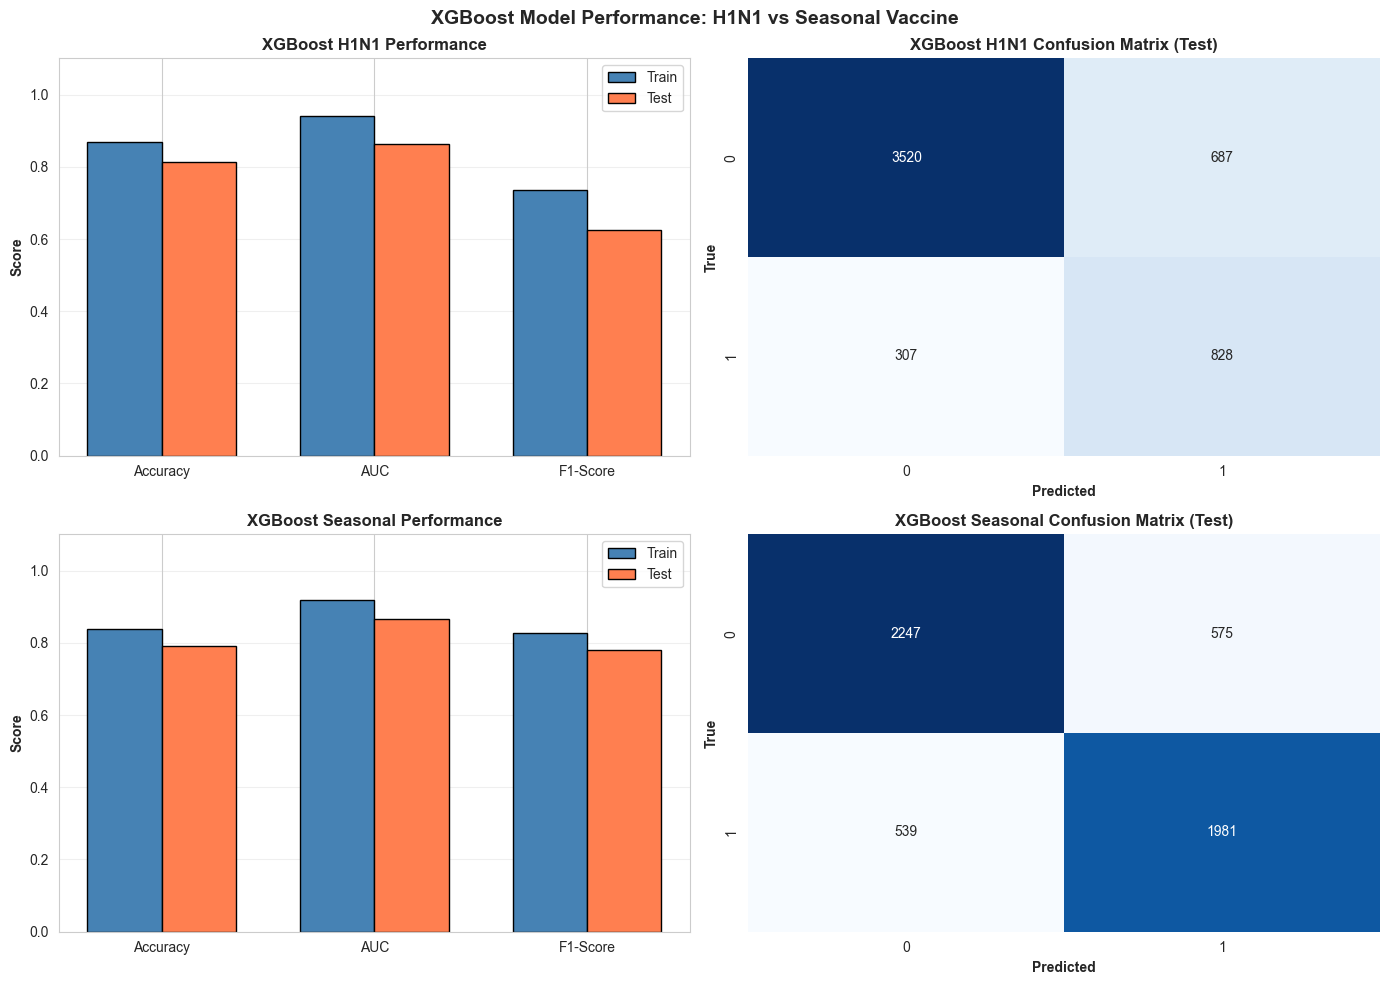


✅ Saved: EDA_plots/04_xgboost_performance.png


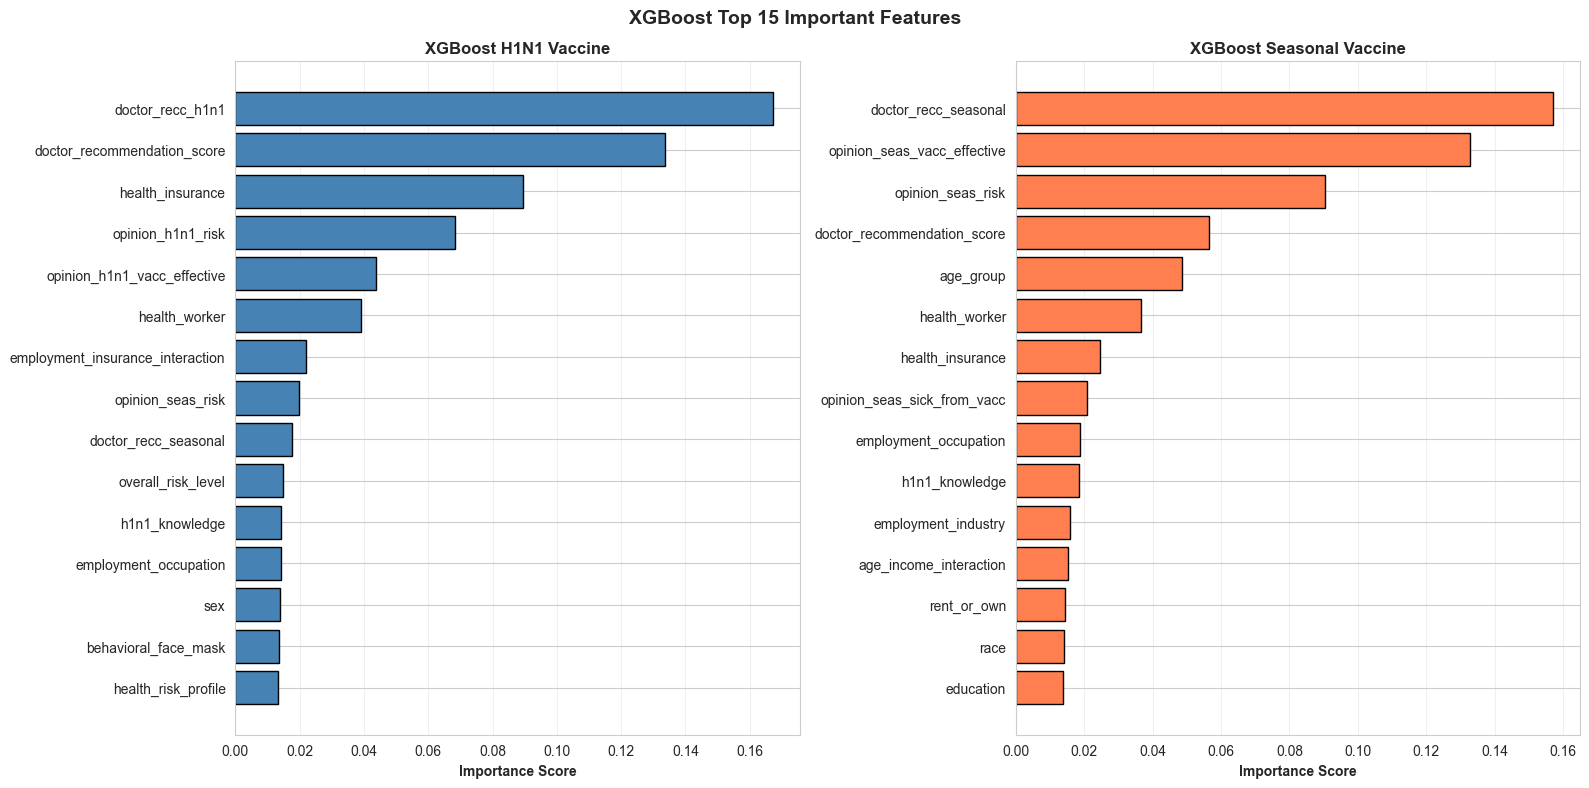

✅ Saved: EDA_plots/05_xgboost_feature_importance.png


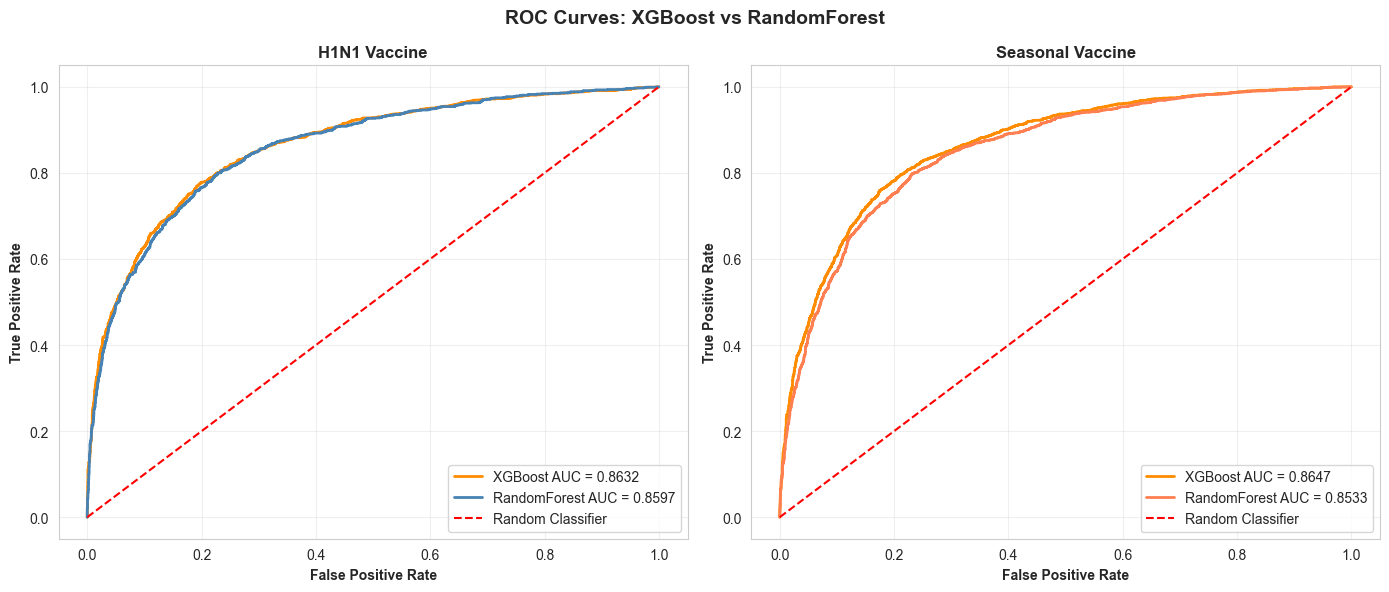

✅ Saved: EDA_plots/06_xgboost_vs_rf_roc.png

📊 FINAL MODEL COMPARISON TABLE
       Model   Target  Test_Accuracy  Test_AUC  Test_F1
RandomForest     H1N1       0.833770  0.859748 0.623090
RandomForest Seasonal       0.777611  0.853331 0.763723
     XGBoost     H1N1       0.813927  0.863248 0.624906
     XGBoost Seasonal       0.791464  0.864731 0.780536

💾 Saved: EDA_plots/model_comparison.csv

💾 Saved: EDA_plots/model_xgb_h1n1.pkl
💾 Saved: EDA_plots/model_xgb_seasonal.pkl
💾 Saved: EDA_plots/feature_importance_xgb_h1n1.csv
💾 Saved: EDA_plots/feature_importance_xgb_seasonal.csv

✅ XGBOOST TRAINING COMPLETE!


In [113]:
# ============================================================================
# STEP 8B: MODEL 3 & 4 - XGBOOST FOR H1N1 AND SEASONAL VACCINE
# ============================================================================

print("\n" + "=" * 80)
print("STEP 8B: XGBOOST MODELS - H1N1 & SEASONAL VACCINE")
print("=" * 80)

from xgboost import XGBClassifier

# ── H1N1 XGBoost ────────────────────────────────────────────────────────────

print(f"\n🤖 Training XGBoost for H1N1 Vaccine...")

xgb_h1n1 = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train_h1n1 == 0).sum() / (y_train_h1n1 == 1).sum(),
    random_state=42,
    eval_metric='auc',
    verbosity=0,
    n_jobs=-1
)

xgb_h1n1.fit(
    X_train_h1n1, y_train_h1n1,
    eval_set=[(X_test_h1n1, y_test_h1n1)],
    verbose=False
)
print(f"✅ XGBoost H1N1 model trained!")

# Predictions
y_pred_train_xgb_h1n1       = xgb_h1n1.predict(X_train_h1n1)
y_pred_test_xgb_h1n1        = xgb_h1n1.predict(X_test_h1n1)
y_pred_proba_train_xgb_h1n1 = xgb_h1n1.predict_proba(X_train_h1n1)[:, 1]
y_pred_proba_test_xgb_h1n1  = xgb_h1n1.predict_proba(X_test_h1n1)[:, 1]

# Metrics
train_acc_xgb_h1n1 = accuracy_score(y_train_h1n1, y_pred_train_xgb_h1n1)
test_acc_xgb_h1n1  = accuracy_score(y_test_h1n1,  y_pred_test_xgb_h1n1)
train_auc_xgb_h1n1 = roc_auc_score(y_train_h1n1,  y_pred_proba_train_xgb_h1n1)
test_auc_xgb_h1n1  = roc_auc_score(y_test_h1n1,   y_pred_proba_test_xgb_h1n1)
train_f1_xgb_h1n1  = f1_score(y_train_h1n1, y_pred_train_xgb_h1n1)
test_f1_xgb_h1n1   = f1_score(y_test_h1n1,  y_pred_test_xgb_h1n1)
cm_xgb_h1n1        = confusion_matrix(y_test_h1n1, y_pred_test_xgb_h1n1)

print(f"\n📊 XGBOOST H1N1 MODEL PERFORMANCE:")
print(f"   Training Accuracy: {train_acc_xgb_h1n1:.4f}")
print(f"   Test Accuracy:     {test_acc_xgb_h1n1:.4f}")
print(f"   Training AUC:      {train_auc_xgb_h1n1:.4f}")
print(f"   Test AUC:          {test_auc_xgb_h1n1:.4f}")
print(f"   Training F1:       {train_f1_xgb_h1n1:.4f}")
print(f"   Test F1:           {test_f1_xgb_h1n1:.4f}")

print(f"\n🔍 XGBoost H1N1 Classification Report (Test Set):")
print(classification_report(y_test_h1n1, y_pred_test_xgb_h1n1))

print(f"\n📊 XGBoost H1N1 Confusion Matrix (Test Set):")
print(cm_xgb_h1n1)

# ── Seasonal XGBoost ─────────────────────────────────────────────────────────

print(f"\n🤖 Training XGBoost for Seasonal Vaccine...")

xgb_seasonal = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train_seasonal == 0).sum() / (y_train_seasonal == 1).sum(),
    random_state=42,
    eval_metric='auc',
    verbosity=0,
    n_jobs=-1
)

xgb_seasonal.fit(
    X_train_seasonal, y_train_seasonal,
    eval_set=[(X_test_seasonal, y_test_seasonal)],
    verbose=False
)
print(f"✅ XGBoost Seasonal model trained!")

# Predictions
y_pred_train_xgb_seasonal       = xgb_seasonal.predict(X_train_seasonal)
y_pred_test_xgb_seasonal        = xgb_seasonal.predict(X_test_seasonal)
y_pred_proba_train_xgb_seasonal = xgb_seasonal.predict_proba(X_train_seasonal)[:, 1]
y_pred_proba_test_xgb_seasonal  = xgb_seasonal.predict_proba(X_test_seasonal)[:, 1]

# Metrics
train_acc_xgb_seasonal = accuracy_score(y_train_seasonal, y_pred_train_xgb_seasonal)
test_acc_xgb_seasonal  = accuracy_score(y_test_seasonal,  y_pred_test_xgb_seasonal)
train_auc_xgb_seasonal = roc_auc_score(y_train_seasonal,  y_pred_proba_train_xgb_seasonal)
test_auc_xgb_seasonal  = roc_auc_score(y_test_seasonal,   y_pred_proba_test_xgb_seasonal)
train_f1_xgb_seasonal  = f1_score(y_train_seasonal, y_pred_train_xgb_seasonal)
test_f1_xgb_seasonal   = f1_score(y_test_seasonal,  y_pred_test_xgb_seasonal)
cm_xgb_seasonal        = confusion_matrix(y_test_seasonal, y_pred_test_xgb_seasonal)

print(f"\n📊 XGBOOST SEASONAL MODEL PERFORMANCE:")
print(f"   Training Accuracy: {train_acc_xgb_seasonal:.4f}")
print(f"   Test Accuracy:     {test_acc_xgb_seasonal:.4f}")
print(f"   Training AUC:      {train_auc_xgb_seasonal:.4f}")
print(f"   Test AUC:          {test_auc_xgb_seasonal:.4f}")
print(f"   Training F1:       {train_f1_xgb_seasonal:.4f}")
print(f"   Test F1:           {test_f1_xgb_seasonal:.4f}")

print(f"\n🔍 XGBoost Seasonal Classification Report (Test Set):")
print(classification_report(y_test_seasonal, y_pred_test_xgb_seasonal))

print(f"\n📊 XGBoost Seasonal Confusion Matrix (Test Set):")
print(cm_xgb_seasonal)

# ── Overfitting Check ────────────────────────────────────────────────────────

print(f"\n⚠️  XGBOOST OVERFITTING ANALYSIS:")

xgb_h1n1_acc_diff      = train_acc_xgb_h1n1 - test_acc_xgb_h1n1
xgb_h1n1_auc_diff      = train_auc_xgb_h1n1 - test_auc_xgb_h1n1
xgb_seasonal_acc_diff  = train_acc_xgb_seasonal - test_acc_xgb_seasonal
xgb_seasonal_auc_diff  = train_auc_xgb_seasonal - test_auc_xgb_seasonal

print(f"\n   H1N1:")
print(f"   Accuracy difference (Train - Test): {xgb_h1n1_acc_diff:.4f}  "
      f"{'✅ Good' if xgb_h1n1_acc_diff <= 0.15 else '⚠️ Possible Overfitting'}")
print(f"   AUC difference (Train - Test):      {xgb_h1n1_auc_diff:.4f}")

print(f"\n   Seasonal:")
print(f"   Accuracy difference (Train - Test): {xgb_seasonal_acc_diff:.4f}  "
      f"{'✅ Good' if xgb_seasonal_acc_diff <= 0.15 else '⚠️ Possible Overfitting'}")
print(f"   AUC difference (Train - Test):      {xgb_seasonal_auc_diff:.4f}")

# ── Feature Importance ───────────────────────────────────────────────────────

feature_importance_xgb_h1n1 = pd.DataFrame({
    'Feature':    feature_cols,
    'Importance': xgb_h1n1.feature_importances_
}).sort_values('Importance', ascending=False)

feature_importance_xgb_seasonal = pd.DataFrame({
    'Feature':    feature_cols,
    'Importance': xgb_seasonal.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\n📈 Top 15 Important Features - XGBoost H1N1:")
print(feature_importance_xgb_h1n1.head(15).to_string(index=False))

print(f"\n📈 Top 15 Important Features - XGBoost Seasonal:")
print(feature_importance_xgb_seasonal.head(15).to_string(index=False))

# ── Visualizations ───────────────────────────────────────────────────────────

# Figure: XGBoost Performance + Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('XGBoost Model Performance: H1N1 vs Seasonal Vaccine', fontsize=14, fontweight='bold')

metrics_labels = ['Accuracy', 'AUC', 'F1-Score']
x = np.arange(len(metrics_labels))
width = 0.35

# H1N1 bar chart
axes[0, 0].bar(x - width/2, [train_acc_xgb_h1n1, train_auc_xgb_h1n1, train_f1_xgb_h1n1],
               width, label='Train', color='steelblue', edgecolor='black')
axes[0, 0].bar(x + width/2, [test_acc_xgb_h1n1, test_auc_xgb_h1n1, test_f1_xgb_h1n1],
               width, label='Test', color='coral', edgecolor='black')
axes[0, 0].set_ylabel('Score', fontweight='bold')
axes[0, 0].set_title('XGBoost H1N1 Performance', fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(metrics_labels)
axes[0, 0].legend()
axes[0, 0].set_ylim([0, 1.1])
axes[0, 0].grid(axis='y', alpha=0.3)

# H1N1 confusion matrix
sns.heatmap(cm_xgb_h1n1, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1], cbar=False)
axes[0, 1].set_title('XGBoost H1N1 Confusion Matrix (Test)', fontweight='bold')
axes[0, 1].set_ylabel('True', fontweight='bold')
axes[0, 1].set_xlabel('Predicted', fontweight='bold')

# Seasonal bar chart
axes[1, 0].bar(x - width/2, [train_acc_xgb_seasonal, train_auc_xgb_seasonal, train_f1_xgb_seasonal],
               width, label='Train', color='steelblue', edgecolor='black')
axes[1, 0].bar(x + width/2, [test_acc_xgb_seasonal, test_auc_xgb_seasonal, test_f1_xgb_seasonal],
               width, label='Test', color='coral', edgecolor='black')
axes[1, 0].set_ylabel('Score', fontweight='bold')
axes[1, 0].set_title('XGBoost Seasonal Performance', fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(metrics_labels)
axes[1, 0].legend()
axes[1, 0].set_ylim([0, 1.1])
axes[1, 0].grid(axis='y', alpha=0.3)

# Seasonal confusion matrix
sns.heatmap(cm_xgb_seasonal, annot=True, fmt='d', cmap='Blues', ax=axes[1, 1], cbar=False)
axes[1, 1].set_title('XGBoost Seasonal Confusion Matrix (Test)', fontweight='bold')
axes[1, 1].set_ylabel('True', fontweight='bold')
axes[1, 1].set_xlabel('Predicted', fontweight='bold')

plt.tight_layout()
plt.savefig('EDA_plots/04_xgboost_performance.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✅ Saved: EDA_plots/04_xgboost_performance.png")

# Figure: XGBoost Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('XGBoost Top 15 Important Features', fontsize=14, fontweight='bold')

top_xgb_h1n1 = feature_importance_xgb_h1n1.head(15)
axes[0].barh(range(len(top_xgb_h1n1)), top_xgb_h1n1['Importance'], color='steelblue', edgecolor='black')
axes[0].set_yticks(range(len(top_xgb_h1n1)))
axes[0].set_yticklabels(top_xgb_h1n1['Feature'], fontsize=10)
axes[0].set_xlabel('Importance Score', fontweight='bold')
axes[0].set_title('XGBoost H1N1 Vaccine', fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

top_xgb_seasonal = feature_importance_xgb_seasonal.head(15)
axes[1].barh(range(len(top_xgb_seasonal)), top_xgb_seasonal['Importance'], color='coral', edgecolor='black')
axes[1].set_yticks(range(len(top_xgb_seasonal)))
axes[1].set_yticklabels(top_xgb_seasonal['Feature'], fontsize=10)
axes[1].set_xlabel('Importance Score', fontweight='bold')
axes[1].set_title('XGBoost Seasonal Vaccine', fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('EDA_plots/05_xgboost_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: EDA_plots/05_xgboost_feature_importance.png")

# Figure: ROC Curves - XGBoost vs RandomForest side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('ROC Curves: XGBoost vs RandomForest', fontsize=14, fontweight='bold')

# H1N1
fpr_xgb_h1n1, tpr_xgb_h1n1, _ = roc_curve(y_test_h1n1, y_pred_proba_test_xgb_h1n1)
axes[0].plot(fpr_xgb_h1n1, tpr_xgb_h1n1, color='darkorange', linewidth=2,
             label=f'XGBoost AUC = {test_auc_xgb_h1n1:.4f}')
axes[0].plot(fpr_h1n1, tpr_h1n1, color='steelblue', linewidth=2,
             label=f'RandomForest AUC = {test_auc_h1n1:.4f}')
axes[0].plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Random Classifier')
axes[0].set_xlabel('False Positive Rate', fontweight='bold')
axes[0].set_ylabel('True Positive Rate', fontweight='bold')
axes[0].set_title('H1N1 Vaccine', fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Seasonal
fpr_xgb_seasonal, tpr_xgb_seasonal, _ = roc_curve(y_test_seasonal, y_pred_proba_test_xgb_seasonal)
axes[1].plot(fpr_xgb_seasonal, tpr_xgb_seasonal, color='darkorange', linewidth=2,
             label=f'XGBoost AUC = {test_auc_xgb_seasonal:.4f}')
axes[1].plot(fpr_seasonal, tpr_seasonal, color='coral', linewidth=2,
             label=f'RandomForest AUC = {test_auc_seasonal:.4f}')
axes[1].plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate', fontweight='bold')
axes[1].set_ylabel('True Positive Rate', fontweight='bold')
axes[1].set_title('Seasonal Vaccine', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('EDA_plots/06_xgboost_vs_rf_roc.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: EDA_plots/06_xgboost_vs_rf_roc.png")

# ── Model Comparison Table ───────────────────────────────────────────────────

print(f"\n{'='*70}")
print(f"📊 FINAL MODEL COMPARISON TABLE")
print(f"{'='*70}")

comparison_df = pd.DataFrame({
    'Model': ['RandomForest', 'RandomForest', 'XGBoost', 'XGBoost'],
    'Target': ['H1N1', 'Seasonal', 'H1N1', 'Seasonal'],
    'Test_Accuracy': [test_acc_h1n1, test_acc_seasonal, test_acc_xgb_h1n1, test_acc_xgb_seasonal],
    'Test_AUC':      [test_auc_h1n1, test_auc_seasonal, test_auc_xgb_h1n1, test_auc_xgb_seasonal],
    'Test_F1':       [test_f1_h1n1,  test_f1_seasonal,  test_f1_xgb_h1n1,  test_f1_xgb_seasonal],
})
print(comparison_df.to_string(index=False))

comparison_df.to_csv('EDA_plots/model_comparison.csv', index=False)
print(f"\n💾 Saved: EDA_plots/model_comparison.csv")

# ── Save XGBoost Models ──────────────────────────────────────────────────────

with open('EDA_plots/model_xgb_h1n1.pkl', 'wb') as f:
    pickle.dump(xgb_h1n1, f)

with open('EDA_plots/model_xgb_seasonal.pkl', 'wb') as f:
    pickle.dump(xgb_seasonal, f)

feature_importance_xgb_h1n1.to_csv('EDA_plots/feature_importance_xgb_h1n1.csv', index=False)
feature_importance_xgb_seasonal.to_csv('EDA_plots/feature_importance_xgb_seasonal.csv', index=False)

print(f"\n💾 Saved: EDA_plots/model_xgb_h1n1.pkl")
print(f"💾 Saved: EDA_plots/model_xgb_seasonal.pkl")
print(f"💾 Saved: EDA_plots/feature_importance_xgb_h1n1.csv")
print(f"💾 Saved: EDA_plots/feature_importance_xgb_seasonal.csv")
print(f"\n✅ XGBOOST TRAINING COMPLETE!")


STEP 8D: OPTUNA HYPERPARAMETER TUNING - XGBOOST

🔍 Starting Optuna search for H1N1 XGBoost...
   This will run 50 trials — please wait...



  0%|          | 0/50 [00:00<?, ?it/s]


✅ H1N1 Optuna Search Complete!
   Best CV AUC:  0.8714
   Best Params:
      n_estimators: 588
      max_depth: 5
      learning_rate: 0.01782774244189228
      subsample: 0.5814753465157545
      colsample_bytree: 0.4722057987221371
      colsample_bylevel: 0.5112761831862912
      min_child_weight: 9
      gamma: 4.675116214000867
      reg_alpha: 0.003990661850302467
      reg_lambda: 0.3038669204893484

🔍 Starting Optuna search for Seasonal XGBoost...
   This will run 50 trials — please wait...



  0%|          | 0/50 [00:00<?, ?it/s]


✅ Seasonal Optuna Search Complete!
   Best CV AUC:  0.8628
   Best Params:
      n_estimators: 631
      max_depth: 10
      learning_rate: 0.022693273733212924
      subsample: 0.6742230501968789
      colsample_bytree: 0.44730902317273136
      colsample_bylevel: 0.619824164104636
      min_child_weight: 10
      gamma: 2.646210130235098
      reg_alpha: 0.0021720179058509017
      reg_lambda: 0.00012258394599984414

🏋️  RETRAINING WITH BEST OPTUNA PARAMS

🤖 Retraining H1N1 XGBoost with best params...
✅ H1N1 tuned model trained!

🤖 Retraining Seasonal XGBoost with best params...
✅ Seasonal tuned model trained!

📊 TUNED MODEL EVALUATION

📊 BEFORE vs AFTER OPTUNA TUNING
      Model   Target  Test_Accuracy  Test_AUC  Test_F1
XGB Default     H1N1       0.813927  0.863248 0.624906
XGB Default Seasonal       0.791464  0.864731 0.780536
  XGB Tuned     H1N1       0.802508  0.864327 0.616503
  XGB Tuned Seasonal       0.792400  0.863739 0.780787

🎯 AUC IMPROVEMENT:
   H1N1:     0.8632 → 0.8

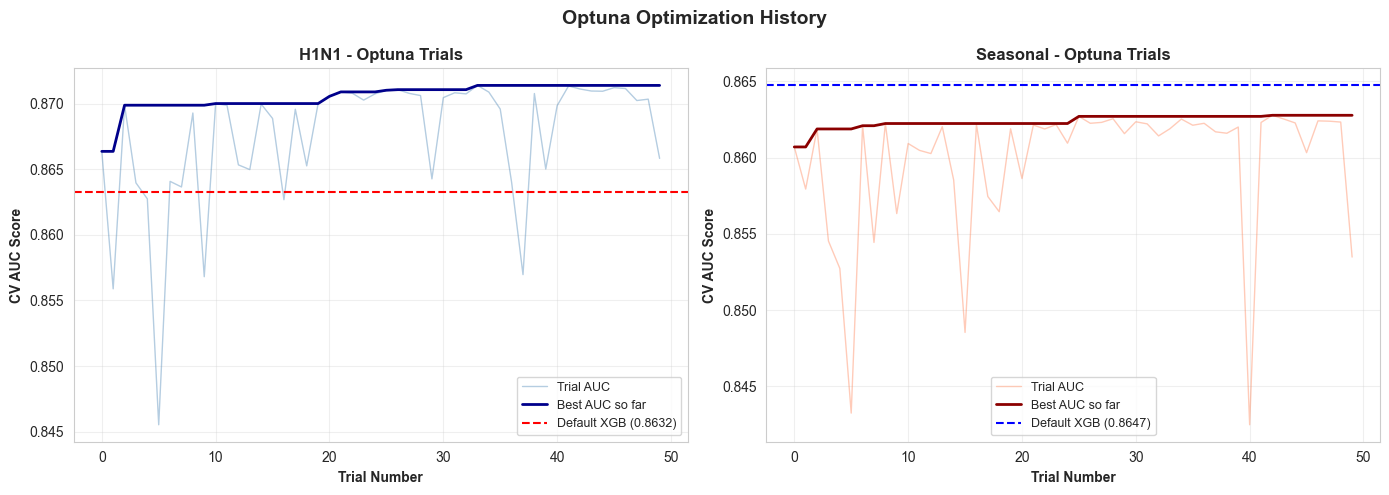


✅ Saved: EDA_plots/10_optuna_optimization_history.png


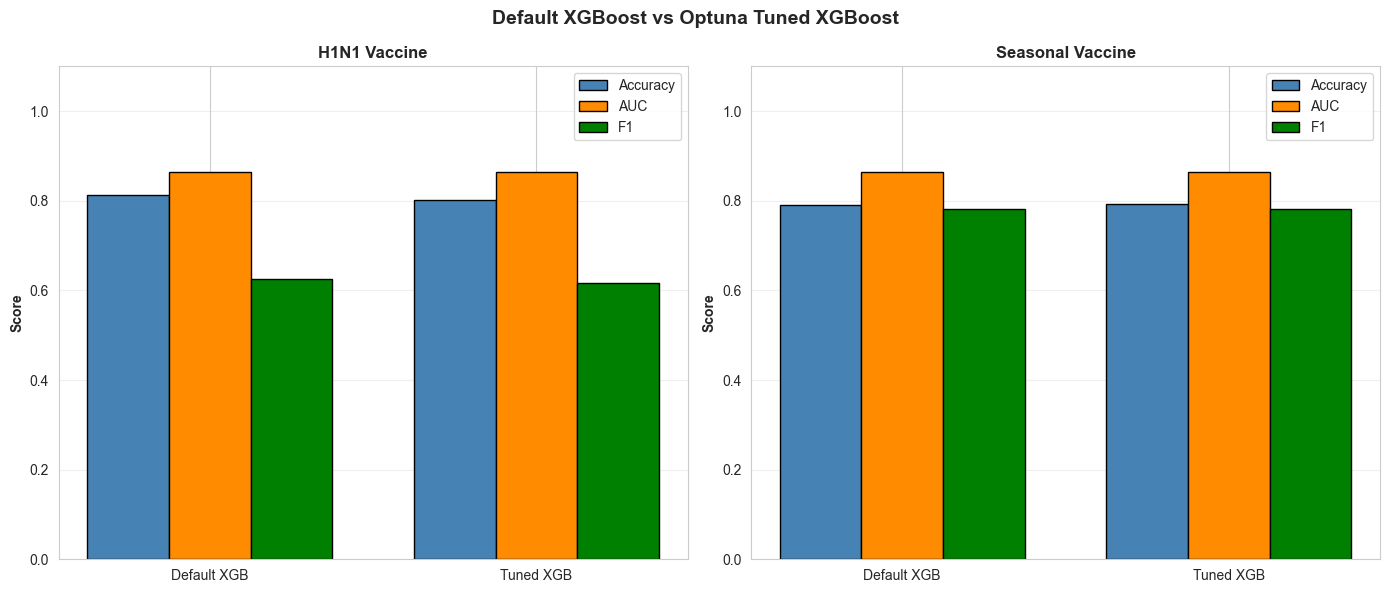

✅ Saved: EDA_plots/11_optuna_before_after.png


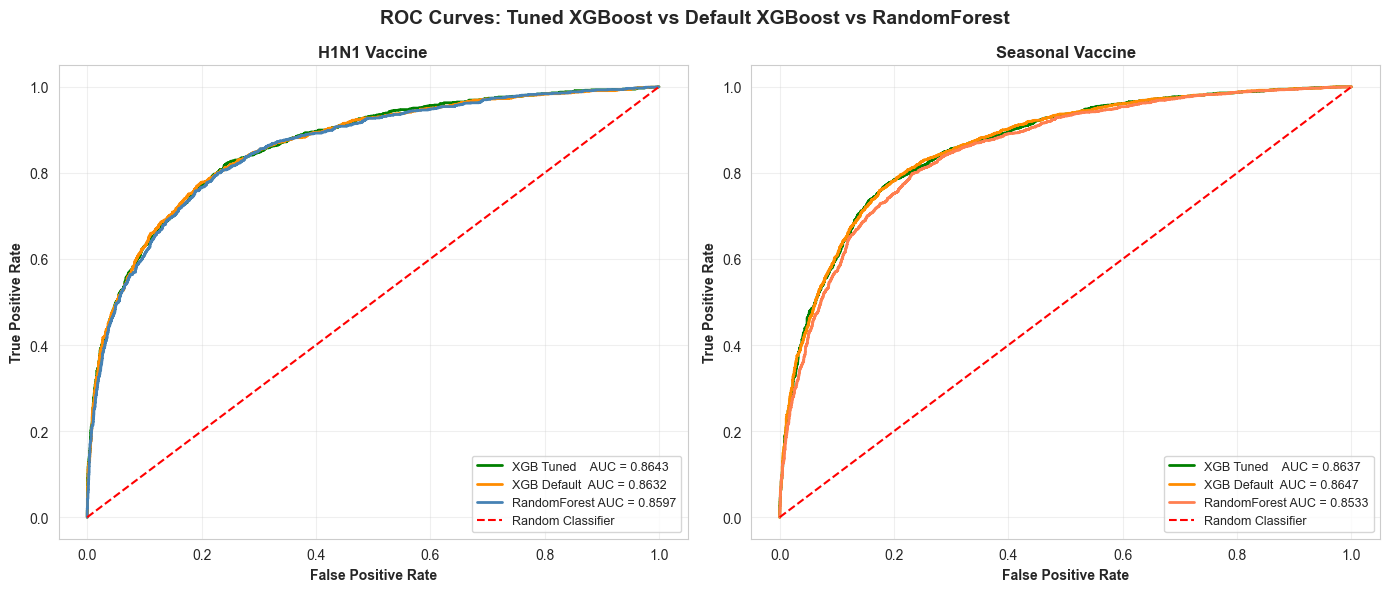

✅ Saved: EDA_plots/12_tuned_vs_default_roc.png

💾 Saved: EDA_plots/model_xgb_h1n1_tuned.pkl
💾 Saved: EDA_plots/model_xgb_seasonal_tuned.pkl
💾 Saved: EDA_plots/optuna_best_params.csv
💾 Saved: EDA_plots/optuna_before_after_comparison.csv

✅ OPTUNA TUNING COMPLETE!


In [114]:
# ============================================================================
# STEP 8D: OPTUNA HYPERPARAMETER TUNING FOR XGBOOST
# ============================================================================

print("\n" + "=" * 80)
print("STEP 8D: OPTUNA HYPERPARAMETER TUNING - XGBOOST")
print("=" * 80)

import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import StratifiedKFold, cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── H1N1 Optuna Study ────────────────────────────────────────────────────────

print(f"\n🔍 Starting Optuna search for H1N1 XGBoost...")
print(f"   This will run 50 trials — please wait...\n")

def objective_h1n1(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 800),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.4, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'gamma':             trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'scale_pos_weight':  (y_train_h1n1 == 0).sum() / (y_train_h1n1 == 1).sum(),
        'random_state':      42,
        'eval_metric':       'auc',
        'verbosity':         0,
        'n_jobs':            -1,
    }

    model = XGBClassifier(**params)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train_h1n1, y_train_h1n1,
                             cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

study_h1n1 = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42),
    study_name='xgb_h1n1_tuning'
)

study_h1n1.optimize(objective_h1n1, n_trials=50, show_progress_bar=True)

print(f"\n✅ H1N1 Optuna Search Complete!")
print(f"   Best CV AUC:  {study_h1n1.best_value:.4f}")
print(f"   Best Params:")
for k, v in study_h1n1.best_params.items():
    print(f"      {k}: {v}")

# ── Seasonal Optuna Study ─────────────────────────────────────────────────────

print(f"\n🔍 Starting Optuna search for Seasonal XGBoost...")
print(f"   This will run 50 trials — please wait...\n")

def objective_seasonal(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 800),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.4, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'gamma':             trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'scale_pos_weight':  (y_train_seasonal == 0).sum() / (y_train_seasonal == 1).sum(),
        'random_state':      42,
        'eval_metric':       'auc',
        'verbosity':         0,
        'n_jobs':            -1,
    }

    model = XGBClassifier(**params)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train_seasonal, y_train_seasonal,
                             cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

study_seasonal = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42),
    study_name='xgb_seasonal_tuning'
)

study_seasonal.optimize(objective_seasonal, n_trials=50, show_progress_bar=True)

print(f"\n✅ Seasonal Optuna Search Complete!")
print(f"   Best CV AUC:  {study_seasonal.best_value:.4f}")
print(f"   Best Params:")
for k, v in study_seasonal.best_params.items():
    print(f"      {k}: {v}")

# ── Retrain with Best Params ──────────────────────────────────────────────────

print(f"\n" + "=" * 60)
print(f"🏋️  RETRAINING WITH BEST OPTUNA PARAMS")
print(f"=" * 60)

# H1N1 tuned model
print(f"\n🤖 Retraining H1N1 XGBoost with best params...")

xgb_h1n1_tuned = XGBClassifier(
    **study_h1n1.best_params,
    scale_pos_weight=(y_train_h1n1 == 0).sum() / (y_train_h1n1 == 1).sum(),
    random_state=42,
    eval_metric='auc',
    verbosity=0,
    n_jobs=-1
)

xgb_h1n1_tuned.fit(
    X_train_h1n1, y_train_h1n1,
    eval_set=[(X_test_h1n1, y_test_h1n1)],
    verbose=False
)
print(f"✅ H1N1 tuned model trained!")

# Seasonal tuned model
print(f"\n🤖 Retraining Seasonal XGBoost with best params...")

xgb_seasonal_tuned = XGBClassifier(
    **study_seasonal.best_params,
    scale_pos_weight=(y_train_seasonal == 0).sum() / (y_train_seasonal == 1).sum(),
    random_state=42,
    eval_metric='auc',
    verbosity=0,
    n_jobs=-1
)

xgb_seasonal_tuned.fit(
    X_train_seasonal, y_train_seasonal,
    eval_set=[(X_test_seasonal, y_test_seasonal)],
    verbose=False
)
print(f"✅ Seasonal tuned model trained!")

# ── Evaluate Tuned Models ─────────────────────────────────────────────────────

print(f"\n" + "=" * 60)
print(f"📊 TUNED MODEL EVALUATION")
print(f"=" * 60)

# H1N1 metrics
y_pred_train_tuned_h1n1       = xgb_h1n1_tuned.predict(X_train_h1n1)
y_pred_test_tuned_h1n1        = xgb_h1n1_tuned.predict(X_test_h1n1)
y_pred_proba_train_tuned_h1n1 = xgb_h1n1_tuned.predict_proba(X_train_h1n1)[:, 1]
y_pred_proba_test_tuned_h1n1  = xgb_h1n1_tuned.predict_proba(X_test_h1n1)[:, 1]

train_acc_tuned_h1n1 = accuracy_score(y_train_h1n1, y_pred_train_tuned_h1n1)
test_acc_tuned_h1n1  = accuracy_score(y_test_h1n1,  y_pred_test_tuned_h1n1)
train_auc_tuned_h1n1 = roc_auc_score(y_train_h1n1,  y_pred_proba_train_tuned_h1n1)
test_auc_tuned_h1n1  = roc_auc_score(y_test_h1n1,   y_pred_proba_test_tuned_h1n1)
train_f1_tuned_h1n1  = f1_score(y_train_h1n1, y_pred_train_tuned_h1n1)
test_f1_tuned_h1n1   = f1_score(y_test_h1n1,  y_pred_test_tuned_h1n1)
cm_tuned_h1n1        = confusion_matrix(y_test_h1n1, y_pred_test_tuned_h1n1)

# Seasonal metrics
y_pred_train_tuned_seasonal       = xgb_seasonal_tuned.predict(X_train_seasonal)
y_pred_test_tuned_seasonal        = xgb_seasonal_tuned.predict(X_test_seasonal)
y_pred_proba_train_tuned_seasonal = xgb_seasonal_tuned.predict_proba(X_train_seasonal)[:, 1]
y_pred_proba_test_tuned_seasonal  = xgb_seasonal_tuned.predict_proba(X_test_seasonal)[:, 1]

train_acc_tuned_seasonal = accuracy_score(y_train_seasonal, y_pred_train_tuned_seasonal)
test_acc_tuned_seasonal  = accuracy_score(y_test_seasonal,  y_pred_test_tuned_seasonal)
train_auc_tuned_seasonal = roc_auc_score(y_train_seasonal,  y_pred_proba_train_tuned_seasonal)
test_auc_tuned_seasonal  = roc_auc_score(y_test_seasonal,   y_pred_proba_test_tuned_seasonal)
train_f1_tuned_seasonal  = f1_score(y_train_seasonal, y_pred_train_tuned_seasonal)
test_f1_tuned_seasonal   = f1_score(y_test_seasonal,  y_pred_test_tuned_seasonal)
cm_tuned_seasonal        = confusion_matrix(y_test_seasonal, y_pred_test_tuned_seasonal)

# ── Before vs After Comparison ────────────────────────────────────────────────

print(f"\n{'='*65}")
print(f"📊 BEFORE vs AFTER OPTUNA TUNING")
print(f"{'='*65}")

before_after_df = pd.DataFrame({
    'Model':         ['XGB Default', 'XGB Default', 'XGB Tuned', 'XGB Tuned'],
    'Target':        ['H1N1',        'Seasonal',    'H1N1',      'Seasonal'],
    'Test_Accuracy': [test_acc_xgb_h1n1,   test_acc_xgb_seasonal,
                      test_acc_tuned_h1n1,  test_acc_tuned_seasonal],
    'Test_AUC':      [test_auc_xgb_h1n1,   test_auc_xgb_seasonal,
                      test_auc_tuned_h1n1,  test_auc_tuned_seasonal],
    'Test_F1':       [test_f1_xgb_h1n1,    test_f1_xgb_seasonal,
                      test_f1_tuned_h1n1,   test_f1_tuned_seasonal],
})
print(before_after_df.to_string(index=False))

# AUC improvement
h1n1_auc_gain     = test_auc_tuned_h1n1     - test_auc_xgb_h1n1
seasonal_auc_gain = test_auc_tuned_seasonal  - test_auc_xgb_seasonal

print(f"\n🎯 AUC IMPROVEMENT:")
print(f"   H1N1:     {test_auc_xgb_h1n1:.4f} → {test_auc_tuned_h1n1:.4f}  "
      f"({'▲ +' if h1n1_auc_gain >= 0 else '▼ '}{abs(h1n1_auc_gain):.4f})")
print(f"   Seasonal: {test_auc_xgb_seasonal:.4f} → {test_auc_tuned_seasonal:.4f}  "
      f"({'▲ +' if seasonal_auc_gain >= 0 else '▼ '}{abs(seasonal_auc_gain):.4f})")

print(f"\n🔍 Tuned H1N1 Classification Report:")
print(classification_report(y_test_h1n1, y_pred_test_tuned_h1n1))

print(f"\n🔍 Tuned Seasonal Classification Report:")
print(classification_report(y_test_seasonal, y_pred_test_tuned_seasonal))

# ── Visualizations ────────────────────────────────────────────────────────────

# Figure 1: Optuna Optimization History
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Optuna Optimization History', fontsize=14, fontweight='bold')

# H1N1 trial history
h1n1_trial_values = [t.value for t in study_h1n1.trials]
axes[0].plot(h1n1_trial_values, color='steelblue', alpha=0.4, linewidth=1, label='Trial AUC')
axes[0].plot(pd.Series(h1n1_trial_values).cummax(), color='darkblue',
             linewidth=2, label='Best AUC so far')
axes[0].axhline(y=test_auc_xgb_h1n1, color='red', linestyle='--',
                linewidth=1.5, label=f'Default XGB ({test_auc_xgb_h1n1:.4f})')
axes[0].set_xlabel('Trial Number', fontweight='bold')
axes[0].set_ylabel('CV AUC Score', fontweight='bold')
axes[0].set_title('H1N1 - Optuna Trials', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Seasonal trial history
seasonal_trial_values = [t.value for t in study_seasonal.trials]
axes[1].plot(seasonal_trial_values, color='coral', alpha=0.4, linewidth=1, label='Trial AUC')
axes[1].plot(pd.Series(seasonal_trial_values).cummax(), color='darkred',
             linewidth=2, label='Best AUC so far')
axes[1].axhline(y=test_auc_xgb_seasonal, color='blue', linestyle='--',
                linewidth=1.5, label=f'Default XGB ({test_auc_xgb_seasonal:.4f})')
axes[1].set_xlabel('Trial Number', fontweight='bold')
axes[1].set_ylabel('CV AUC Score', fontweight='bold')
axes[1].set_title('Seasonal - Optuna Trials', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('EDA_plots/10_optuna_optimization_history.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✅ Saved: EDA_plots/10_optuna_optimization_history.png")

# Figure 2: Before vs After AUC Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Default XGBoost vs Optuna Tuned XGBoost', fontsize=14, fontweight='bold')

models_   = ['Default XGB', 'Tuned XGB']
x         = np.arange(len(models_))
width     = 0.25

for ax, target, accs, aucs, f1s, title in zip(
    axes,
    ['H1N1', 'Seasonal'],
    [[test_acc_xgb_h1n1,  test_acc_tuned_h1n1],
     [test_acc_xgb_seasonal, test_acc_tuned_seasonal]],
    [[test_auc_xgb_h1n1,  test_auc_tuned_h1n1],
     [test_auc_xgb_seasonal, test_auc_tuned_seasonal]],
    [[test_f1_xgb_h1n1,   test_f1_tuned_h1n1],
     [test_f1_xgb_seasonal,  test_f1_tuned_seasonal]],
    ['H1N1 Vaccine', 'Seasonal Vaccine']
):
    ax.bar(x - width, accs, width, label='Accuracy', color='steelblue',  edgecolor='black')
    ax.bar(x,         aucs, width, label='AUC',      color='darkorange', edgecolor='black')
    ax.bar(x + width, f1s,  width, label='F1',       color='green',      edgecolor='black')
    ax.set_ylabel('Score', fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models_)
    ax.legend()
    ax.set_ylim([0, 1.1])
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('EDA_plots/11_optuna_before_after.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: EDA_plots/11_optuna_before_after.png")

# Figure 3: ROC Curves - Default vs Tuned vs RF
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('ROC Curves: Tuned XGBoost vs Default XGBoost vs RandomForest',
             fontsize=14, fontweight='bold')

fpr_tuned_h1n1, tpr_tuned_h1n1, _         = roc_curve(y_test_h1n1, y_pred_proba_test_tuned_h1n1)
fpr_tuned_seasonal, tpr_tuned_seasonal, _  = roc_curve(y_test_seasonal, y_pred_proba_test_tuned_seasonal)

axes[0].plot(fpr_tuned_h1n1, tpr_tuned_h1n1, color='green',      linewidth=2,
             label=f'XGB Tuned    AUC = {test_auc_tuned_h1n1:.4f}')
axes[0].plot(fpr_xgb_h1n1,   tpr_xgb_h1n1,   color='darkorange', linewidth=2,
             label=f'XGB Default  AUC = {test_auc_xgb_h1n1:.4f}')
axes[0].plot(fpr_h1n1,        tpr_h1n1,        color='steelblue',  linewidth=2,
             label=f'RandomForest AUC = {test_auc_h1n1:.4f}')
axes[0].plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Random Classifier')
axes[0].set_xlabel('False Positive Rate', fontweight='bold')
axes[0].set_ylabel('True Positive Rate', fontweight='bold')
axes[0].set_title('H1N1 Vaccine', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(fpr_tuned_seasonal, tpr_tuned_seasonal, color='green',      linewidth=2,
             label=f'XGB Tuned    AUC = {test_auc_tuned_seasonal:.4f}')
axes[1].plot(fpr_xgb_seasonal,   tpr_xgb_seasonal,   color='darkorange', linewidth=2,
             label=f'XGB Default  AUC = {test_auc_xgb_seasonal:.4f}')
axes[1].plot(fpr_seasonal,        tpr_seasonal,        color='coral',      linewidth=2,
             label=f'RandomForest AUC = {test_auc_seasonal:.4f}')
axes[1].plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate', fontweight='bold')
axes[1].set_ylabel('True Positive Rate', fontweight='bold')
axes[1].set_title('Seasonal Vaccine', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('EDA_plots/12_tuned_vs_default_roc.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: EDA_plots/12_tuned_vs_default_roc.png")

# ── Save Tuned Models & Results ───────────────────────────────────────────────

with open('EDA_plots/model_xgb_h1n1_tuned.pkl', 'wb') as f:
    pickle.dump(xgb_h1n1_tuned, f)

with open('EDA_plots/model_xgb_seasonal_tuned.pkl', 'wb') as f:
    pickle.dump(xgb_seasonal_tuned, f)

# Save best params
best_params_df = pd.DataFrame([
    {'Target': 'H1N1',     **study_h1n1.best_params,     'best_cv_auc': study_h1n1.best_value},
    {'Target': 'Seasonal', **study_seasonal.best_params, 'best_cv_auc': study_seasonal.best_value},
])
best_params_df.to_csv('EDA_plots/optuna_best_params.csv', index=False)

before_after_df.to_csv('EDA_plots/optuna_before_after_comparison.csv', index=False)

print(f"\n💾 Saved: EDA_plots/model_xgb_h1n1_tuned.pkl")
print(f"💾 Saved: EDA_plots/model_xgb_seasonal_tuned.pkl")
print(f"💾 Saved: EDA_plots/optuna_best_params.csv")
print(f"💾 Saved: EDA_plots/optuna_before_after_comparison.csv")
print(f"\n✅ OPTUNA TUNING COMPLETE!")


STEP 8C: CATBOOST MODELS - H1N1 & SEASONAL VACCINE

🤖 Training CatBoost for H1N1 Vaccine...
✅ CatBoost H1N1 model trained!

📊 CATBOOST H1N1 MODEL PERFORMANCE:
   Training Accuracy: 0.8297
   Test Accuracy:     0.8006
   Training AUC:      0.9052
   Test AUC:          0.8627
   Training F1:       0.6708
   Test F1:           0.6109

🔍 CatBoost H1N1 Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.92      0.82      0.87      4207
           1       0.52      0.74      0.61      1135

    accuracy                           0.80      5342
   macro avg       0.72      0.78      0.74      5342
weighted avg       0.84      0.80      0.81      5342


📊 CatBoost H1N1 Confusion Matrix (Test Set):
[[3441  766]
 [ 299  836]]

🤖 Training CatBoost for Seasonal Vaccine...
✅ CatBoost Seasonal model trained!

📊 CATBOOST SEASONAL MODEL PERFORMANCE:
   Training Accuracy: 0.8151
   Test Accuracy:     0.7935
   Training AUC:      0.8953
   Test 

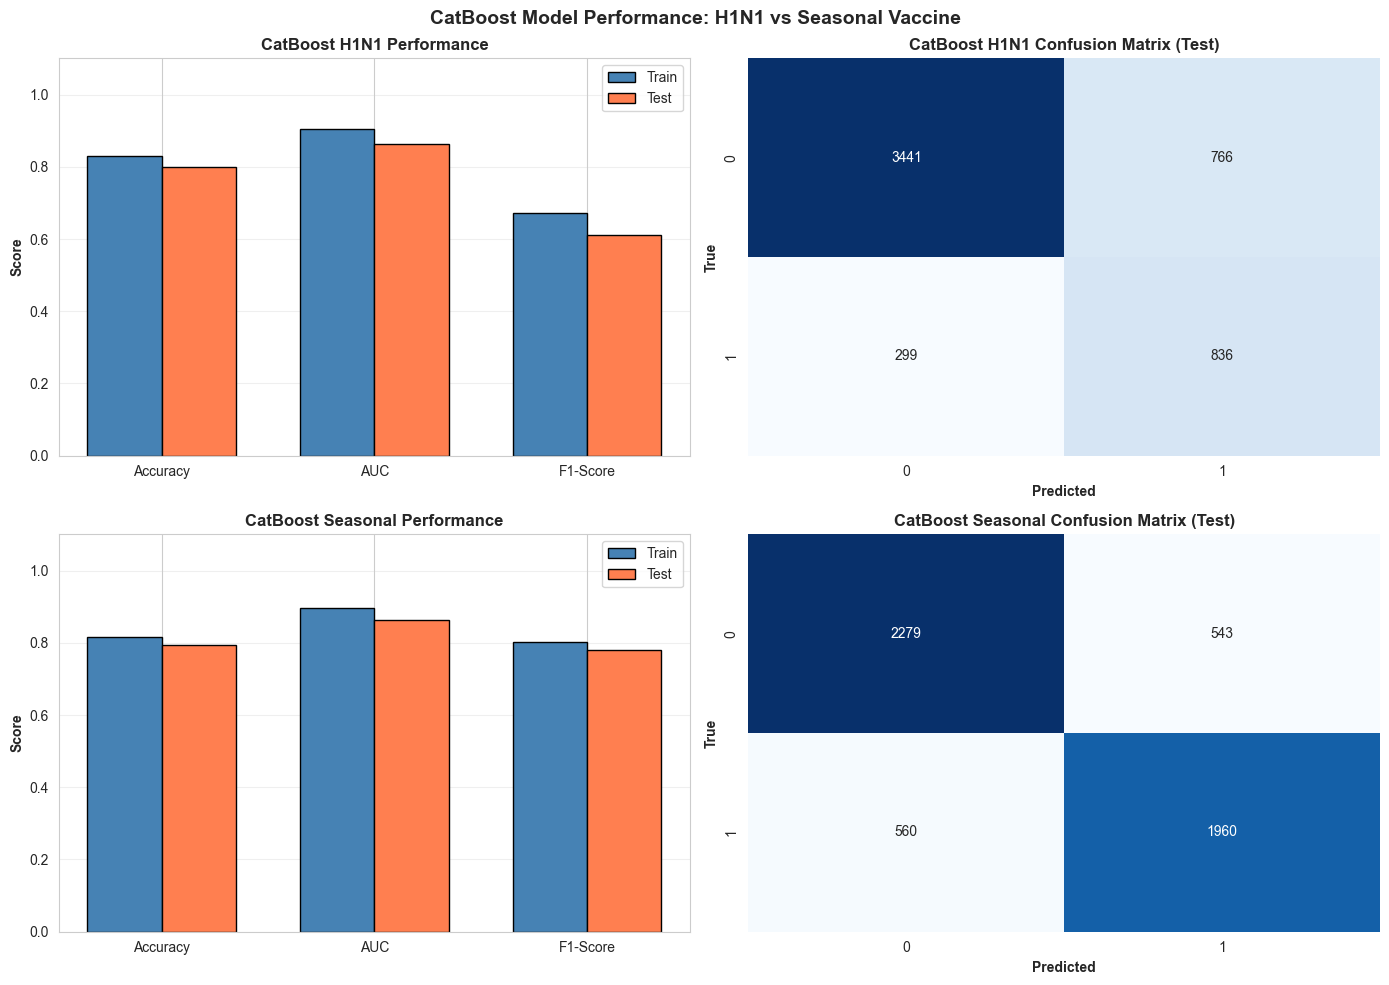


✅ Saved: EDA_plots/07_catboost_performance.png


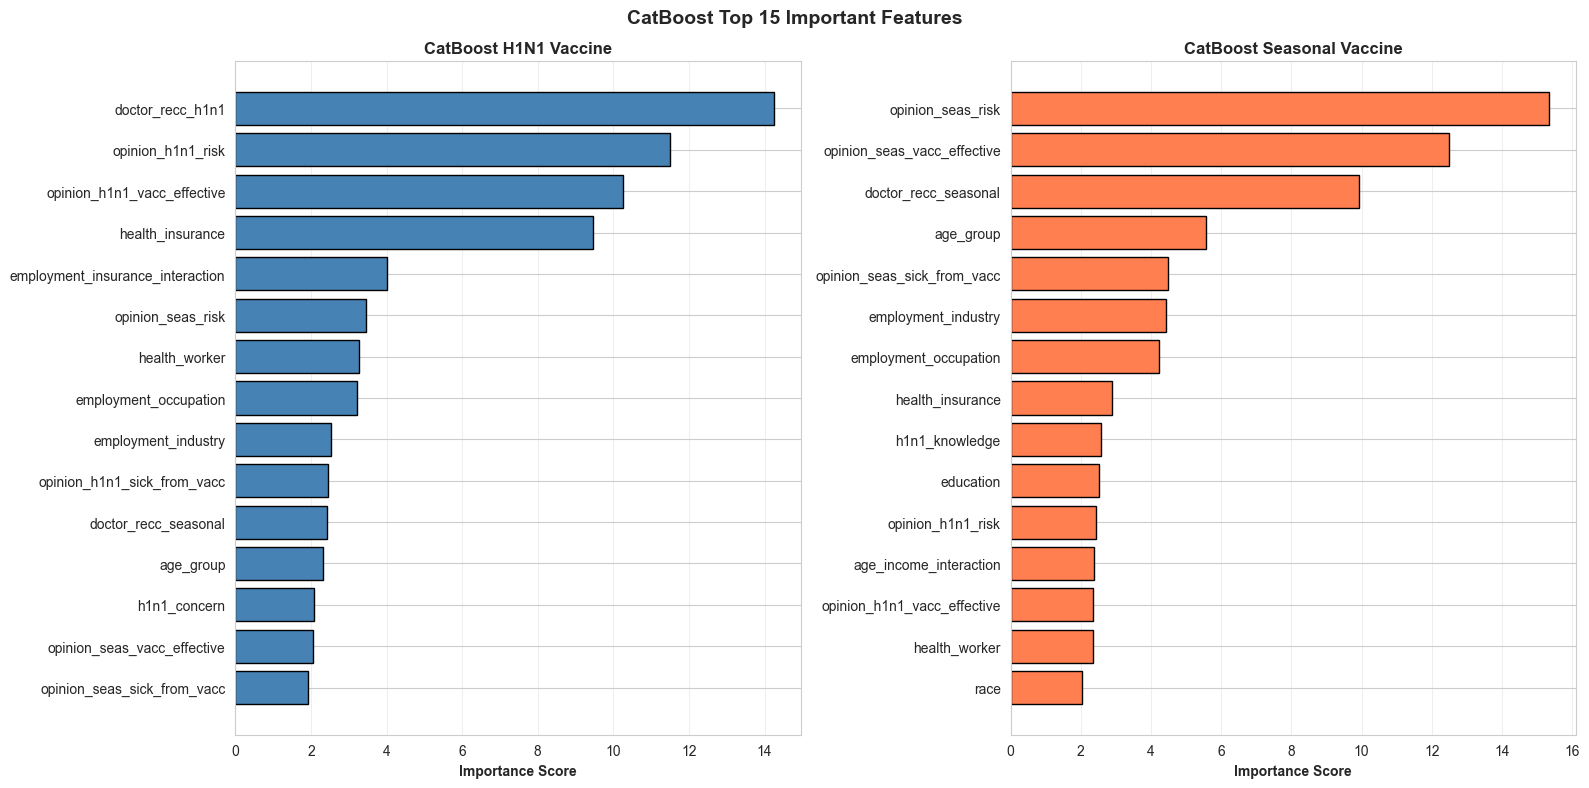

✅ Saved: EDA_plots/08_catboost_feature_importance.png


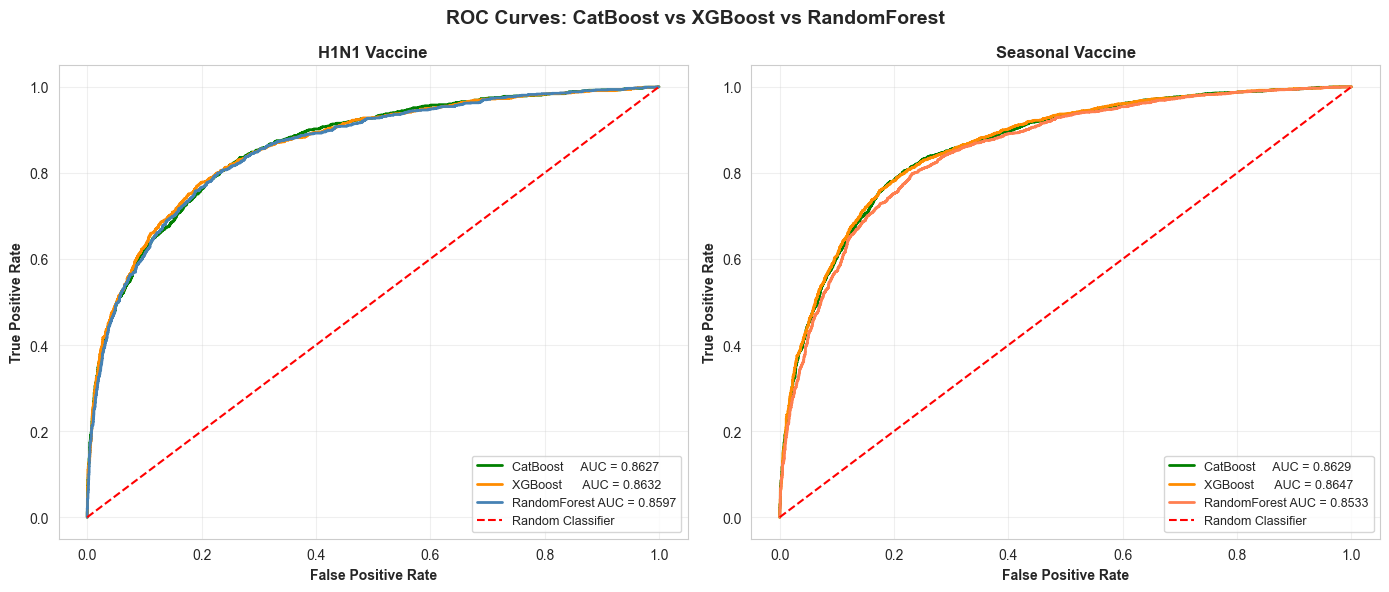

✅ Saved: EDA_plots/09_all_models_roc_comparison.png

📊 FINAL 3-MODEL COMPARISON TABLE
       Model   Target  Test_Accuracy  Test_AUC  Test_F1
RandomForest     H1N1       0.833770  0.859748 0.623090
RandomForest Seasonal       0.777611  0.853331 0.763723
     XGBoost     H1N1       0.813927  0.863248 0.624906
     XGBoost Seasonal       0.791464  0.864731 0.780536
    CatBoost     H1N1       0.800636  0.862749 0.610888
    CatBoost Seasonal       0.793523  0.862867 0.780410

💾 Saved: EDA_plots/full_model_comparison.csv

💾 Saved: EDA_plots/model_cat_h1n1.pkl
💾 Saved: EDA_plots/model_cat_seasonal.pkl
💾 Saved: EDA_plots/feature_importance_cat_h1n1.csv
💾 Saved: EDA_plots/feature_importance_cat_seasonal.csv

✅ CATBOOST TRAINING COMPLETE!


In [115]:
# ============================================================================
# STEP 8C: MODEL 5 & 6 - CATBOOST FOR H1N1 AND SEASONAL VACCINE
# ============================================================================

print("\n" + "=" * 80)
print("STEP 8C: CATBOOST MODELS - H1N1 & SEASONAL VACCINE")
print("=" * 80)

from catboost import CatBoostClassifier

# ── H1N1 CatBoost ────────────────────────────────────────────────────────────

print(f"\n🤖 Training CatBoost for H1N1 Vaccine...")

cat_h1n1 = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    l2_leaf_reg=3,
    auto_class_weights='Balanced',
    random_seed=42,
    eval_metric='AUC',
    verbose=0
)

cat_h1n1.fit(
    X_train_h1n1, y_train_h1n1,
    eval_set=(X_test_h1n1, y_test_h1n1),
    early_stopping_rounds=50,
    verbose=False
)
print(f"✅ CatBoost H1N1 model trained!")

# Predictions
y_pred_train_cat_h1n1       = cat_h1n1.predict(X_train_h1n1)
y_pred_test_cat_h1n1        = cat_h1n1.predict(X_test_h1n1)
y_pred_proba_train_cat_h1n1 = cat_h1n1.predict_proba(X_train_h1n1)[:, 1]
y_pred_proba_test_cat_h1n1  = cat_h1n1.predict_proba(X_test_h1n1)[:, 1]

# Metrics
train_acc_cat_h1n1 = accuracy_score(y_train_h1n1, y_pred_train_cat_h1n1)
test_acc_cat_h1n1  = accuracy_score(y_test_h1n1,  y_pred_test_cat_h1n1)
train_auc_cat_h1n1 = roc_auc_score(y_train_h1n1,  y_pred_proba_train_cat_h1n1)
test_auc_cat_h1n1  = roc_auc_score(y_test_h1n1,   y_pred_proba_test_cat_h1n1)
train_f1_cat_h1n1  = f1_score(y_train_h1n1, y_pred_train_cat_h1n1)
test_f1_cat_h1n1   = f1_score(y_test_h1n1,  y_pred_test_cat_h1n1)
cm_cat_h1n1        = confusion_matrix(y_test_h1n1, y_pred_test_cat_h1n1)

print(f"\n📊 CATBOOST H1N1 MODEL PERFORMANCE:")
print(f"   Training Accuracy: {train_acc_cat_h1n1:.4f}")
print(f"   Test Accuracy:     {test_acc_cat_h1n1:.4f}")
print(f"   Training AUC:      {train_auc_cat_h1n1:.4f}")
print(f"   Test AUC:          {test_auc_cat_h1n1:.4f}")
print(f"   Training F1:       {train_f1_cat_h1n1:.4f}")
print(f"   Test F1:           {test_f1_cat_h1n1:.4f}")

print(f"\n🔍 CatBoost H1N1 Classification Report (Test Set):")
print(classification_report(y_test_h1n1, y_pred_test_cat_h1n1))

print(f"\n📊 CatBoost H1N1 Confusion Matrix (Test Set):")
print(cm_cat_h1n1)

# ── Seasonal CatBoost ─────────────────────────────────────────────────────────

print(f"\n🤖 Training CatBoost for Seasonal Vaccine...")

cat_seasonal = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    l2_leaf_reg=3,
    auto_class_weights='Balanced',
    random_seed=42,
    eval_metric='AUC',
    verbose=0
)

cat_seasonal.fit(
    X_train_seasonal, y_train_seasonal,
    eval_set=(X_test_seasonal, y_test_seasonal),
    early_stopping_rounds=50,
    verbose=False
)
print(f"✅ CatBoost Seasonal model trained!")

# Predictions
y_pred_train_cat_seasonal       = cat_seasonal.predict(X_train_seasonal)
y_pred_test_cat_seasonal        = cat_seasonal.predict(X_test_seasonal)
y_pred_proba_train_cat_seasonal = cat_seasonal.predict_proba(X_train_seasonal)[:, 1]
y_pred_proba_test_cat_seasonal  = cat_seasonal.predict_proba(X_test_seasonal)[:, 1]

# Metrics
train_acc_cat_seasonal = accuracy_score(y_train_seasonal, y_pred_train_cat_seasonal)
test_acc_cat_seasonal  = accuracy_score(y_test_seasonal,  y_pred_test_cat_seasonal)
train_auc_cat_seasonal = roc_auc_score(y_train_seasonal,  y_pred_proba_train_cat_seasonal)
test_auc_cat_seasonal  = roc_auc_score(y_test_seasonal,   y_pred_proba_test_cat_seasonal)
train_f1_cat_seasonal  = f1_score(y_train_seasonal, y_pred_train_cat_seasonal)
test_f1_cat_seasonal   = f1_score(y_test_seasonal,  y_pred_test_cat_seasonal)
cm_cat_seasonal        = confusion_matrix(y_test_seasonal, y_pred_test_cat_seasonal)

print(f"\n📊 CATBOOST SEASONAL MODEL PERFORMANCE:")
print(f"   Training Accuracy: {train_acc_cat_seasonal:.4f}")
print(f"   Test Accuracy:     {test_acc_cat_seasonal:.4f}")
print(f"   Training AUC:      {train_auc_cat_seasonal:.4f}")
print(f"   Test AUC:          {test_auc_cat_seasonal:.4f}")
print(f"   Training F1:       {train_f1_cat_seasonal:.4f}")
print(f"   Test F1:           {test_f1_cat_seasonal:.4f}")

print(f"\n🔍 CatBoost Seasonal Classification Report (Test Set):")
print(classification_report(y_test_seasonal, y_pred_test_cat_seasonal))

print(f"\n📊 CatBoost Seasonal Confusion Matrix (Test Set):")
print(cm_cat_seasonal)

# ── Overfitting Check ────────────────────────────────────────────────────────

print(f"\n⚠️  CATBOOST OVERFITTING ANALYSIS:")

cat_h1n1_acc_diff     = train_acc_cat_h1n1 - test_acc_cat_h1n1
cat_h1n1_auc_diff     = train_auc_cat_h1n1 - test_auc_cat_h1n1
cat_seasonal_acc_diff = train_acc_cat_seasonal - test_acc_cat_seasonal
cat_seasonal_auc_diff = train_auc_cat_seasonal - test_auc_cat_seasonal

print(f"\n   H1N1:")
print(f"   Accuracy difference (Train - Test): {cat_h1n1_acc_diff:.4f}  "
      f"{'✅ Good' if cat_h1n1_acc_diff <= 0.15 else '⚠️ Possible Overfitting'}")
print(f"   AUC difference (Train - Test):      {cat_h1n1_auc_diff:.4f}")

print(f"\n   Seasonal:")
print(f"   Accuracy difference (Train - Test): {cat_seasonal_acc_diff:.4f}  "
      f"{'✅ Good' if cat_seasonal_acc_diff <= 0.15 else '⚠️ Possible Overfitting'}")
print(f"   AUC difference (Train - Test):      {cat_seasonal_auc_diff:.4f}")

# ── Feature Importance ───────────────────────────────────────────────────────

feature_importance_cat_h1n1 = pd.DataFrame({
    'Feature':    feature_cols,
    'Importance': cat_h1n1.get_feature_importance()
}).sort_values('Importance', ascending=False)

feature_importance_cat_seasonal = pd.DataFrame({
    'Feature':    feature_cols,
    'Importance': cat_seasonal.get_feature_importance()
}).sort_values('Importance', ascending=False)

print(f"\n📈 Top 15 Important Features - CatBoost H1N1:")
print(feature_importance_cat_h1n1.head(15).to_string(index=False))

print(f"\n📈 Top 15 Important Features - CatBoost Seasonal:")
print(feature_importance_cat_seasonal.head(15).to_string(index=False))

# ── Visualizations ───────────────────────────────────────────────────────────

# Figure: CatBoost Performance + Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('CatBoost Model Performance: H1N1 vs Seasonal Vaccine', fontsize=14, fontweight='bold')

metrics_labels = ['Accuracy', 'AUC', 'F1-Score']
x = np.arange(len(metrics_labels))
width = 0.35

# H1N1 bar chart
axes[0, 0].bar(x - width/2, [train_acc_cat_h1n1, train_auc_cat_h1n1, train_f1_cat_h1n1],
               width, label='Train', color='steelblue', edgecolor='black')
axes[0, 0].bar(x + width/2, [test_acc_cat_h1n1, test_auc_cat_h1n1, test_f1_cat_h1n1],
               width, label='Test', color='coral', edgecolor='black')
axes[0, 0].set_ylabel('Score', fontweight='bold')
axes[0, 0].set_title('CatBoost H1N1 Performance', fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(metrics_labels)
axes[0, 0].legend()
axes[0, 0].set_ylim([0, 1.1])
axes[0, 0].grid(axis='y', alpha=0.3)

# H1N1 confusion matrix
sns.heatmap(cm_cat_h1n1, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1], cbar=False)
axes[0, 1].set_title('CatBoost H1N1 Confusion Matrix (Test)', fontweight='bold')
axes[0, 1].set_ylabel('True', fontweight='bold')
axes[0, 1].set_xlabel('Predicted', fontweight='bold')

# Seasonal bar chart
axes[1, 0].bar(x - width/2, [train_acc_cat_seasonal, train_auc_cat_seasonal, train_f1_cat_seasonal],
               width, label='Train', color='steelblue', edgecolor='black')
axes[1, 0].bar(x + width/2, [test_acc_cat_seasonal, test_auc_cat_seasonal, test_f1_cat_seasonal],
               width, label='Test', color='coral', edgecolor='black')
axes[1, 0].set_ylabel('Score', fontweight='bold')
axes[1, 0].set_title('CatBoost Seasonal Performance', fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(metrics_labels)
axes[1, 0].legend()
axes[1, 0].set_ylim([0, 1.1])
axes[1, 0].grid(axis='y', alpha=0.3)

# Seasonal confusion matrix
sns.heatmap(cm_cat_seasonal, annot=True, fmt='d', cmap='Blues', ax=axes[1, 1], cbar=False)
axes[1, 1].set_title('CatBoost Seasonal Confusion Matrix (Test)', fontweight='bold')
axes[1, 1].set_ylabel('True', fontweight='bold')
axes[1, 1].set_xlabel('Predicted', fontweight='bold')

plt.tight_layout()
plt.savefig('EDA_plots/07_catboost_performance.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✅ Saved: EDA_plots/07_catboost_performance.png")

# Figure: CatBoost Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('CatBoost Top 15 Important Features', fontsize=14, fontweight='bold')

top_cat_h1n1 = feature_importance_cat_h1n1.head(15)
axes[0].barh(range(len(top_cat_h1n1)), top_cat_h1n1['Importance'], color='steelblue', edgecolor='black')
axes[0].set_yticks(range(len(top_cat_h1n1)))
axes[0].set_yticklabels(top_cat_h1n1['Feature'], fontsize=10)
axes[0].set_xlabel('Importance Score', fontweight='bold')
axes[0].set_title('CatBoost H1N1 Vaccine', fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

top_cat_seasonal = feature_importance_cat_seasonal.head(15)
axes[1].barh(range(len(top_cat_seasonal)), top_cat_seasonal['Importance'], color='coral', edgecolor='black')
axes[1].set_yticks(range(len(top_cat_seasonal)))
axes[1].set_yticklabels(top_cat_seasonal['Feature'], fontsize=10)
axes[1].set_xlabel('Importance Score', fontweight='bold')
axes[1].set_title('CatBoost Seasonal Vaccine', fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('EDA_plots/08_catboost_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: EDA_plots/08_catboost_feature_importance.png")

# Figure: ROC Curves - All 3 Models Compared
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('ROC Curves: CatBoost vs XGBoost vs RandomForest', fontsize=14, fontweight='bold')

# H1N1
fpr_cat_h1n1, tpr_cat_h1n1, _ = roc_curve(y_test_h1n1, y_pred_proba_test_cat_h1n1)
axes[0].plot(fpr_cat_h1n1,    tpr_cat_h1n1,    color='green',      linewidth=2,
             label=f'CatBoost     AUC = {test_auc_cat_h1n1:.4f}')
axes[0].plot(fpr_xgb_h1n1,   tpr_xgb_h1n1,   color='darkorange',  linewidth=2,
             label=f'XGBoost      AUC = {test_auc_xgb_h1n1:.4f}')
axes[0].plot(fpr_h1n1,        tpr_h1n1,        color='steelblue',   linewidth=2,
             label=f'RandomForest AUC = {test_auc_h1n1:.4f}')
axes[0].plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Random Classifier')
axes[0].set_xlabel('False Positive Rate', fontweight='bold')
axes[0].set_ylabel('True Positive Rate', fontweight='bold')
axes[0].set_title('H1N1 Vaccine', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Seasonal
fpr_cat_seasonal, tpr_cat_seasonal, _ = roc_curve(y_test_seasonal, y_pred_proba_test_cat_seasonal)
axes[1].plot(fpr_cat_seasonal,    tpr_cat_seasonal,    color='green',      linewidth=2,
             label=f'CatBoost     AUC = {test_auc_cat_seasonal:.4f}')
axes[1].plot(fpr_xgb_seasonal,   tpr_xgb_seasonal,   color='darkorange',  linewidth=2,
             label=f'XGBoost      AUC = {test_auc_xgb_seasonal:.4f}')
axes[1].plot(fpr_seasonal,        tpr_seasonal,        color='coral',       linewidth=2,
             label=f'RandomForest AUC = {test_auc_seasonal:.4f}')
axes[1].plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate', fontweight='bold')
axes[1].set_ylabel('True Positive Rate', fontweight='bold')
axes[1].set_title('Seasonal Vaccine', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('EDA_plots/09_all_models_roc_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: EDA_plots/09_all_models_roc_comparison.png")

# ── Full 3-Model Comparison Table ────────────────────────────────────────────

print(f"\n{'='*70}")
print(f"📊 FINAL 3-MODEL COMPARISON TABLE")
print(f"{'='*70}")

full_comparison_df = pd.DataFrame({
    'Model':         ['RandomForest', 'RandomForest', 'XGBoost',      'XGBoost',
                      'CatBoost',     'CatBoost'],
    'Target':        ['H1N1',         'Seasonal',     'H1N1',         'Seasonal',
                      'H1N1',         'Seasonal'],
    'Test_Accuracy': [test_acc_h1n1,  test_acc_seasonal,  test_acc_xgb_h1n1,
                      test_acc_xgb_seasonal, test_acc_cat_h1n1, test_acc_cat_seasonal],
    'Test_AUC':      [test_auc_h1n1,  test_auc_seasonal,  test_auc_xgb_h1n1,
                      test_auc_xgb_seasonal, test_auc_cat_h1n1, test_auc_cat_seasonal],
    'Test_F1':       [test_f1_h1n1,   test_f1_seasonal,   test_f1_xgb_h1n1,
                      test_f1_xgb_seasonal,  test_f1_cat_h1n1,  test_f1_cat_seasonal],
})
print(full_comparison_df.to_string(index=False))

full_comparison_df.to_csv('EDA_plots/full_model_comparison.csv', index=False)
print(f"\n💾 Saved: EDA_plots/full_model_comparison.csv")

# ── Save CatBoost Models ──────────────────────────────────────────────────────

with open('EDA_plots/model_cat_h1n1.pkl', 'wb') as f:
    pickle.dump(cat_h1n1, f)

with open('EDA_plots/model_cat_seasonal.pkl', 'wb') as f:
    pickle.dump(cat_seasonal, f)

feature_importance_cat_h1n1.to_csv('EDA_plots/feature_importance_cat_h1n1.csv', index=False)
feature_importance_cat_seasonal.to_csv('EDA_plots/feature_importance_cat_seasonal.csv', index=False)

print(f"\n💾 Saved: EDA_plots/model_cat_h1n1.pkl")
print(f"💾 Saved: EDA_plots/model_cat_seasonal.pkl")
print(f"💾 Saved: EDA_plots/feature_importance_cat_h1n1.csv")
print(f"💾 Saved: EDA_plots/feature_importance_cat_seasonal.csv")
print(f"\n✅ CATBOOST TRAINING COMPLETE!")

STEP 0: DEFINE REFERENCE COLUMNS FROM TRAIN-TEST DATASET

📋 TRAIN-TEST REFERENCE COLUMNS:
   Total columns: 38
   Target columns: 2
   Raw feature columns: 35
   Engineered columns: 9

✅ Reference columns defined

STEP 1: LOAD FINAL TEST DATASET (RAW DATA)

📊 Final Test Dataset Info:
   Shape: (26708, 36)
   Rows: 26,708
   Columns: 36

📋 Columns in final test data:
['respondent_id', 'h1n1_concern', 'h1n1_knowledge', 'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal', 'chronic_med_condition', 'child_under_6_months', 'health_worker', 'health_insurance', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk', 'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effective', 'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status', 'rent_or_own', 'emplo

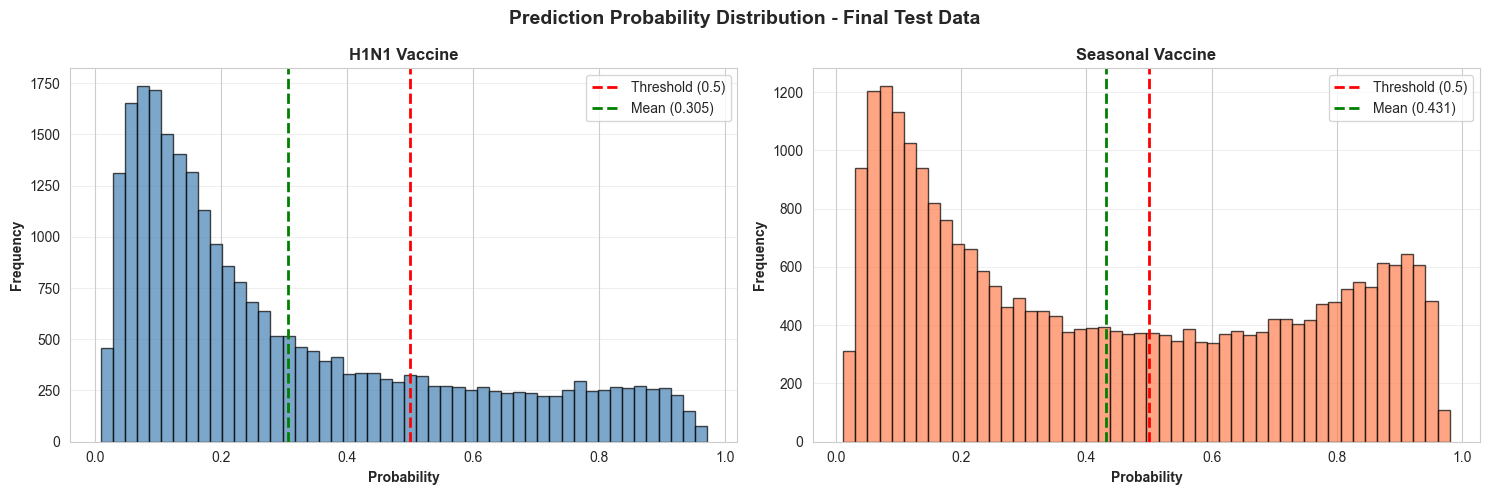


✅ Saved: EDA_plots/09_final_predictions_distribution.png


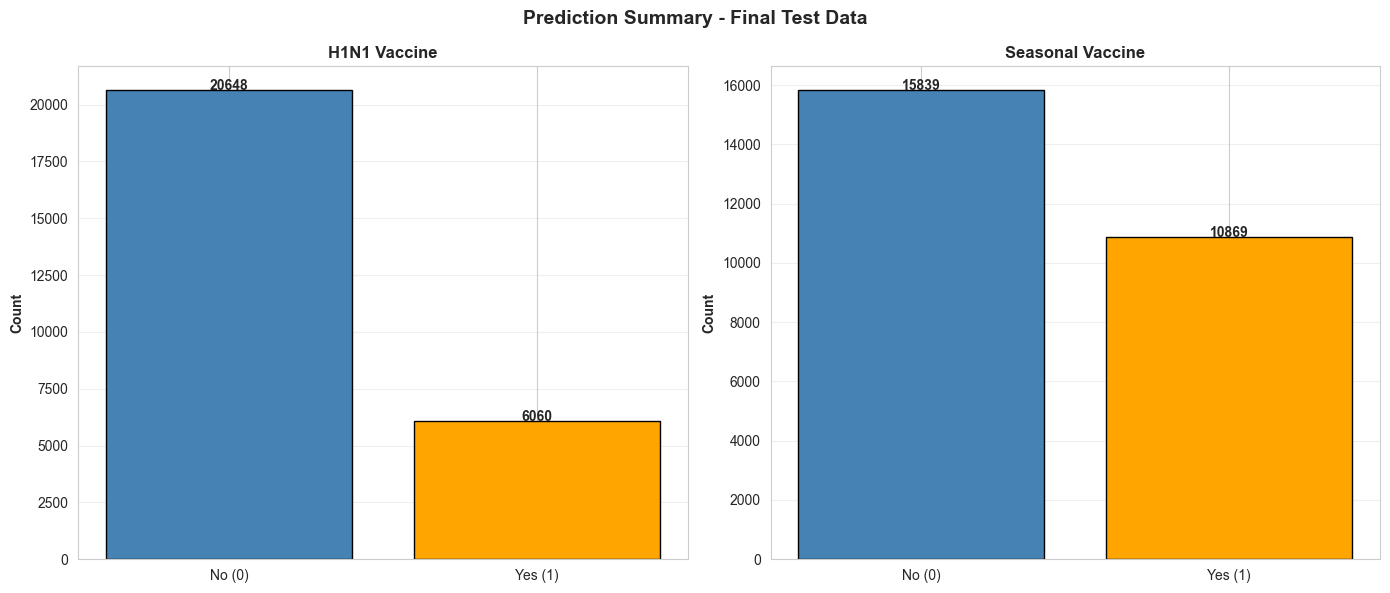

✅ Saved: EDA_plots/10_final_predictions_summary.png


In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import pickle
import warnings
warnings.filterwarnings('ignore')

os.makedirs('EDA_plots', exist_ok=True)

# ============================================================================
# STEP 0: DEFINE TRAIN-TEST COLUMNS (Reference)
# ============================================================================

print("=" * 80)
print("STEP 0: DEFINE REFERENCE COLUMNS FROM TRAIN-TEST DATASET")
print("=" * 80)

train_test_cols = ['respondent_id', 'h1n1_concern', 'h1n1_knowledge',
       'behavioral_antiviral_meds', 'behavioral_avoidance',
       'behavioral_face_mask', 'behavioral_wash_hands',
       'behavioral_large_gatherings', 'behavioral_outside_home',
       'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal',
       'chronic_med_condition', 'child_under_6_months', 'health_worker',
       'health_insurance', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk',
       'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effective',
       'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'age_group',
       'education', 'race', 'sex', 'income_poverty', 'marital_status',
       'rent_or_own', 'employment_status', 'hhs_geo_region', 'census_msa',
       'household_adults', 'household_children', 'employment_industry',
       'employment_occupation', 'h1n1_vaccine', 'seasonal_vaccine']

target_cols = ['h1n1_vaccine', 'seasonal_vaccine']
engineered_cols = ['behavioral_risk_score', 'opinion_concern_score', 
                  'doctor_recommendation_score', 'health_risk_profile',
                  'age_income_interaction', 'employment_insurance_interaction',
                  'household_size', 'has_children', 'overall_risk_level']

raw_feature_cols = [col for col in train_test_cols if col not in target_cols + ['respondent_id']]

print(f"\n📋 TRAIN-TEST REFERENCE COLUMNS:")
print(f"   Total columns: {len(train_test_cols)}")
print(f"   Target columns: {len(target_cols)}")
print(f"   Raw feature columns: {len(raw_feature_cols)}")
print(f"   Engineered columns: {len(engineered_cols)}")

print(f"\n✅ Reference columns defined")

# ============================================================================
# STEP 1: LOAD FINAL TEST DATASET (RAW - NO PREPROCESSING)
# ============================================================================

print("\n" + "=" * 80)
print("STEP 1: LOAD FINAL TEST DATASET (RAW DATA)")
print("=" * 80)

# LOAD YOUR FINAL TEST DATA HERE
final_test_df = pd.read_csv(r'C:\Users\divye\Data_science_projects\H1N1_seasonal_vaccines\data\test_set_features.csv')  # ← CHANGE THIS PATH

print(f"\n📊 Final Test Dataset Info:")
print(f"   Shape: {final_test_df.shape}")
print(f"   Rows: {final_test_df.shape[0]:,}")
print(f"   Columns: {final_test_df.shape[1]}")

print(f"\n📋 Columns in final test data:")
print(final_test_df.columns.tolist())

# ============================================================================
# STEP 2: VALIDATE COLUMNS - CHECK COMPATIBILITY
# ============================================================================

print("\n" + "=" * 80)
print("STEP 2: VALIDATE COLUMNS - CHECK COMPATIBILITY")
print("=" * 80)

# Get expected columns (without engineered and target columns)
expected_raw_cols = set(raw_feature_cols)
final_test_cols = set(final_test_df.columns)

# Check for missing columns
missing_cols = expected_raw_cols - final_test_cols
extra_cols = final_test_cols - expected_raw_cols - {'respondent_id'}

print(f"\n🔍 COLUMN VALIDATION:")

if missing_cols:
    print(f"\n❌ MISSING COLUMNS in final test data:")
    for col in sorted(missing_cols):
        print(f"   • {col}")
else:
    print(f"\n✅ All required columns present")

if extra_cols:
    print(f"\n⚠️  EXTRA COLUMNS in final test data (will be ignored):")
    for col in sorted(extra_cols):
        print(f"   • {col}")
else:
    print(f"\n✅ No extra columns")

# Verify match
if not missing_cols:
    print(f"\n✅ COLUMN VALIDATION PASSED - Data is compatible!")
else:
    print(f"\n❌ COLUMN VALIDATION FAILED - Missing {len(missing_cols)} columns")
    raise ValueError(f"Missing columns: {missing_cols}")

# ============================================================================
# STEP 3: SELECT AND REORDER COLUMNS TO MATCH TRAIN-TEST
# ============================================================================

print("\n" + "=" * 80)
print("STEP 3: SELECT AND REORDER COLUMNS")
print("=" * 80)

# Select only the raw feature columns that are in final test data
cols_to_select = ['respondent_id'] + [col for col in raw_feature_cols if col in final_test_df.columns]
final_test_df = final_test_df[cols_to_select].copy()

print(f"\n✅ Columns selected and reordered")
print(f"   Final shape: {final_test_df.shape}")

# ============================================================================
# STEP 4: HANDLE MISSING VALUES
# ============================================================================

print("\n" + "=" * 80)
print("STEP 4: HANDLE MISSING VALUES")
print("=" * 80)

df_final_processed = final_test_df.copy()

# Identify column types
numerical_cols = df_final_processed.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_final_processed.select_dtypes(include=['object']).columns.tolist()

numerical_cols = [col for col in numerical_cols if col != 'respondent_id']

print(f"\n📊 Column Types:")
print(f"   Numerical: {len(numerical_cols)}")
print(f"   Categorical: {len(categorical_cols)}")

# Check missing values
print(f"\n🔍 Missing Values Before Imputation:")
missing_summary = df_final_processed.isna().sum()
missing_percent = (missing_summary / len(df_final_processed)) * 100
missing_df = pd.DataFrame({
    'Column': missing_summary.index,
    'Missing_Count': missing_summary.values,
    'Missing_Percent': missing_percent.values
})
missing_df_sorted = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_df_sorted) > 0:
    print(missing_df_sorted.head(10).to_string(index=False))
else:
    print("   No missing values found")

# Impute numerical columns
if len(numerical_cols) > 0:
    print(f"\n🔧 Imputing {len(numerical_cols)} numerical columns...")
    
    imputer_final = IterativeImputer(
        max_iter=10,
        random_state=42,
        verbose=0
    )
    
    df_final_processed[numerical_cols] = imputer_final.fit_transform(
        df_final_processed[numerical_cols]
    )
    
    print(f"✅ Numerical imputation complete")

# Fill categorical columns with mode
if len(categorical_cols) > 0:
    print(f"\n🔄 Filling {len(categorical_cols)} categorical columns...")
    
    for col in categorical_cols:
        if col in df_final_processed.columns:
            mode_val = df_final_processed[col].mode()[0] if len(df_final_processed[col].mode()) > 0 else 'Unknown'
            df_final_processed[col].fillna(mode_val, inplace=True)
    
    print(f"✅ Categorical columns filled")

print(f"\n✅ Missing values after imputation:")
print(f"   Total: {df_final_processed.isna().sum().sum()}")

# ============================================================================
# STEP 5: FEATURE ENGINEERING (SAME AS TRAIN-TEST)
# ============================================================================

print("\n" + "=" * 80)
print("STEP 5: FEATURE ENGINEERING")
print("=" * 80)

print(f"\n🔧 Creating engineered features...")

# 1. Behavioral Risk Score
behavioral_cols = [col for col in df_final_processed.columns if col.startswith('behavioral_')]
df_final_processed['behavioral_risk_score'] = df_final_processed[behavioral_cols].notna().sum(axis=1)
print(f"   ✓ behavioral_risk_score")

# 2. Opinion Concern Score
opinion_cols = [col for col in df_final_processed.columns if col.startswith('opinion_')]
df_final_processed['opinion_concern_score'] = df_final_processed[opinion_cols].notna().sum(axis=1)
print(f"   ✓ opinion_concern_score")

# 3. Doctor Recommendation Score
doctor_cols = [col for col in df_final_processed.columns if col.startswith('doctor_recc_')]
df_final_processed['doctor_recommendation_score'] = (
    df_final_processed['doctor_recc_h1n1'].fillna(0) + 
    df_final_processed['doctor_recc_seasonal'].fillna(0)
)
print(f"   ✓ doctor_recommendation_score")

# 4. Health Risk Profile
df_final_processed['health_risk_profile'] = (
    df_final_processed['chronic_med_condition'].fillna(0) + 
    df_final_processed['child_under_6_months'].fillna(0) + 
    (df_final_processed['health_worker'].fillna(0))
)
print(f"   ✓ health_risk_profile")

# 5. Age-Income Interaction
df_final_processed['age_income_interaction'] = (
    df_final_processed['age_group'].astype(str) + '_' + 
    df_final_processed['income_poverty'].astype(str)
)
print(f"   ✓ age_income_interaction")

# 6. Employment-Insurance Interaction
df_final_processed['employment_insurance_interaction'] = (
    df_final_processed['employment_status'].astype(str) + '_' + 
    df_final_processed['health_insurance'].astype(str)
)
print(f"   ✓ employment_insurance_interaction")

# 7. Household Size
df_final_processed['household_size'] = (
    df_final_processed['household_adults'].fillna(0) + 
    df_final_processed['household_children'].fillna(0)
)
print(f"   ✓ household_size")

# 8. Has Children
df_final_processed['has_children'] = (df_final_processed['household_children'] > 0).astype(int)
print(f"   ✓ has_children")

# 9. Overall Risk Level
risk_values = df_final_processed['behavioral_risk_score'] + df_final_processed['health_risk_profile']
df_final_processed['overall_risk_level'] = pd.cut(
    risk_values,
    bins=3,
    labels=['Low', 'Medium', 'High']
)
df_final_processed['overall_risk_level'] = df_final_processed['overall_risk_level'].cat.codes
print(f"   ✓ overall_risk_level")

print(f"\n✅ All engineered features created")

# ============================================================================
# STEP 6: ENCODE CATEGORICAL FEATURES
# ============================================================================

print("\n" + "=" * 80)
print("STEP 6: ENCODE CATEGORICAL FEATURES")
print("=" * 80)

# Get all categorical columns (including engineered ones)
all_categorical = df_final_processed.select_dtypes(include=['object']).columns.tolist()

print(f"\n🔤 Encoding {len(all_categorical)} categorical columns...")

le_dict_final = {}
for col in all_categorical:
    le = LabelEncoder()
    df_final_processed[col] = le.fit_transform(df_final_processed[col].astype(str))
    le_dict_final[col] = le

print(f"✅ All categorical columns encoded")
# ============================================================================
# STEP 7: PREPARE FEATURES FOR PREDICTION
# ============================================================================

print("\n" + "=" * 80)
print("STEP 7: PREPARE FEATURES FOR PREDICTION")
print("=" * 80)

feature_cols_final = [col for col in df_final_processed.columns 
                      if col not in ['respondent_id'] + target_cols]

X_final = df_final_processed[feature_cols_final].copy()

print(f"\n📋 Final Feature Set:")
print(f"   Total features: {len(feature_cols_final)}")
print(f"   Shape: {X_final.shape}")

nan_count = X_final.isna().sum().sum()
print(f"\n🔍 Data Quality Check:")
print(f"   Missing values: {nan_count}")

if nan_count > 0:
    print(f"   ⚠️  Filling remaining NaN with 0...")
    X_final = X_final.fillna(0)
    print(f"   ✅ Filled")
else:
    print(f"   ✅ NO MISSING VALUES - Ready for prediction")

# ============================================================================
# STEP 8: LOAD TRAINED MODELS  ← MOVED BEFORE 7B
# ============================================================================

print("\n" + "=" * 80)
print("STEP 8: LOAD TRAINED MODELS")
print("=" * 80)

print(f"\n🤖 Loading trained models...")

try:
    with open('EDA_plots/model_xgb_h1n1_tuned.pkl', 'rb') as f:
        xgb_h1n1_tuned = pickle.load(f)
    print(f"   ✓ H1N1 tuned model loaded")
except FileNotFoundError:
    print(f"   ❌ ERROR: H1N1 model not found at 'EDA_plots/model_xgb_h1n1_tuned.pkl'")
    raise

try:
    with open('EDA_plots/model_xgb_seasonal_tuned.pkl', 'rb') as f:
        xgb_seasonal_tuned = pickle.load(f)
    print(f"   ✓ Seasonal tuned model loaded")
except FileNotFoundError:
    print(f"   ❌ ERROR: Seasonal model not found at 'EDA_plots/model_xgb_seasonal_tuned.pkl'")
    raise

print(f"\n✅ Models loaded successfully")

# ============================================================================
# STEP 7B: ALIGN FEATURES WITH TRAINED MODEL  ← NOW AFTER MODEL LOAD
# ============================================================================

print("\n" + "=" * 80)
print("STEP 7B: ALIGN FEATURES WITH TRAINED MODEL")
print("=" * 80)

# Now we can safely access feature_names_in_ since model is loaded
model_features = xgb_h1n1_tuned.get_booster().feature_names  # XGBoost-specific method

print(f"\n🔍 Feature Comparison:")
print(f"   Model expects: {len(model_features)} features")
print(f"   X_final has:   {len(X_final.columns)} features")

missing_from_final = [f for f in model_features if f not in X_final.columns]
extra_in_final     = [f for f in X_final.columns if f not in model_features]

if missing_from_final:
    print(f"\n❌ Features MISSING from X_final:")
    for f in missing_from_final:
        print(f"   • {f}")
    for f in missing_from_final:
        X_final[f] = 0

if extra_in_final:
    print(f"\n⚠️  Extra features in X_final (dropping):")
    for f in extra_in_final:
        print(f"   • {f}")

if not missing_from_final and not extra_in_final:
    print(f"\n✅ Features match perfectly — no changes needed")

# Reorder to exactly match model's expected feature order
X_final = X_final[model_features]

print(f"\n✅ X_final aligned: {X_final.shape}")
print(f"   Feature order matches model: ✓")

# ============================================================================
# STEP 9: GENERATE PREDICTIONS FOR H1N1
# ============================================================================

print("\n" + "=" * 80)
print("STEP 9: GENERATE PREDICTIONS - H1N1 VACCINE")
print("=" * 80)

print(f"\n🤖 Generating H1N1 predictions...")

h1n1_proba     = xgb_h1n1_tuned.predict_proba(X_final)
h1n1_prob_no   = h1n1_proba[:, 0]
h1n1_prob_yes  = h1n1_proba[:, 1]
h1n1_pred_class = xgb_h1n1_tuned.predict(X_final)

print(f"✅ H1N1 predictions generated")
print(f"\n📊 H1N1 Prediction Statistics:")
print(f"   Min probability:    {h1n1_prob_yes.min():.6f}")
print(f"   Max probability:    {h1n1_prob_yes.max():.6f}")
print(f"   Mean probability:   {h1n1_prob_yes.mean():.6f}")
print(f"   Median probability: {np.median(h1n1_prob_yes):.6f}")
print(f"\n   Predicted Yes (1): {(h1n1_pred_class == 1).sum():,}")
print(f"   Predicted No (0):  {(h1n1_pred_class == 0).sum():,}")

# ============================================================================
# STEP 10: GENERATE PREDICTIONS FOR SEASONAL
# ============================================================================

print("\n" + "=" * 80)
print("STEP 10: GENERATE PREDICTIONS - SEASONAL VACCINE")
print("=" * 80)

print(f"\n🤖 Generating Seasonal predictions...")

seasonal_proba      = xgb_seasonal_tuned.predict_proba(X_final)
seasonal_prob_no    = seasonal_proba[:, 0]
seasonal_prob_yes   = seasonal_proba[:, 1]
seasonal_pred_class = xgb_seasonal_tuned.predict(X_final)

print(f"✅ Seasonal predictions generated")
print(f"\n📊 Seasonal Prediction Statistics:")
print(f"   Min probability:    {seasonal_prob_yes.min():.6f}")
print(f"   Max probability:    {seasonal_prob_yes.max():.6f}")
print(f"   Mean probability:   {seasonal_prob_yes.mean():.6f}")
print(f"   Median probability: {np.median(seasonal_prob_yes):.6f}")
print(f"\n   Predicted Yes (1): {(seasonal_pred_class == 1).sum():,}")
print(f"   Predicted No (0):  {(seasonal_pred_class == 0).sum():,}")

# ============================================================================
# STEP 11: CREATE RESULTS DATAFRAME
# ============================================================================

print("\n" + "=" * 80)
print("STEP 11: CREATE RESULTS DATAFRAME")
print("=" * 80)

# Create comprehensive results dataframe
results_df = pd.DataFrame({
    'respondent_id': df_final_processed['respondent_id'],
    
    # H1N1 Predictions
    'h1n1_vaccine_prob_no': h1n1_prob_no,
    'h1n1_vaccine_prob_yes': h1n1_prob_yes,
    'h1n1_vaccine_prediction': h1n1_pred_class,
    
    # Seasonal Predictions
    'seasonal_vaccine_prob_no': seasonal_prob_no,
    'seasonal_vaccine_prob_yes': seasonal_prob_yes,
    'seasonal_vaccine_prediction': seasonal_pred_class,
})

print(f"\n✅ Results dataframe created")
print(f"\n📊 Results Shape: {results_df.shape}")
print(f"\nFirst 10 rows:")
print(results_df.head(10).to_string())

# ============================================================================
# STEP 12: ADD CONFIDENCE SCORES
# ============================================================================

print("\n" + "=" * 80)
print("STEP 12: ADD CONFIDENCE SCORES")
print("=" * 80)

# Calculate confidence
h1n1_confidence = np.abs(h1n1_prob_yes - 0.5) * 2
seasonal_confidence = np.abs(seasonal_prob_yes - 0.5) * 2

results_df['h1n1_vaccine_confidence'] = h1n1_confidence
results_df['seasonal_vaccine_confidence'] = seasonal_confidence

print(f"\n📊 CONFIDENCE ANALYSIS:")
print(f"\nH1N1:")
print(f"   High Confidence (>0.7): {(h1n1_confidence > 0.7).sum():,}")
print(f"   Medium Confidence (0.4-0.7): {((h1n1_confidence >= 0.4) & (h1n1_confidence <= 0.7)).sum():,}")
print(f"   Low Confidence (<0.4): {(h1n1_confidence < 0.4).sum():,}")

print(f"\nSeasonal:")
print(f"   High Confidence (>0.7): {(seasonal_confidence > 0.7).sum():,}")
print(f"   Medium Confidence (0.4-0.7): {((seasonal_confidence >= 0.4) & (seasonal_confidence <= 0.7)).sum():,}")
print(f"   Low Confidence (<0.4): {(seasonal_confidence < 0.4).sum():,}")

# ============================================================================
# STEP 13: SAVE PREDICTIONS
# ============================================================================

print("\n" + "=" * 80)
print("STEP 13: SAVE PREDICTIONS")
print("=" * 80)

proba_only_df = pd.DataFrame({
    'respondent_id': results_df['respondent_id'],
    'h1n1_vaccine': results_df['h1n1_vaccine_prob_yes'].round(1),
    'seasonal_vaccine': results_df['seasonal_vaccine_prob_yes'].round(1),
})

proba_only_df.to_csv('EDA_plots/final_predictions_probabilities_only.csv', index=False)
print(f"\n💾 Saved: EDA_plots/final_predictions_probabilities_only.csv")

# 2. Full results with all probabilities
results_df.to_csv('EDA_plots/final_predictions_full.csv', index=False)
print(f"💾 Saved: EDA_plots/final_predictions_full.csv")

# 3. With confidence scores
results_df.to_csv('EDA_plots/final_predictions_with_confidence.csv', index=False)
print(f"💾 Saved: EDA_plots/final_predictions_with_confidence.csv")

# ============================================================================
# STEP 14: VISUALIZATIONS
# ============================================================================

print("\n" + "=" * 80)
print("STEP 14: CREATE VISUALIZATIONS")
print("=" * 80)

# Figure 1: Probability Distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Prediction Probability Distribution - Final Test Data', 
             fontsize=14, fontweight='bold')

# H1N1
axes[0].hist(h1n1_prob_yes, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Threshold (0.5)')
axes[0].axvline(x=np.mean(h1n1_prob_yes), color='green', linestyle='--', linewidth=2,
                label=f'Mean ({np.mean(h1n1_prob_yes):.3f})')
axes[0].set_xlabel('Probability', fontweight='bold')
axes[0].set_ylabel('Frequency', fontweight='bold')
axes[0].set_title('H1N1 Vaccine', fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Seasonal
axes[1].hist(seasonal_prob_yes, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Threshold (0.5)')
axes[1].axvline(x=np.mean(seasonal_prob_yes), color='green', linestyle='--', linewidth=2,
                label=f'Mean ({np.mean(seasonal_prob_yes):.3f})')
axes[1].set_xlabel('Probability', fontweight='bold')
axes[1].set_ylabel('Frequency', fontweight='bold')
axes[1].set_title('Seasonal Vaccine', fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('EDA_plots/09_final_predictions_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✅ Saved: EDA_plots/09_final_predictions_distribution.png")

# Figure 2: Prediction Summary
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Prediction Summary - Final Test Data', fontsize=14, fontweight='bold')

# H1N1
h1n1_counts = pd.Series(h1n1_pred_class).value_counts().sort_index()
axes[0].bar(['No (0)', 'Yes (1)'], [h1n1_counts.get(0, 0), h1n1_counts.get(1, 0)],
            color=['steelblue', 'orange'], edgecolor='black')
axes[0].set_ylabel('Count', fontweight='bold')
axes[0].set_title('H1N1 Vaccine', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

for i, v in enumerate([h1n1_counts.get(0, 0), h1n1_counts.get(1, 0)]):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Seasonal
seasonal_counts = pd.Series(seasonal_pred_class).value_counts().sort_index()
axes[1].bar(['No (0)', 'Yes (1)'], [seasonal_counts.get(0, 0), seasonal_counts.get(1, 0)],
            color=['steelblue', 'orange'], edgecolor='black')
axes[1].set_ylabel('Count', fontweight='bold')
axes[1].set_title('Seasonal Vaccine', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

for i, v in enumerate([seasonal_counts.get(0, 0), seasonal_counts.get(1, 0)]):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('EDA_plots/10_final_predictions_summary.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: EDA_plots/10_final_predictions_summary.png")


